In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [2]:
income_data= pd.read_csv('adult.income.csv')

In [3]:
income_data.shape

(32561, 16)

In [4]:
print(income_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   YEAR            32561 non-null  int64 
 1   age             32561 non-null  int64 
 2   workclass       32561 non-null  object
 3   fnlwgt          32561 non-null  int64 
 4   education       32561 non-null  object
 5   education.num   32561 non-null  int64 
 6   marital.status  32561 non-null  object
 7   occupation      32561 non-null  object
 8   relationship    32561 non-null  object
 9   race            32561 non-null  object
 10  sex             32561 non-null  object
 11  capital.gain    32561 non-null  int64 
 12  capital.loss    32561 non-null  int64 
 13  hours.per.week  32561 non-null  int64 
 14  native.country  32561 non-null  object
 15  income          32561 non-null  object
dtypes: int64(7), object(9)
memory usage: 4.0+ MB
None


In [5]:
duplicate_rows = income_data[income_data.duplicated()]
print(f"{len(duplicate_rows)}")

24


In [6]:
import numpy as np
import pandas as pd

income_data[['workclass', 'occupation', 'native.country']] = income_data[['workclass', 'occupation', 'native.country']].replace('?', np.nan)

missing_data = income_data[['workclass', 'occupation', 'native.country']].isna().sum()

for x in ['workclass', 'occupation', 'native.country']:
    print(f" Column Analysis: {x}")
    print(f"Missing values count: {missing_data[x]:,} ({missing_data[x]/len(income_data)*100:.1f}%)")
    
    
    missing_by_income = income_data[income_data[x].isna()]['income'].value_counts()
    print("Distribution of missing values by income:")
    for income_label, count in missing_by_income.items():
        print(f"{income_label}: {count:,}")

 Column Analysis: workclass
Missing values count: 1,836 (5.6%)
Distribution of missing values by income:
<=50K: 1,645
>50K: 191
 Column Analysis: occupation
Missing values count: 1,843 (5.7%)
Distribution of missing values by income:
<=50K: 1,652
>50K: 191
 Column Analysis: native.country
Missing values count: 583 (1.8%)
Distribution of missing values by income:
<=50K: 437
>50K: 146


In [7]:
print(income_data['workclass'].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


In [8]:
print(income_data['education'].value_counts())

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64


In [9]:
print(income_data['education.num'].value_counts())

education.num
9     10501
10     7291
13     5355
14     1723
11     1382
7      1175
12     1067
6       933
4       646
15      576
5       514
8       433
16      413
3       333
2       168
1        51
Name: count, dtype: int64


In [10]:
print(income_data['marital.status'].value_counts())

marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64


In [11]:
print(income_data['occupation'].value_counts())

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


In [12]:
print(income_data['sex'].value_counts())

sex
Male      21790
Female    10771
Name: count, dtype: int64


In [13]:
print(income_data['capital.gain'].value_counts())
print(income_data['capital.loss'].value_counts())

capital.gain
0        29849
15024      347
7688       284
7298       246
99999      159
         ...  
1111         1
4931         1
7978         1
5060         1
2538         1
Name: count, Length: 119, dtype: int64
capital.loss
0       31042
1902      202
1977      168
1887      159
1485       51
        ...  
2201        1
2163        1
1944        1
1539        1
2472        1
Name: count, Length: 92, dtype: int64


In [14]:
print(income_data['hours.per.week'].value_counts())

hours.per.week
40    15217
50     2819
45     1824
60     1475
35     1297
      ...  
94        1
82        1
92        1
87        1
74        1
Name: count, Length: 94, dtype: int64


In [15]:
print(income_data['income'].value_counts())
income_percent = income_data['income'].value_counts(normalize=True) * 100
print(income_percent)

income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


In [16]:
income_data = income_data.drop_duplicates()
income_data.reset_index(drop=True, inplace=True)

print("Number of rows after removing duplicates", len(income_data))

Number of rows after removing duplicates 32537


In [17]:
duplicate_rows = income_data[income_data.duplicated()]
print(f"Number of fully duplicated rows: {len(duplicate_rows)}")

Number of fully duplicated rows: 0


In [18]:
marital_map = {
    'Never-married': 'Single',
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'Married',
    'Married-AF-spouse': 'Married',
    'Divorced': 'Divorced',
    'Separated': 'Divorced',
    'Widowed': 'Widowed'
}
income_data['marital_group'] = income_data['marital.status'].map(marital_map)

In [19]:
occupation_map_acs = {
    'Exec-managerial': 'Management occupations',
    'Prof-specialty': 'Professional occupations',
    'Tech-support': 'Computer and mathematical occupations',
    'Adm-clerical': 'Office and administrative support occupations',
    'Sales': 'Sales and related occupations',
    'Craft-repair': 'Installation, maintenance, and repair occupations',
    'Machine-op-inspct': 'Production occupations',
    'Transport-moving': 'Transportation and material moving occupations',
    'Handlers-cleaners': 'Building and grounds cleaning and maintenance occupations',
    'Farming-fishing': 'Farming, fishing, and forestry occupations',
    'Protective-serv': 'Protective service occupations',
    'Priv-house-serv': 'Personal care and service occupations',
    'Other-service': 'Food preparation and serving related occupations',
    'Armed-Forces': 'Military specific occupations'
}
income_data['occupation_sector_acs'] = income_data['occupation'].map(occupation_map_acs)

In [20]:
workclass_specific_update = {
    'Self-emp-not-inc': 'Self-Employed (Sole)',
    'Self-emp-inc': 'Self-Employed (Business)', 
    'Local-gov': 'Local Government',
    'State-gov': 'State Government',
    'Federal-gov': 'Federal Government'
}

income_data['workclass'] = income_data['workclass'].replace(workclass_specific_update)


workclass_map_simple_improved = {
    'Private': 'Private Company',
    'Self-Employed (Sole)': 'Self-Employed',
    'Self-Employed (Business)': 'Self-Employed', 
    'Local Government': 'Public Sector',
    'State Government': 'Public Sector',
    'Federal Government': 'Public Sector',
    'Without-pay': 'Non-Paid Work',
    'Never-worked': 'Non-Working'
}

workclass_map_detailed_improved = {
    'Private': 'Private Company Employee',
    'Self-Employed (Sole)': 'Self-Employed (Sole Proprietor)',
    'Self-Employed (Business)': 'Self-Employed (Business Owner)',
    'Local Government': 'Government Employee (Local)',
    'State Government': 'Government Employee (State)',
    'Federal Government': 'Government Employee (Federal)',
    'Without-pay': 'Volunteer / Unpaid',
    'Never-worked': 'Never Employed'
}

income_data['workclass_simple'] = income_data['workclass'].map(workclass_map_simple_improved)
income_data['workclass_detailed'] = income_data['workclass'].map(workclass_map_detailed_improved)

In [21]:
income_data['age'].describe()

count    32537.000000
mean        38.585549
std         13.637984
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

In [22]:
def age_group_acs(age):
    if age <= 24:
        return 'Age 17 to 24'
    elif age <= 34:
        return 'Age 25 to 34'
    elif age <= 44:
        return 'Age 35 to 44'
    elif age <= 54:
        return 'Age 45 to 54'
    elif age <= 64:
        return 'Age 55 to 64'
    elif age <= 74:
        return 'Age 65 to 74'
    else:
        return 'Age 75 and Over'
def age_group_label(age):
    if age <= 24:
        return 'Youth Workforce'
    elif age <= 34:
        return 'Early Career Adults'
    elif age <= 44:
        return 'Mid Career Adults'
    elif age <= 54:
        return 'Late Career Adults'
    elif age <= 64:
        return 'Pre-Retirement Age'
    elif age <= 74:
        return 'Senior Workforce'
    else:
        return 'Extended Workforce'

income_data['age_group_acs'] = income_data['age'].apply(age_group_acs)
income_data['age_group_label'] = income_data['age'].apply(age_group_label)

In [23]:
def education_level_acs(num):
    if num <= 8:
        return 'Less than high school'
    elif num == 9:
        return 'High school graduate'
    elif num == 10:
        return 'Some college, no degree'
    elif num in [11, 12]:
        return 'Associate’s degree'
    elif num == 13:
        return 'Bachelor’s degree'
    else:
        return 'Graduate or professional degree'

income_data['education_level_acs'] = income_data['education.num'].apply(education_level_acs)

In [24]:
#معلومات الداتا قبل و بعد حذف المكرر
#imp

income_data_clean = income_data.dropna(subset=['workclass', 'occupation']).copy()
print(f"Original: {len(income_data)}, Clean: {len(income_data_clean)}")
print(f"Data kept: {len(income_data_clean)/len(income_data)*100:.1f}%")

print("Original data income distribution:")
print(income_data['income'].value_counts(normalize=True))

print("Clean data income distribution:")
print(income_data_clean['income'].value_counts(normalize=True))

Original: 32537, Clean: 30694
Data kept: 94.3%
Original data income distribution:
income
<=50K    0.759074
>50K     0.240926
Name: proportion, dtype: float64
Clean data income distribution:
income
<=50K    0.750831
>50K     0.249169
Name: proportion, dtype: float64


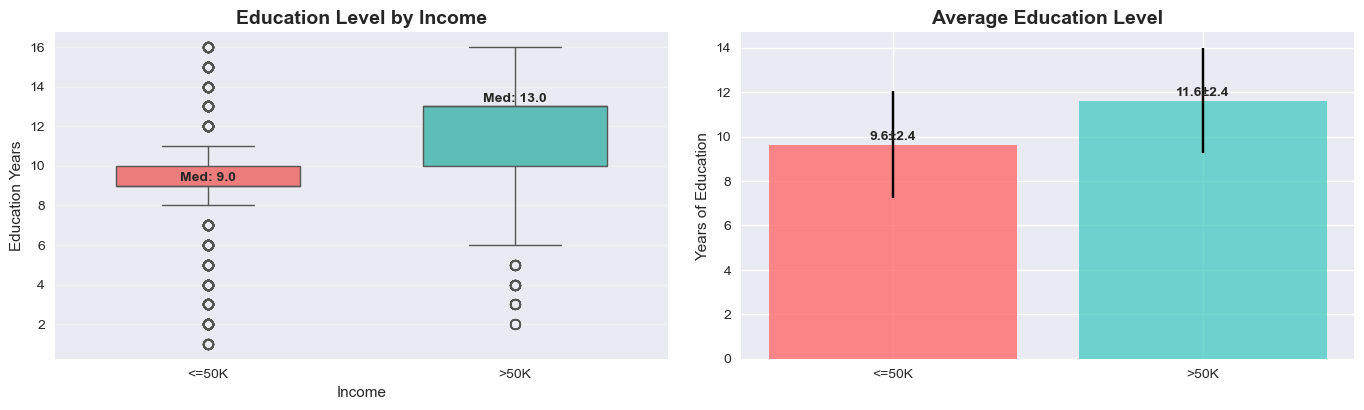

In [25]:
plt.figure(figsize=(14, 8)) 

#comparison plot
plt.subplot(2, 2, 1)
sns.boxplot(data=income_data_clean, x='income', y='education.num', hue='income',
            palette=['#ff6b6b', '#4ecdc4'], legend=False, width=0.6)
plt.title('Education Level by Income', fontsize=14, fontweight='bold')
plt.xlabel('Income', fontsize=11)
plt.ylabel('Education Years', fontsize=11)
plt.grid(axis='y', alpha=0.3)


medians = income_data_clean.groupby('income')['education.num'].median()
for i, median in enumerate(medians):
    plt.text(i, median + 0.1, f'Med: {median:.1f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)


plt.subplot(2, 2, 2)
education_stats = income_data_clean.groupby('income')['education.num'].agg(['count', 'mean', 'std'])
bars = plt.bar(education_stats.index, education_stats['mean'], 
               yerr=education_stats['std'], capsize=5, 
               color=['#ff6b6b', '#4ecdc4'], alpha=0.8)
plt.title('Average Education Level', fontsize=14, fontweight='bold')
plt.ylabel('Years of Education')
plt.xticks(rotation=0)


for bar, (idx, row) in zip(bars, education_stats.iterrows()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{row["mean"]:.1f}±{row["std"]:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

<Figure size 1400x800 with 0 Axes>

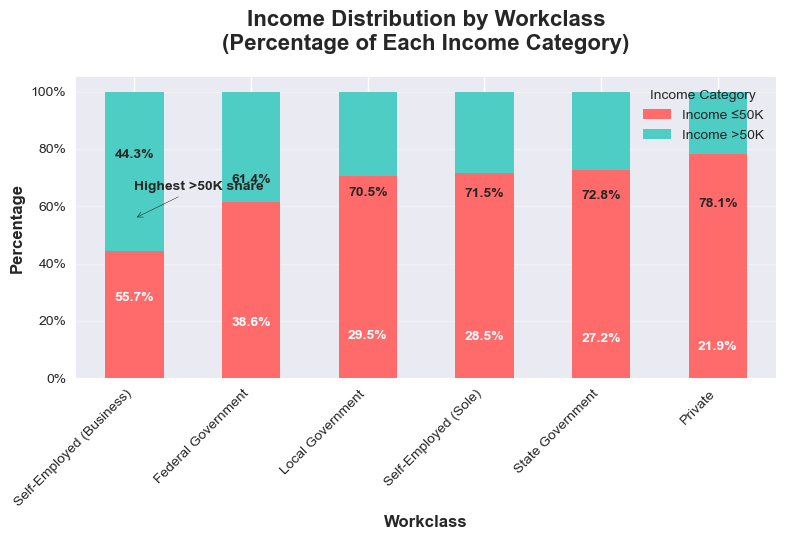

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

plt.figure(figsize=(14, 8))

filtered_data = income_data_clean[income_data_clean['workclass'] != 'Without-pay']

# crosstab of workclass vs income
workclass_income = pd.crosstab(filtered_data['workclass'], filtered_data['income'], normalize='index')
workclass_income_sorted = workclass_income.sort_values('>50K', ascending=False)

colors = ['#FF6B6B', '#4ECDC4']
bars = workclass_income_sorted.plot(kind='bar', stacked=True, color=colors)

plt.title('Income Distribution by Workclass\n(Percentage of Each Income Category)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Workclass', fontsize=12, fontweight='bold')
plt.ylabel('Percentage', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(['Income ≤50K', 'Income >50K'], title='Income Category', title_fontsize=10)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

for i, (idx, row) in enumerate(workclass_income_sorted.iterrows()):
    plt.text(i, row['>50K']/2, f'{row[">50K"]:.1%}',
             ha='center', va='center', fontweight='bold', color='white')
    plt.text(i, row['>50K'] + row['<=50K']/2, f'{row["<=50K"]:.1%}',
             ha='center', va='center', fontweight='bold')

# highest income category
top_class = workclass_income_sorted['>50K'].idxmax()
top_value = workclass_income_sorted.loc[top_class, '>50K']
top_index = workclass_income_sorted.index.get_loc(top_class)
plt.annotate('Highest >50K share',
             xy=(top_index, top_value),
             xytext=(top_index, top_value + 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

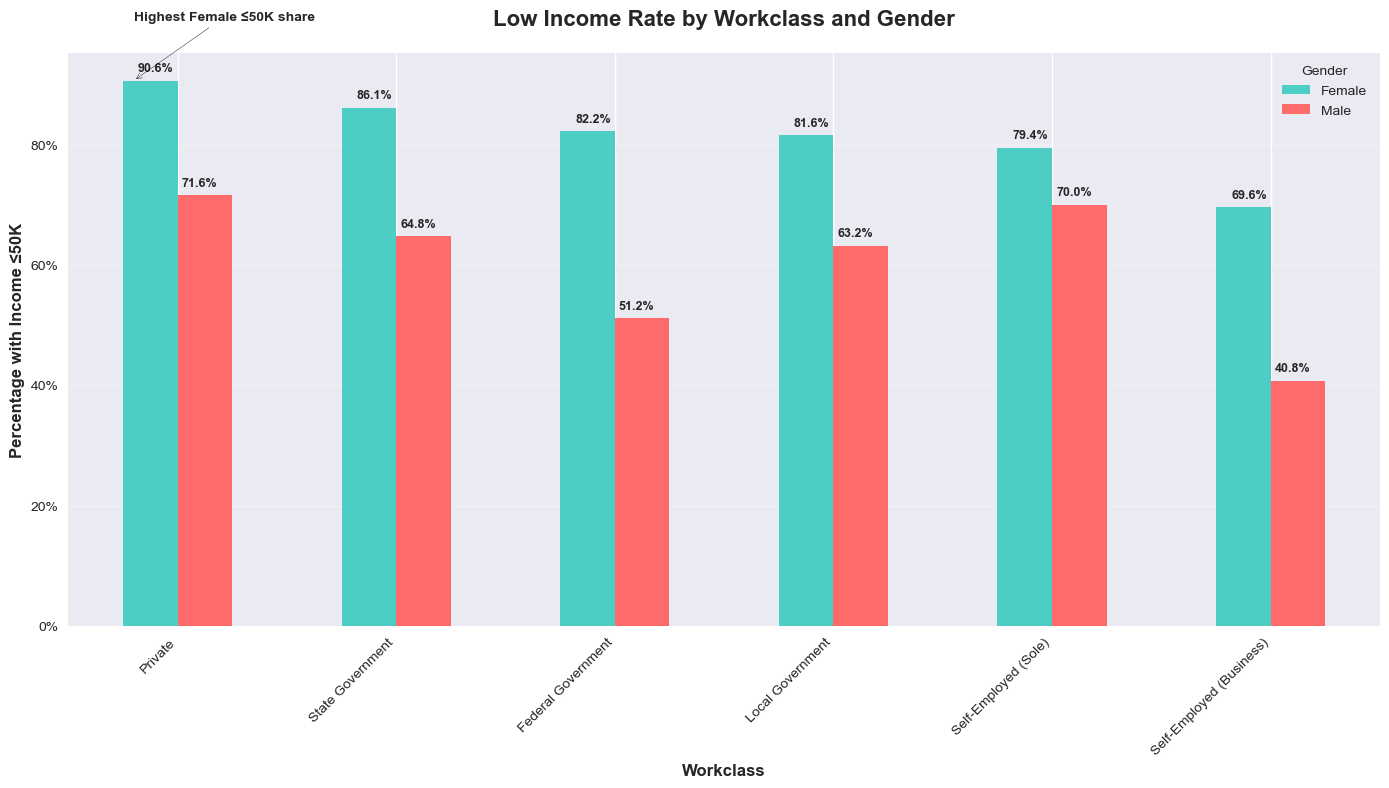

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd


filtered_data = income_data_clean[income_data_clean['workclass'] != 'Without-pay']

# workclass and gender vs income
workclass_gender_income = pd.crosstab(
    [filtered_data['workclass'], filtered_data['sex']],
    filtered_data['income'],
    normalize='index'
).reset_index()

# bar chart: rows = workclass, columns = gender, values = ≤50K
pivot_data = workclass_gender_income.pivot(index='workclass', columns='sex', values='<=50K')

# Sort by female low-income rate (optional)
pivot_data = pivot_data.sort_values(by='Female', ascending=False)

ax = pivot_data.plot(kind='bar', figsize=(14, 8), color=['#4ECDC4', '#FF6B6B'])

plt.title('Low Income Rate by Workclass and Gender',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Workclass', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income ≤50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

for i, workclass in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[workclass, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotate highest low-income category (female)
top_class = pivot_data['Female'].idxmax()
top_value = pivot_data.loc[top_class, 'Female']
top_index = pivot_data.index.get_loc(top_class)

plt.annotate('Highest Female ≤50K share',
             xy=(top_index - 0.2, top_value),
             xytext=(top_index - 0.2, top_value + 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

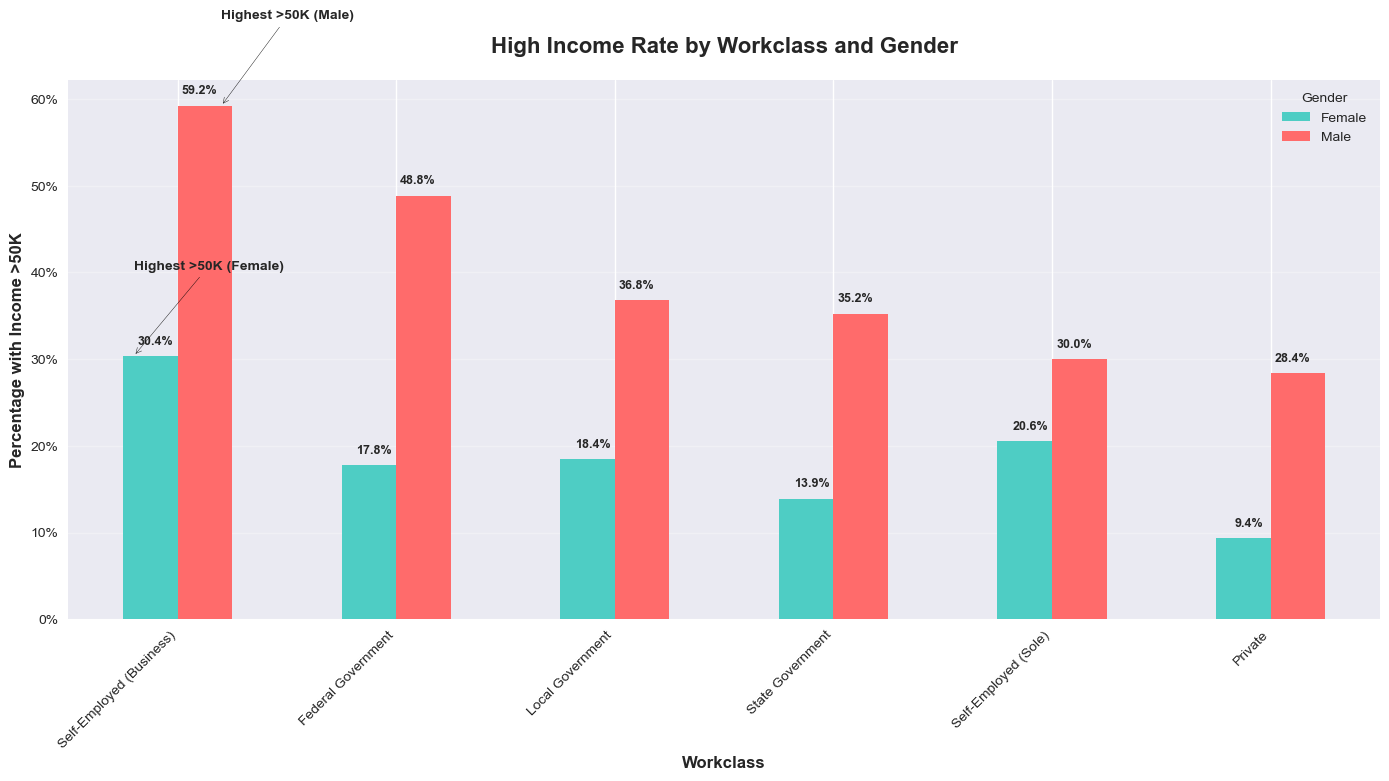

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd


income_data_filtered = income_data_clean[income_data_clean['workclass'] != 'Without-pay']

# normalized crosstab of workclass and gender vs income
workclass_gender_income = pd.crosstab(
    [income_data_filtered['workclass'], income_data_filtered['sex']],
    income_data_filtered['income'],
    normalize='index'
).reset_index()


pivot_data = workclass_gender_income.pivot(index='workclass', columns='sex', values='>50K')

pivot_data = pivot_data.sort_values(by='Male', ascending=False)

ax = pivot_data.plot(kind='bar', figsize=(14, 8), color=['#4ECDC4', '#FF6B6B'])

plt.title('High Income Rate by Workclass and Gender',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Workclass', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income >50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

for i, workclass in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[workclass, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')


top_class_male = pivot_data['Male'].idxmax()
top_value_male = pivot_data['Male'].max()
top_index_male = pivot_data.index.get_loc(top_class_male)

plt.annotate('Highest >50K (Male)',
             xy=(top_index_male + 0.2, top_value_male),
             xytext=(top_index_male + 0.2, top_value_male + 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold')

top_class_female = pivot_data['Female'].idxmax()
top_value_female = pivot_data['Female'].max()
top_index_female = pivot_data.index.get_loc(top_class_female)

plt.annotate('Highest >50K (Female)',
             xy=(top_index_female - 0.2, top_value_female),
             xytext=(top_index_female - 0.2, top_value_female + 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

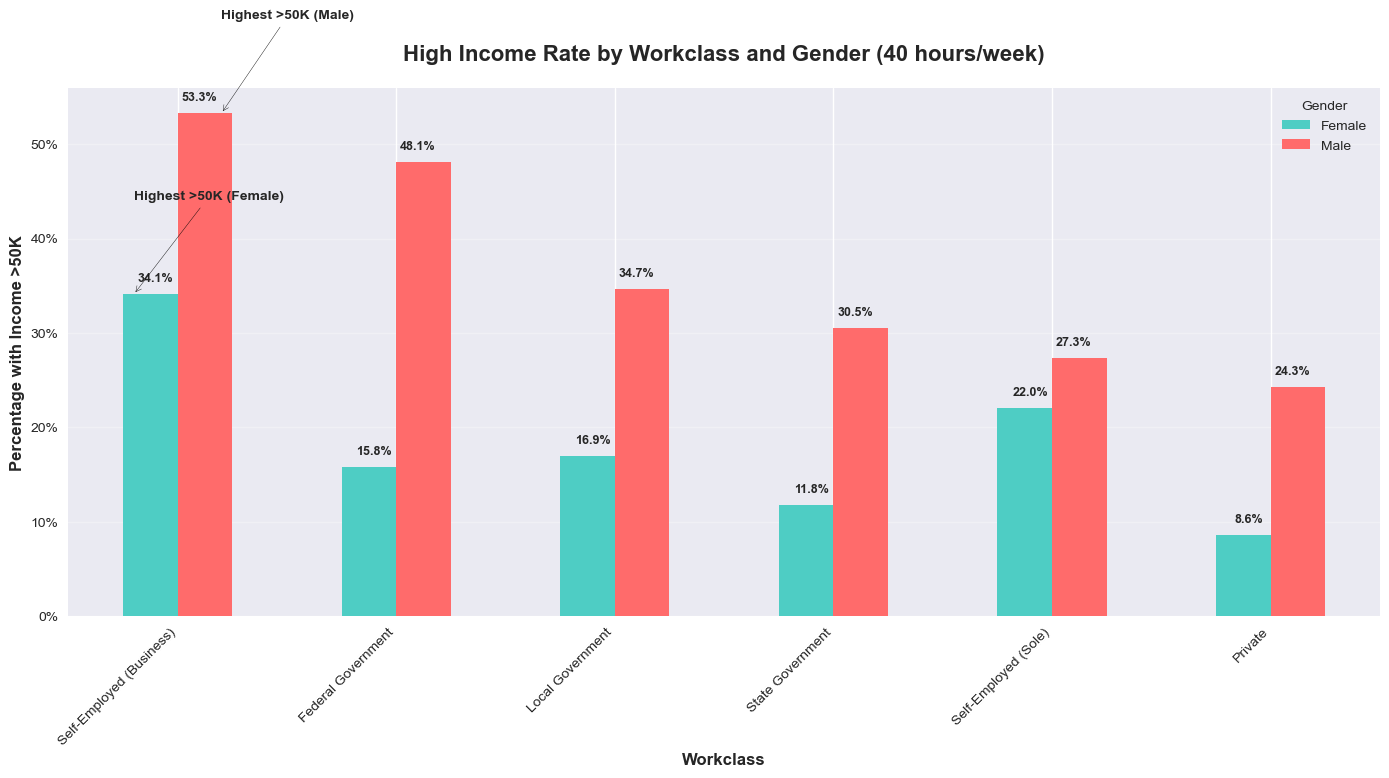

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

income_data_filtered = income_data_clean[
    (income_data_clean['workclass'] != 'Without-pay') &
    (income_data_clean['hours.per.week'] == 40)
]

# normalized crosstab of workclass and gender vs income
workclass_gender_income = pd.crosstab(
    [income_data_filtered['workclass'], income_data_filtered['sex']],
    income_data_filtered['income'],
    normalize='index'
).reset_index()


pivot_data = workclass_gender_income.pivot(index='workclass', columns='sex', values='>50K')
pivot_data = pivot_data.sort_values(by='Male', ascending=False)


ax = pivot_data.plot(kind='bar', figsize=(14, 8), color=['#4ECDC4', '#FF6B6B'])

plt.title('High Income Rate by Workclass and Gender (40 hours/week)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Workclass', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income >50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))


for i, workclass in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[workclass, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')


top_class_male = pivot_data['Male'].idxmax()
top_value_male = pivot_data['Male'].max()
top_index_male = pivot_data.index.get_loc(top_class_male)
plt.annotate('Highest >50K (Male)',
             xy=(top_index_male + 0.2, top_value_male),
             xytext=(top_index_male + 0.2, top_value_male + 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold')


top_class_female = pivot_data['Female'].idxmax()
top_value_female = pivot_data['Female'].max()
top_index_female = pivot_data.index.get_loc(top_class_female)
plt.annotate('Highest >50K (Female)',
             xy=(top_index_female - 0.2, top_value_female),
             xytext=(top_index_female - 0.2, top_value_female + 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

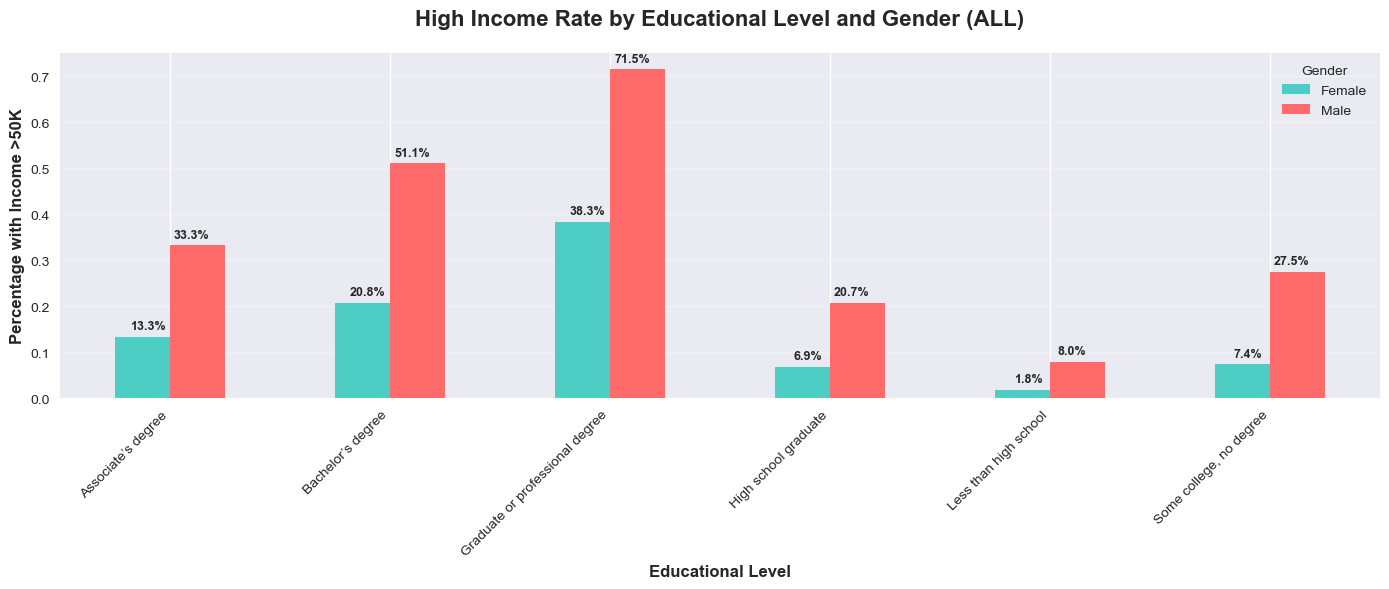

In [30]:
import matplotlib.pyplot as plt
import pandas as pd


education_gender_income = pd.crosstab(
    [income_data_clean['education_level_acs'], income_data_clean['sex']],
    income_data_clean['income'],
    normalize='index'
).reset_index()

# Pivot table
pivot_data = education_gender_income.pivot(
    index='education_level_acs',
    columns='sex',
    values='>50K'
)

pivot_data.plot(kind='bar', figsize=(14, 6), color=['#4ECDC4', '#FF6B6B'])

plt.title('High Income Rate by Educational Level and Gender (ALL)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Educational Level', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income >50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)

for i, edu_level in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[edu_level, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

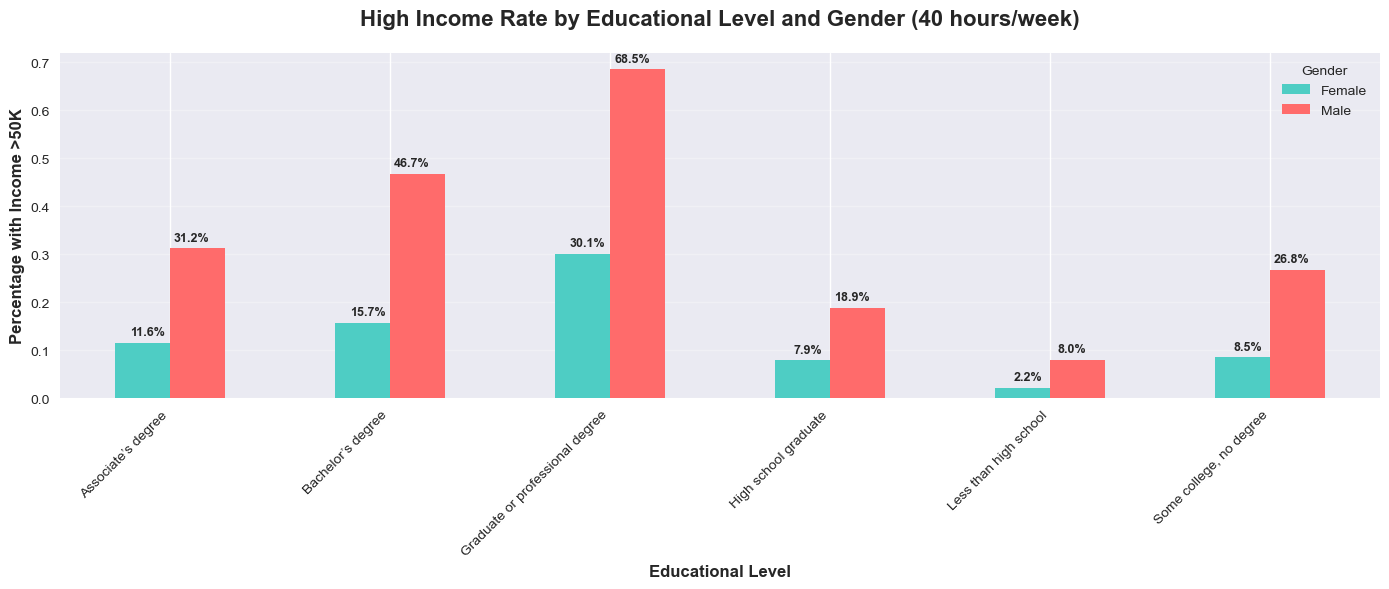

In [31]:
import matplotlib.pyplot as plt
import pandas as pd


income_data_filtered = income_data_clean[income_data_clean['hours.per.week'] == 40]

# normalized crosstab of education and gender vs income
education_gender_income = pd.crosstab(
    [income_data_filtered['education_level_acs'], income_data_filtered['sex']],
    income_data_filtered['income'],
    normalize='index'
).reset_index()


pivot_data = education_gender_income.pivot(index='education_level_acs', columns='sex', values='>50K')


pivot_data.plot(kind='bar', figsize=(14, 6), color=['#4ECDC4', '#FF6B6B'])

plt.title('High Income Rate by Educational Level and Gender (40 hours/week)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Educational Level', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income >50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)


for i, edu_level in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[edu_level, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

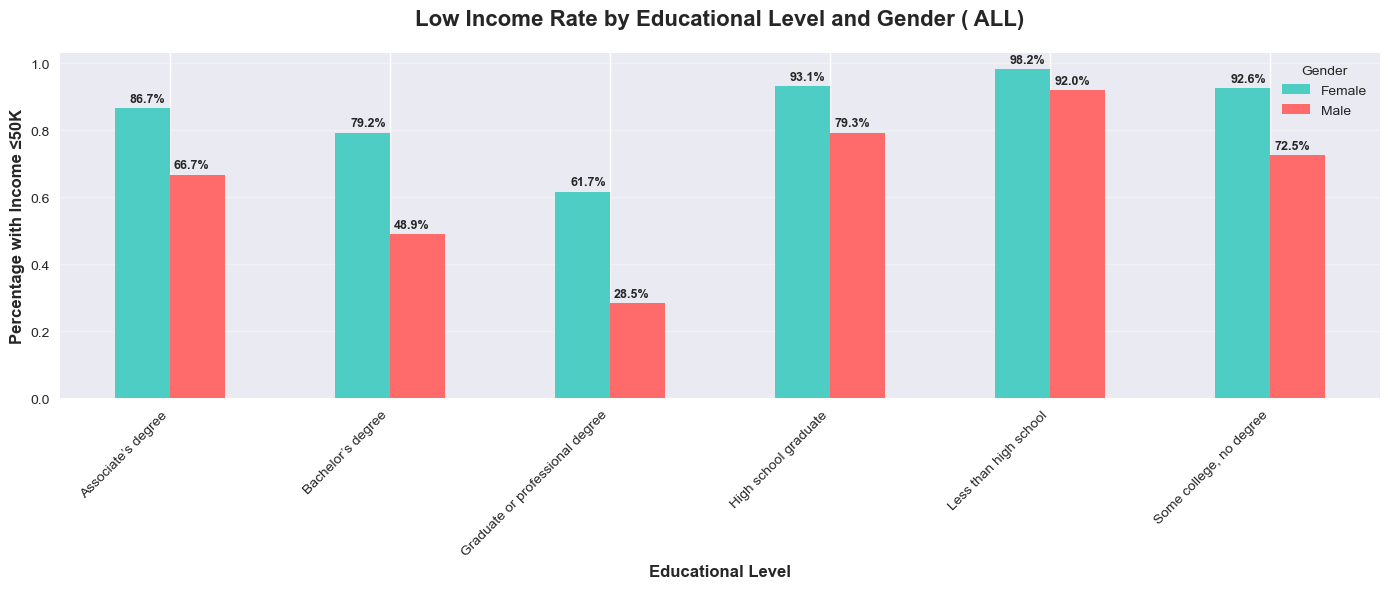

In [32]:
import matplotlib.pyplot as plt

#income ≤50K by education and gender
education_gender_income = pd.crosstab(
    [income_data_clean['education_level_acs'], income_data_clean['sex']],
    income_data_clean['income'],
    normalize='index'
).reset_index()


pivot_data = education_gender_income.pivot(index='education_level_acs', columns='sex', values='<=50K')


pivot_data.plot(kind='bar', figsize=(14, 6), color=['#4ECDC4', '#FF6B6B'])


plt.title('Low Income Rate by Educational Level and Gender ( ALL)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Educational Level', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income ≤50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)


for i, edu_level in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[edu_level, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

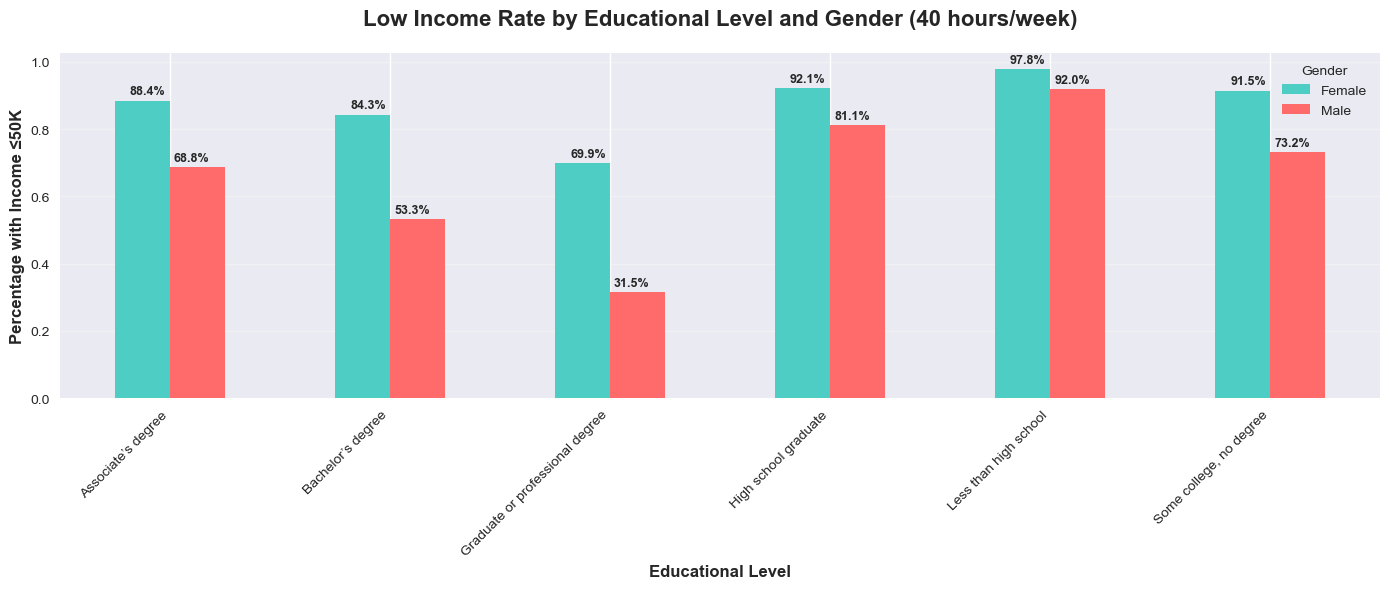

In [33]:
import matplotlib.pyplot as plt
import pandas as pd


income_data_filtered = income_data_clean[income_data_clean['hours.per.week'] == 40]


education_gender_income = pd.crosstab(
    [income_data_filtered['education_level_acs'], income_data_filtered['sex']],
    income_data_filtered['income'],
    normalize='index'
).reset_index()


pivot_data = education_gender_income.pivot(index='education_level_acs', columns='sex', values='<=50K')


pivot_data.plot(kind='bar', figsize=(14, 6), color=['#4ECDC4', '#FF6B6B'])

plt.title('Low Income Rate by Educational Level and Gender (40 hours/week)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Educational Level', fontsize=12, fontweight='bold')
plt.ylabel('Percentage with Income ≤50K', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)


for i, edu_level in enumerate(pivot_data.index):
    for j, gender in enumerate(pivot_data.columns):
        value = pivot_data.loc[edu_level, gender]
        if pd.notnull(value):
            plt.text(i + (j - 0.5)*0.2, value + 0.01, f'{value:.1%}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# Validate the education difference statistically
from scipy.stats import mannwhitneyu

low_income_edu = income_data_clean[income_data_clean['income'] == '<=50K']['education.num']
high_income_edu = income_data_clean[income_data_clean['income'] == '>50K']['education.num']

stat, p_value = mannwhitneyu(low_income_edu, high_income_edu)
print(f"Mann-Whitney U test p-value: {p_value:.6f}")
print("The difference in education levels between income groups is statistically significant" if p_value < 0.05 else "No significant difference")

Mann-Whitney U test p-value: 0.000000
The difference in education levels between income groups is statistically significant


In [36]:
print("Remaining missing values:")
print(income_data_clean.isna().sum())

# Handle native_country missing values
income_data_clean['native_country'] = income_data_clean['native_country'].fillna('Unknown')

Remaining missing values:
YEAR                       0
age                        0
workclass                  0
final_weight               0
education                  0
education_years            0
marital_status             0
occupation                 0
relationship               0
race                       0
gender                     0
capital_gain               0
capital_loss               0
hours_per_week             0
native_country           555
income                     0
marital_group              0
occupation_sector_acs      0
workclass_simple           0
workclass_detailed         0
age_group_acs              0
age_group_label            0
education_level_acs        0
dtype: int64


Income distribution by gender:
income     <=50K      >50K
gender                    
Female  0.886403  0.113597
Male    0.686083  0.313917


<Figure size 800x600 with 0 Axes>

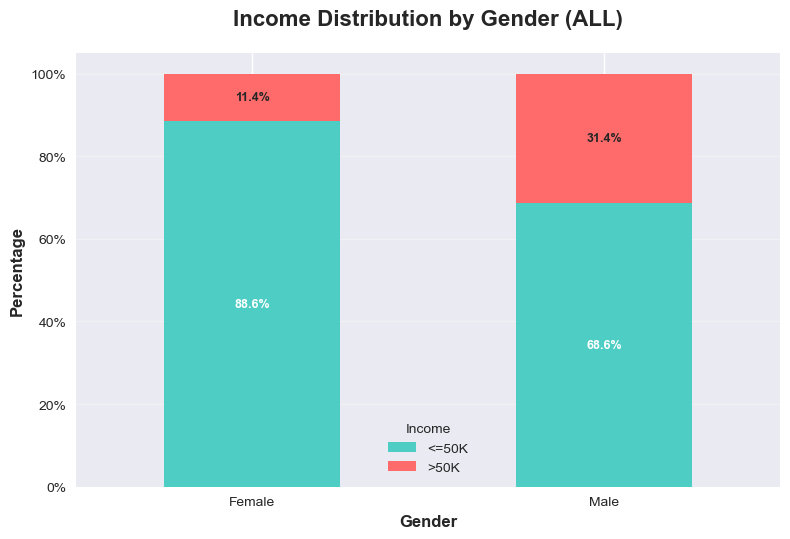

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Create normalized crosstab
gender_income = pd.crosstab(income_data_clean['gender'], income_data_clean['income'], normalize='index')
print("Income distribution by gender:")
print(gender_income)

# Plot setup
plt.figure(figsize=(8, 6))
ax = gender_income.plot(kind='bar', stacked=True, color=['#4ECDC4', '#FF6B6B'])

plt.title('Income Distribution by Gender (ALL)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('Percentage', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Income')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

for i, (idx, row) in enumerate(gender_income.iterrows()):

    if row['<=50K'] > 0:
        plt.text(i, row['<=50K']/2, f'{row["<=50K"]:.1%}',
                 ha='center', va='center', fontweight='bold', color='white', fontsize=9)
    # Label for >50K
    if row['>50K'] > 0:
        plt.text(i, row['<=50K'] + row['>50K']/2, f'{row[">50K"]:.1%}',
                 ha='center', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

Income distribution by gender (40 hours/week):
income     <=50K      >50K
gender                    
Female  0.896126  0.103874
Male    0.727429  0.272571


<Figure size 800x600 with 0 Axes>

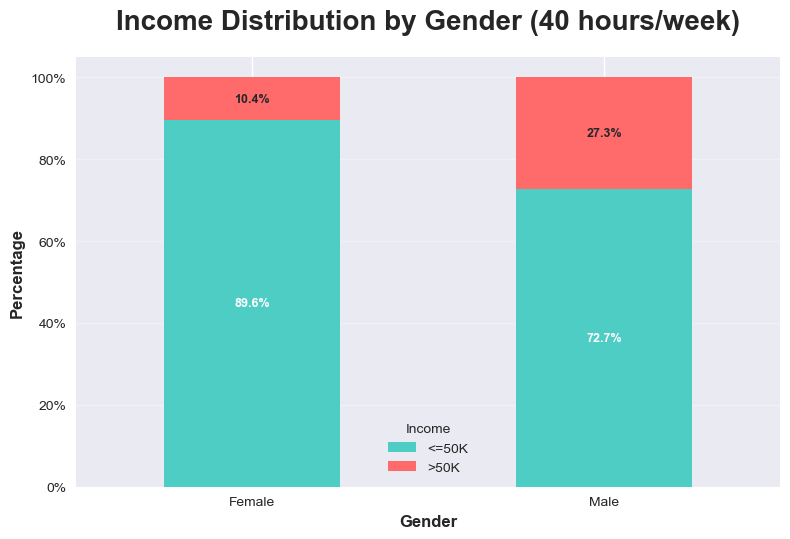

In [38]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd


income_data_filtered = income_data_clean[income_data_clean['hours_per_week'] == 40]

gender_income = pd.crosstab(
    income_data_filtered['gender'],
    income_data_filtered['income'],
    normalize='index'
)

print("Income distribution by gender (40 hours/week):")
print(gender_income)


plt.figure(figsize=(8, 6))
ax = gender_income.plot(kind='bar', stacked=True, color=['#4ECDC4', '#FF6B6B'])

plt.title('Income Distribution by Gender (40 hours/week)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('Percentage', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Income')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))


for i, (idx, row) in enumerate(gender_income.iterrows()):
    # Label for <=50K
    if row['<=50K'] > 0:
        plt.text(i, row['<=50K']/2, f'{row["<=50K"]:.1%}',
                 ha='center', va='center', fontweight='bold', color='white', fontsize=9)
    # Label for >50K
    if row['>50K'] > 0:
        plt.text(i, row['<=50K'] + row['>50K']/2, f'{row[">50K"]:.1%}',
                 ha='center', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
#outliers in working hours
hours_outliers = income_data_clean[income_data_clean['hours_per_week'] > 60]
print(f"Number of individuals working more than 60 hours per week: {len(hours_outliers)}")
print(f"Percentage of total dataset: {len(hours_outliers)/len(income_data_clean)*100:.1f}%")

# Income distribution among this group
print("Income distribution- working more than 60 hours per week:")
print(hours_outliers['income'].value_counts(normalize=True))

Number of individuals working more than 60 hours per week: 1076
Percentage of total dataset: 3.5%
Income distribution- working more than 60 hours per week:
income
<=50K    0.629182
>50K     0.370818
Name: proportion, dtype: float64


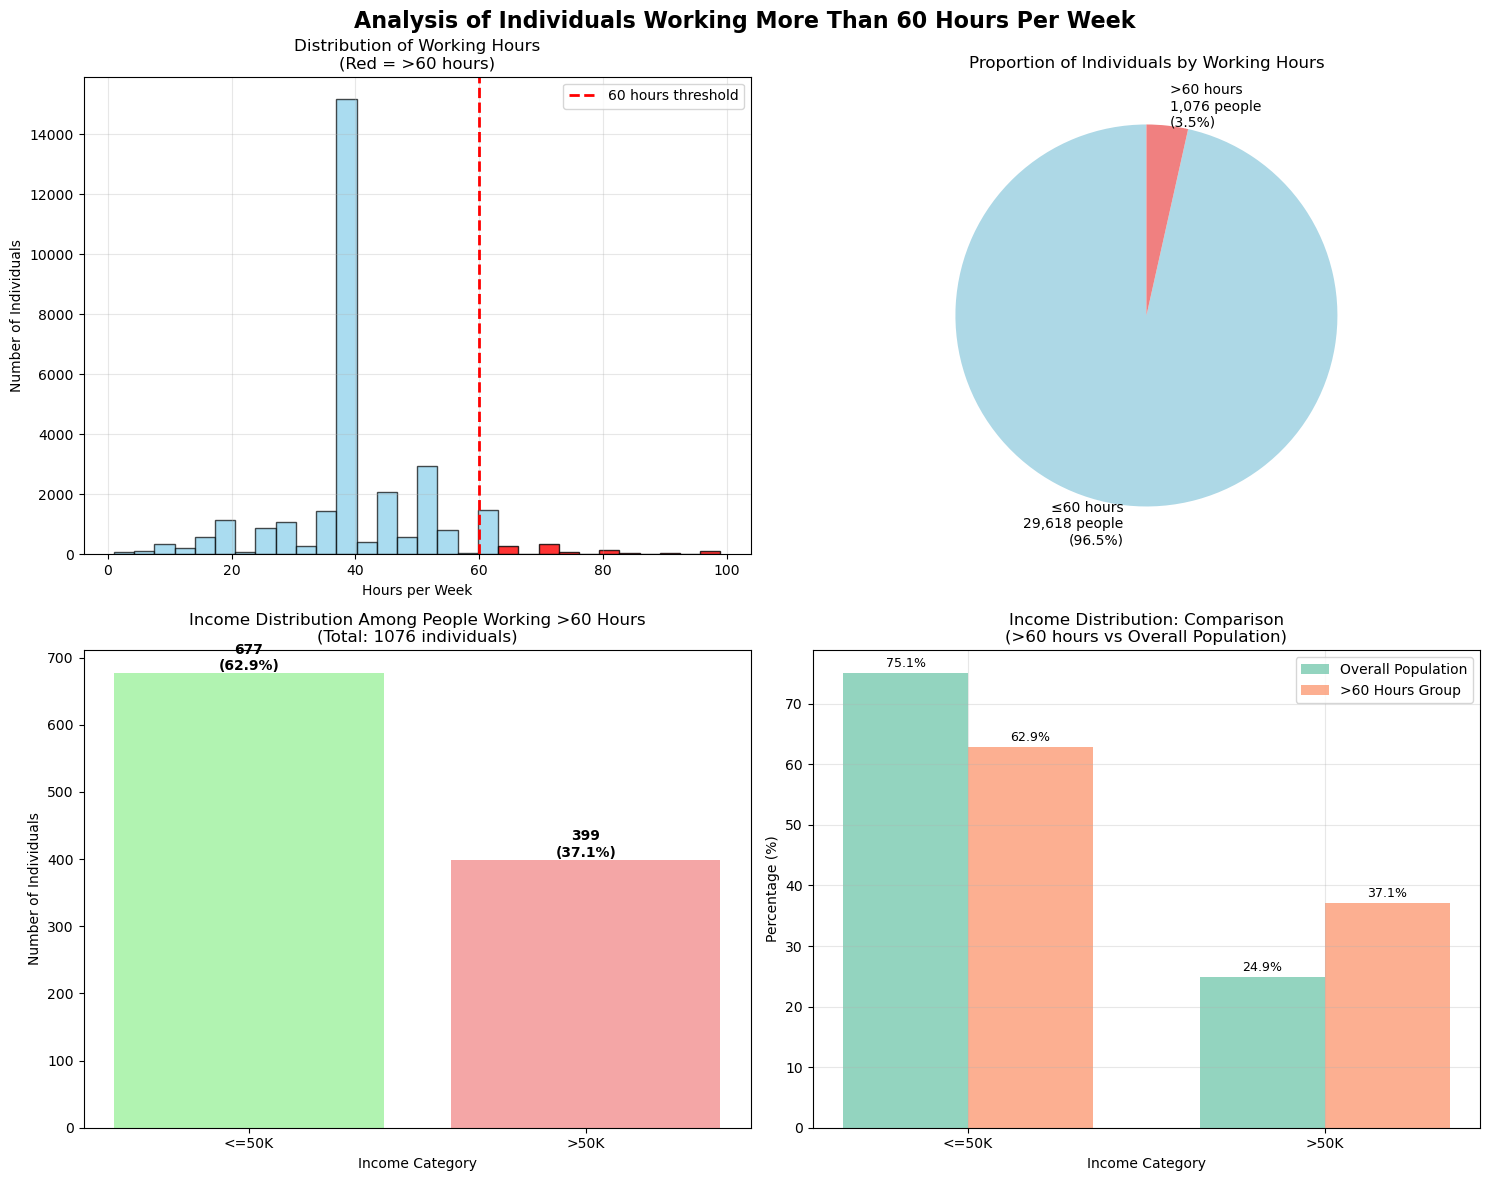

Total individuals in dataset: 30,694
Individuals working >60 hours: 1,076
Percentage working >60 hours: 3.51%
Income distribution among >60 hours group:
  <=50K: 677 people (62.9%)
  >50K: 399 people (37.1%)
Average hours per week (overall): 41.0
Average hours per week (>60 group): 74.3
Maximum hours per week: 99


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


plt.style.use('default')
sns.set_palette("Set2")


fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analysis of Individuals Working More Than 60 Hours Per Week', fontsize=16, fontweight='bold')

#Distribution of working hours (highlighting outliers)
ax1 = axes[0, 0]
plt.sca(ax1)
hours_data = income_data_clean['hours_per_week']

#histogram with highlighted outliers
n, bins, patches = ax1.hist(hours_data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# Highlight the outlier region (hours > 60)
outlier_color = 'red'
for patch, bin_edge in zip(patches, bins):
    if bin_edge > 60:
        patch.set_facecolor(outlier_color)
        patch.set_alpha(0.8)

ax1.axvline(x=60, color='red', linestyle='--', linewidth=2, label='60 hours threshold')
ax1.set_xlabel('Hours per Week')
ax1.set_ylabel('Number of Individuals')
ax1.set_title('Distribution of Working Hours\n(Red = >60 hours)')
ax1.legend()
ax1.grid(True, alpha=0.3)

#Pie chart showing proportion
ax2 = axes[0, 1]
plt.sca(ax2)
normal_hours = len(income_data_clean[income_data_clean['hours_per_week'] <= 60])
outlier_hours = len(hours_outliers)

sizes = [normal_hours, outlier_hours]
labels = [
    f'≤60 hours\n{normal_hours:,} people\n({normal_hours/len(income_data_clean)*100:.1f}%)',
    f'>60 hours\n{outlier_hours:,} people\n({outlier_hours/len(income_data_clean)*100:.1f}%)'
]
colors = ['lightblue', 'lightcoral']

ax2.pie(sizes, labels=labels, colors=colors, autopct='', startangle=90, textprops={'fontsize': 10})
ax2.set_title('Proportion of Individuals by Working Hours')

#Income distribution among outliers
ax3 = axes[1, 0]
plt.sca(ax3)
income_dist = hours_outliers['income'].value_counts()

# Calculate percentages for labels
total_outliers = len(hours_outliers)
percentages = [(count/total_outliers)*100 for count in income_dist.values]

bars = ax3.bar(income_dist.index, income_dist.values, color=['lightgreen', 'lightcoral'], alpha=0.7)
ax3.set_xlabel('Income Category')
ax3.set_ylabel('Number of Individuals')
ax3.set_title(f'Income Distribution Among People Working >60 Hours\n(Total: {total_outliers} individuals)')


for bar, percentage in zip(bars, percentages):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}\n({percentage:.1f}%)', ha='center', va='bottom', fontweight='bold')

#Comparison with overall income distribution
ax4 = axes[1, 1]
plt.sca(ax4)

# Overall income distribution
overall_income = income_data_clean['income'].value_counts(normalize=True) * 100
outlier_income = hours_outliers['income'].value_counts(normalize=True) * 100


x = np.arange(len(overall_income))
width = 0.35

bars1 = ax4.bar(x - width/2, overall_income.values, width, label='Overall Population', alpha=0.7)
bars2 = ax4.bar(x + width/2, outlier_income.values, width, label='>60 Hours Group', alpha=0.7)

ax4.set_xlabel('Income Category')
ax4.set_ylabel('Percentage (%)')
ax4.set_title('Income Distribution: Comparison\n(>60 hours vs Overall Population)')
ax4.set_xticks(x)
ax4.set_xticklabels(overall_income.index)
ax4.legend()
ax4.grid(True, alpha=0.3)


for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total individuals in dataset: {len(income_data_clean):,}")
print(f"Individuals working >60 hours: {len(hours_outliers):,}")
print(f"Percentage working >60 hours: {len(hours_outliers)/len(income_data_clean)*100:.2f}%")

print(f"Income distribution among >60 hours group:")
income_summary = hours_outliers['income'].value_counts(normalize=True).sort_index()
for income_cat, percentage in income_summary.items():
    count = hours_outliers[hours_outliers['income'] == income_cat].shape[0]
    print(f"  {income_cat}: {count} people ({percentage*100:.1f}%)")


print(f"Average hours per week (overall): {income_data_clean['hours_per_week'].mean():.1f}")
print(f"Average hours per week (>60 group): {hours_outliers['hours_per_week'].mean():.1f}")
print(f"Maximum hours per week: {income_data_clean['hours_per_week'].max()}")

In [43]:
#working hours
hours = income_data_clean[income_data_clean['hours_per_week'] ==40]
print(f"Number of individuals working 40 hours per week: {len(hours)}")
print(f"Percentage of total dataset: {len(hours)/len(income_data_clean)*100:.1f}%")

# Income distribution among this group
print("Income distribution- working 40 hours per week:")
print(hours ['income'].value_counts(normalize=True))

Number of individuals working 40 hours per week: 14512
Percentage of total dataset: 47.3%
Income distribution- working 40 hours per week:
income
<=50K    0.781147
>50K     0.218853
Name: proportion, dtype: float64


In [44]:
# senior workers
senior_workers = income_data_clean[income_data_clean['age'] > 65]
print(f"Number of individuals over the age of 65 who are still working: {len(senior_workers)}")
print("Their occupations:")
print(senior_workers['occupation'].value_counts())

Number of individuals over the age of 65 who are still working: 851
Their occupations:
occupation
Exec-managerial      142
Sales                127
Prof-specialty       122
Other-service        102
Adm-clerical          97
Farming-fishing       64
Craft-repair          50
Transport-moving      41
Machine-op-inspct     29
Protective-serv       24
Handlers-cleaners     22
Priv-house-serv       22
Tech-support           9
Name: count, dtype: int64


In [45]:
# individuals with high capital gains
high_gain = income_data_clean[income_data_clean['capital_gain'] > 50000]
print(f"Number of individuals with high capital gains: {len(high_gain)}")
print("Their sources of income (occupations):")
print(high_gain['occupation'].value_counts())

Number of individuals with high capital gains: 155
Their sources of income (occupations):
occupation
Prof-specialty       67
Exec-managerial      42
Sales                25
Craft-repair          8
Adm-clerical          6
Other-service         2
Machine-op-inspct     1
Transport-moving      1
Protective-serv       1
Handlers-cleaners     1
Tech-support          1
Name: count, dtype: int64


C:\Users\shari\AppData\Local\Temp\ipykernel_6240\2418373786.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


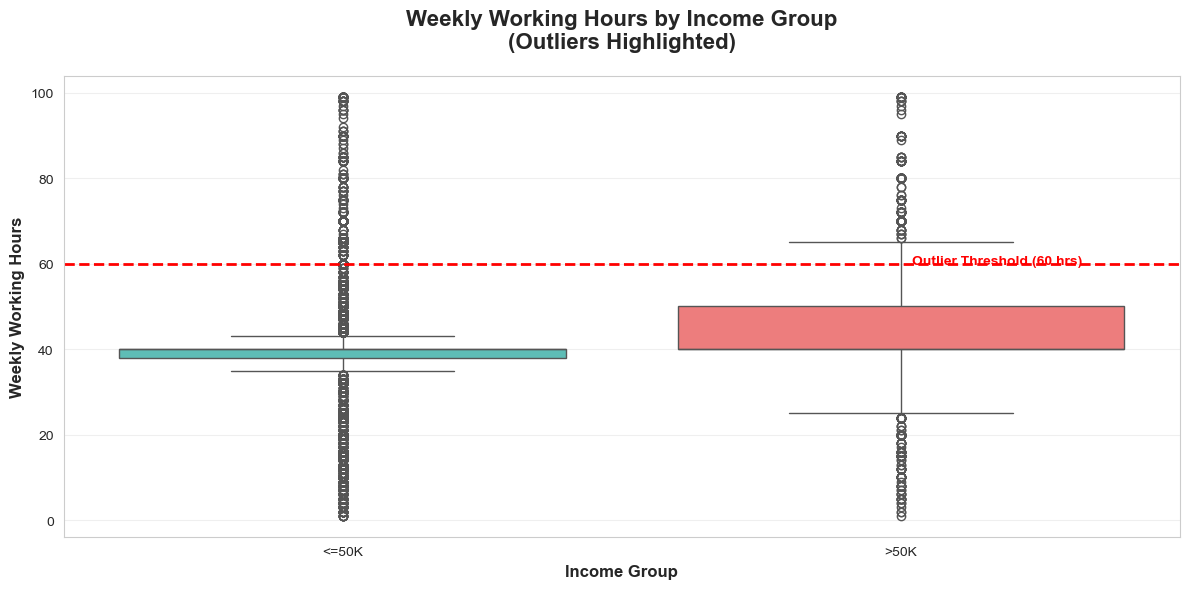

In [46]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.boxplot(
    data=income_data_clean,
    x='income',
    y='hours_per_week',
    showfliers=True,
    palette={'<=50K': '#4ECDC4', '>50K': '#FF6B6B'}
)

plt.title('Weekly Working Hours by Income Group\n(Outliers Highlighted)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Income Group', fontsize=12, fontweight='bold')
plt.ylabel('Weekly Working Hours', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Annotate outlier threshold
plt.axhline(y=60, color='red', linestyle='--', linewidth=2)
plt.text(1.02, 60, 'Outlier Threshold (60 hrs)', color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
def update_1994_to_unified_method_corrected(df_1994):
    def convert_income_to_numeric(income_str):
        if income_str == '>50K':
            return 75000
        else:
            return 25000

    df_1994['income_numeric'] = df_1994['income'].apply(convert_income_to_numeric)

#Official inflation factors from U.S. Bureau of Labor Statistics
    inflation_factors = {
        1994: 1.00,   # Base year
        2000: 1.17,   # Source: BLS CPI-U 1994-2000
        2010: 1.42,   # Source: BLS CPI-U 1994-2010  
        2019: 1.67,   # Source: BLS CPI-U 1994-2019
        2021: 1.82,   # Source: BLS CPI-U 1994-2021
        2023: 2.05    # End of 2023 estimate based on BLS data
    }
    
    # Inflation multiplier for 2023 (to convert 1994 → 2023 values)
    inflation_1994_to_2023 = inflation_factors[2023]
    
    df_1994['income_1994_value'] = df_1994['income_numeric']
    df_1994['income_2023_value'] = df_1994['income_numeric'] * inflation_1994_to_2023

    df_1994['income_category'] = df_1994['income_1994_value'] > 50000
    df_1994['income_category_label'] = df_1994['income_category'].map(
        {True: 'High income (>$50K 1994 value)', False: 'Low income (≤$50K 1994 value)'}
    )

    print("1994 dataset successfully updated WITH BLS INFLATION DATA")
    print("Source: U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)")

    print(f"Number of records: {len(df_1994):,}")
    print(f"Average numeric income: ${df_1994['income_numeric'].mean():,.0f}")
    print(f"Average income in 1994 value: ${df_1994['income_1994_value'].mean():,.0f}")
    print(f"Average income in 2023 value: ${df_1994['income_2023_value'].mean():,.0f}")
    print(f"Inflation factor (1994→2023): {inflation_1994_to_2023:.2f}x")
    print(f"High income proportion: {df_1994['income_category'].mean():.1%}")

    # Consistency check
    original_high_income = (df_1994['income'] == '>50K').mean()
    new_high_income = df_1994['income_category'].mean()
    print(f"   Consistency check: original >50K: {original_high_income:.1%}, new: {new_high_income:.1%}")
    
#inflation factors used
    print(f"\n   Inflation factors used (BLS CPI-U):")
    for year, factor in inflation_factors.items():
        cumulative_inflation = (factor - 1) * 100
        print(f"      {year}: {factor:.2f} (+{cumulative_inflation:.0f}% since 1994)")

    return df_1994


df_1994_unified_corrected = update_1994_to_unified_method_corrected(income_data_clean)

1994 dataset successfully updated WITH BLS INFLATION DATA
Source: U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)
Number of records: 30,694
Average numeric income: $37,458
Average income in 1994 value: $37,458
Average income in 2023 value: $76,790
Inflation factor (1994→2023): 2.05x
High income proportion: 24.9%
   Consistency check: original >50K: 24.9%, new: 24.9%

   Inflation factors used (BLS CPI-U):
      1994: 1.00 (+0% since 1994)
      2000: 1.17 (+17% since 1994)
      2010: 1.42 (+42% since 1994)
      2019: 1.67 (+67% since 1994)
      2021: 1.82 (+82% since 1994)
      2023: 2.05 (+105% since 1994)


In [48]:
def verify_1994_update(df_1994_updated):
    
    print("VERIFICATION WITH BLS OFFICIAL INFLATION DATA")
#Comparison between original and adjusted data
    comparison = df_1994_updated[['income', 'income_numeric', 'income_1994_value', 'income_2023_value', 'income_category_label']].head(6)
    print("Comparison between original and adjusted data:")
    print(comparison)
    
#Income statistics
    print(f"\nIncome Statistics (BLS Inflation Adjusted):")
    print(f"   Original income distribution: {df_1994_updated['income'].value_counts().to_dict()}")
    print(f"   Average numeric income: ${df_1994_updated['income_numeric'].mean():,.0f}")
    print(f"   Average income (1994 value): ${df_1994_updated['income_1994_value'].mean():,.0f}")
    print(f"   Average income (2023 value): ${df_1994_updated['income_2023_value'].mean():,.0f}")
    print(f"   High income proportion: {df_1994_updated['income_category'].mean():.1%}")
    
#Inflation information
    inflation_1994_to_2023 = 2.05  # From BLS data
    print(f"\nInflation Information (BLS CPI-U):")
    print(f"   Cumulative inflation 1994-2023: +{(inflation_1994_to_2023 - 1) * 100:.0f}%")
    print(f"   Annual average inflation rate: {((inflation_1994_to_2023 ** (1/29)) - 1) * 100:.1f}%")
    print(f"   Purchasing power loss: {(1 - 1/inflation_1994_to_2023) * 100:.1f}%")

# Final verification
verify_1994_update(df_1994_unified_corrected)

VERIFICATION WITH BLS OFFICIAL INFLATION DATA
Comparison between original and adjusted data:
  income  income_numeric  income_1994_value  income_2023_value  \
1  <=50K           25000              25000            51250.0   
3  <=50K           25000              25000            51250.0   
4  <=50K           25000              25000            51250.0   
5  <=50K           25000              25000            51250.0   
6  <=50K           25000              25000            51250.0   
7   >50K           75000              75000           153750.0   

            income_category_label  
1   Low income (≤$50K 1994 value)  
3   Low income (≤$50K 1994 value)  
4   Low income (≤$50K 1994 value)  
5   Low income (≤$50K 1994 value)  
6   Low income (≤$50K 1994 value)  
7  High income (>$50K 1994 value)  

Income Statistics (BLS Inflation Adjusted):
   Original income distribution: {'<=50K': 23046, '>50K': 7648}
   Average numeric income: $37,458
   Average income (1994 value): $37,458
   Avera

In [49]:
# RESULTS ANALYSIS
def analyze_adjusted_income_updated(data):
    print("ADJUSTED INCOME ANALYSIS")
    
# Income category distribution
    print("INCOME CATEGORY DISTRIBUTION (1994 Threshold):")
    income_dist = data['income_category_label'].value_counts()
    for category, count in income_dist.items():
        percentage = (count / len(data)) * 100
        print(f"   {category}: {count:,} people ({percentage:.1f}%)")
    
# Estimated income statistics (2023 dollars)
    print("ESTIMATED INCOME STATISTICS (2023 Dollars):")
    print(f"   Average: ${data['income_2023_value'].mean():,.0f}")
    print(f"   Median: ${data['income_2023_value'].median():,.0f}")
    print(f"   Maximum: ${data['income_2023_value'].max():,.0f}")
    print(f"   Minimum: ${data['income_2023_value'].min():,.0f}")
    print(f"   Standard Deviation: ${data['income_2023_value'].std():,.0f}")
    
 # Comparison with original data (1994 vs adjusted)
    original_high_income = (data['income'] == '>50K').mean() * 100
    adjusted_high_income = (data['income_category'] == True).mean() * 100
    
    print("HIGH-INCOME GROUP COMPARISON:")
    print(f"   Original threshold (>$50K): {original_high_income:.1f}%")
    print(f"   Adjusted threshold (>$50K 1994 value): {adjusted_high_income:.1f}%")
    print(f"   Change: {adjusted_high_income - original_high_income:+.1f}%")


analyze_adjusted_income_updated(df_1994_unified_corrected)

ADJUSTED INCOME ANALYSIS
INCOME CATEGORY DISTRIBUTION (1994 Threshold):
   Low income (≤$50K 1994 value): 23,046 people (75.1%)
   High income (>$50K 1994 value): 7,648 people (24.9%)
ESTIMATED INCOME STATISTICS (2023 Dollars):
   Average: $76,790
   Median: $51,250
   Maximum: $153,750
   Minimum: $51,250
   Standard Deviation: $44,335
HIGH-INCOME GROUP COMPARISON:
   Original threshold (>$50K): 24.9%
   Adjusted threshold (>$50K 1994 value): 24.9%
   Change: +0.0%


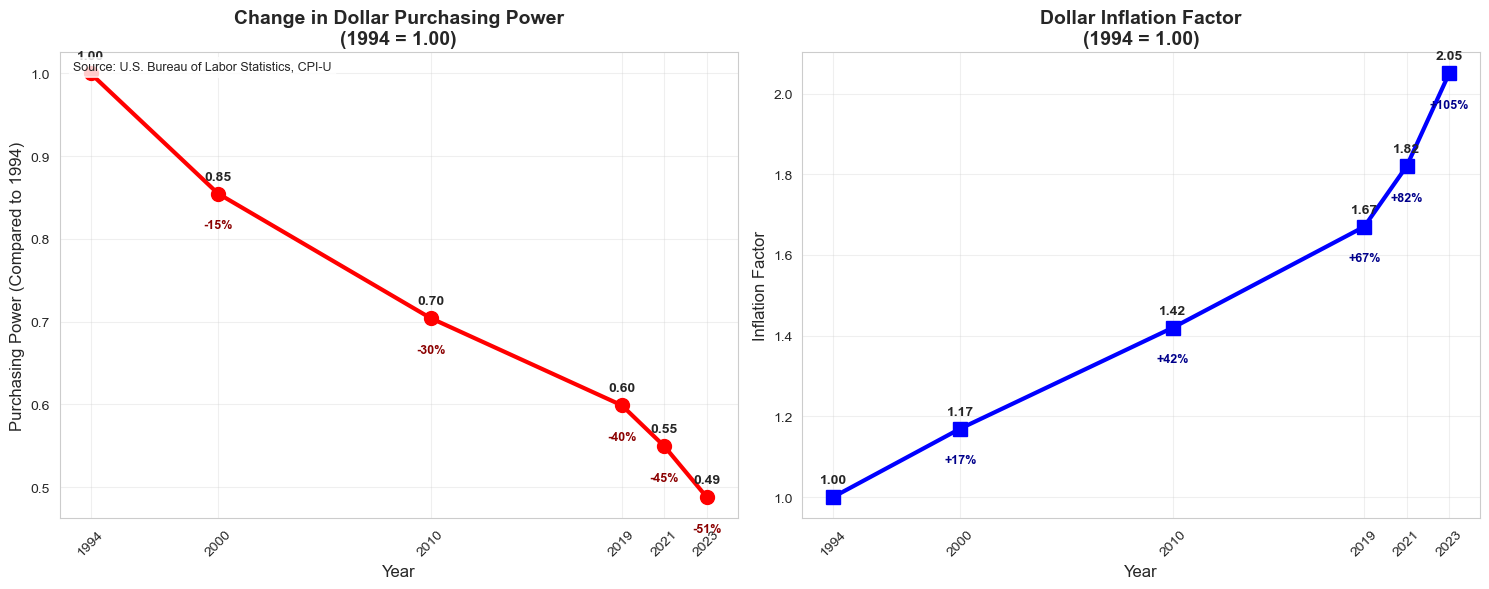

In [50]:
import matplotlib.pyplot as plt
import numpy as np

inflation_factors = {
    1994: 1.00,   # Base year
    2000: 1.17,   # Source: BLS CPI-U 1994-2000
    2010: 1.42,   # Source: BLS CPI-U 1994-2010  
    2019: 1.67,   # Source: BLS CPI-U 1994-2019
    2021: 1.82,   # Source: BLS CPI-U 1994-2021
    2023: 2.05    # End of 2023 estimate based on BLS data
}

years = list(inflation_factors.keys())
inflation_values = list(inflation_factors.values())

# Calculate dollar value (inverse of inflation factor)
dollar_value = [1/value for value in inflation_values]

plt.figure(figsize=(15, 6))

#Dollar purchasing power over time
plt.subplot(1, 2, 1)
plt.plot(years, dollar_value, marker='o', linewidth=3, markersize=10, color='red', label='Purchasing Power')
plt.title('Change in Dollar Purchasing Power\n(1994 = 1.00)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Purchasing Power (Compared to 1994)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.xticks(years, rotation=45)


for i, (year, value) in enumerate(zip(years, dollar_value)):
    plt.annotate(f'{value:.2f}', (year, value), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=10, fontweight='bold')


plt.text(0.02, 0.98, 'Source: U.S. Bureau of Labor Statistics, CPI-U', 
         transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


for i, (year, value) in enumerate(zip(years, dollar_value)):
    if year != 1994:
        power_loss = (1 - value) * 100
        plt.annotate(f'-{power_loss:.0f}%', (year, value), 
                     textcoords="offset points", xytext=(0,-25), 
                     ha='center', fontsize=9, color='darkred', fontweight='bold')

#Inflation factor over time
plt.subplot(1, 2, 2)
plt.plot(years, inflation_values, marker='s', linewidth=3, markersize=10, color='blue', label='Inflation Factor')
plt.title('Dollar Inflation Factor\n(1994 = 1.00)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Factor', fontsize=12)
plt.grid(True, alpha=0.3)


plt.xticks(years, rotation=45)


for i, (year, value) in enumerate(zip(years, inflation_values)):
    plt.annotate(f'{value:.2f}', (year, value), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=10, fontweight='bold')


for i, (year, value) in enumerate(zip(years, inflation_values)):
    if year != 1994:
        percentage_change = (value - 1) * 100
        plt.annotate(f'+{percentage_change:.0f}%', (year, value), 
                     textcoords="offset points", xytext=(0,-25), 
                     ha='center', fontsize=9, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.show()

In [51]:
print("TABLE OF DOLLAR VALUE AND INFLATION FACTOR CHANGES")
print("Source: U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)")

print(f"{'Year':<8} {'Inflation Factor':<18} {'Dollar Value':<18} {'Purchasing Power Loss':<25}")


for year, infl_factor in inflation_factors.items():
    dollar_val = 1 / infl_factor
    power_loss = (1 - dollar_val) * 100  # More accurate: purchasing power loss
    cumulative_inflation = (infl_factor - 1) * 100  # Cumulative inflation since 1994
    
    print(f"{year:<8} {infl_factor:<18.2f} {dollar_val:<18.2f} {power_loss:<25.1f}%")


print(f"Data Source: U.S. Bureau of Labor Statistics, Consumer Price Index")
print(f"Base Year: 1994 = 1.00")


print("ANNUAL INFLATION RATES BETWEEN PERIODS")
print("Based on BLS CPI-U Data")


sorted_years = sorted(inflation_factors.keys())
for i in range(1, len(sorted_years)):
    prev_year = sorted_years[i-1]
    curr_year = sorted_years[i]
    years_diff = curr_year - prev_year
    
#Calculate compound annual growth rate (more accurate)
    start_factor = inflation_factors[prev_year]
    end_factor = inflation_factors[curr_year]
    total_growth = (end_factor / start_factor - 1) * 100
    annual_rate = ((end_factor / start_factor) ** (1/years_diff) - 1) * 100
    
    print(f"{prev_year}-{curr_year} ({years_diff} years):")
    print(f" Total inflation: {total_growth:.1f}%")
    print(f" Annual rate: {annual_rate:.1f}%")
    print(f" Period description: {prev_year} to {curr_year}")

TABLE OF DOLLAR VALUE AND INFLATION FACTOR CHANGES
Source: U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)
Year     Inflation Factor   Dollar Value       Purchasing Power Loss    
1994     1.00               1.00               0.0                      %
2000     1.17               0.85               14.5                     %
2010     1.42               0.70               29.6                     %
2019     1.67               0.60               40.1                     %
2021     1.82               0.55               45.1                     %
2023     2.05               0.49               51.2                     %
Data Source: U.S. Bureau of Labor Statistics, Consumer Price Index
Base Year: 1994 = 1.00
ANNUAL INFLATION RATES BETWEEN PERIODS
Based on BLS CPI-U Data
1994-2000 (6 years):
 Total inflation: 17.0%
 Annual rate: 2.7%
 Period description: 1994 to 2000
2000-2010 (10 years):
 Total inflation: 21.4%
 Annual rate: 2.0%
 Period description: 2000 to 2010
2010-2019 (9 years):
 T

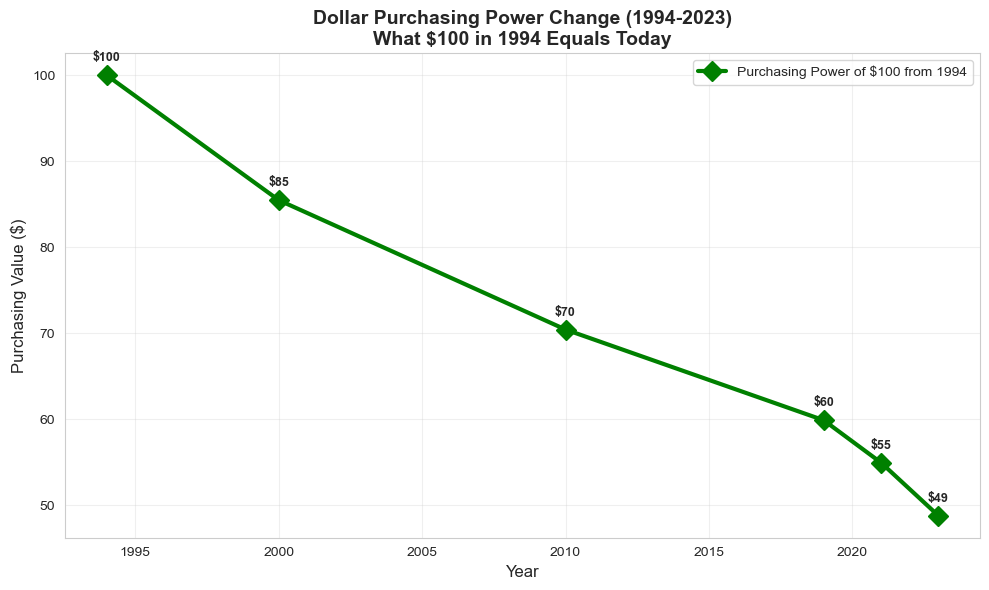

In [52]:
#chart showing purchasing power
plt.figure(figsize=(10, 6))

#What $100 in 1994 could buy across the years
purchasing_power = [100 / value for value in inflation_values]

plt.plot(years, purchasing_power, marker='D', linewidth=3, markersize=10,
         color='green', label='Purchasing Power of $100 from 1994')

plt.title('Dollar Purchasing Power Change (1994-2023)\nWhat $100 in 1994 Equals Today',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Purchasing Value ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


for i, (year, value) in enumerate(zip(years, purchasing_power)):
    plt.annotate(f'${value:.0f}', (year, value), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [53]:
def calculate_thresholds_all_years():

    inflation_factors = {
        1994: 1.00,
        2000: 1.17,
        2010: 1.42,
        2019: 1.67,
        2021: 1.82,
        2023: 2.05
    }
    
    base_threshold_1994 = 50000
    
    print("FIXED INCOME THRESHOLDS ACROSS YEARS")
    print("Source: U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)")
    
    print(f"{'Year':<8} {'Inflation Factor':<18} {'$50K 1994 Equivalent':<25}")

    
    thresholds_dict = {}
    for year, factor in sorted(inflation_factors.items()):
        threshold = base_threshold_1994 * factor
        thresholds_dict[year] = threshold
        cumulative_inflation = (factor - 1) * 100
        
        print(f"{year:<8} {factor:<18.2f} ${threshold:,.0f}")
        
    print(f"ADDITIONAL INFORMATION:")
    print(f"Base threshold: $50,000 in 1994 dollars")
    print(f"Cumulative inflation 1994-2023: +{(inflation_factors[2023] - 1) * 100:.0f}%")
    print(f"$50,000 in 1994 = ${50000 * inflation_factors[2023]:,.0f} in 2023")
    
    return thresholds_dict

thresholds = calculate_thresholds_all_years()

FIXED INCOME THRESHOLDS ACROSS YEARS
Source: U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)
Year     Inflation Factor   $50K 1994 Equivalent     
1994     1.00               $50,000
2000     1.17               $58,500
2010     1.42               $71,000
2019     1.67               $83,500
2021     1.82               $91,000
2023     2.05               $102,500
ADDITIONAL INFORMATION:
Base threshold: $50,000 in 1994 dollars
Cumulative inflation 1994-2023: +105%
$50,000 in 1994 = $102,500 in 2023


In [54]:
def create_unified_income_classifier():
    def classify_income(df, year, income_column='income_1994_value'):
        
#Fixed threshold across all years (in 1994 value)
        fixed_threshold_1994 = 50000
        
        df['income_category'] = df[income_column] > fixed_threshold_1994
        df['income_category_label'] = df['income_category'].map({
            True: 'High income (>$50K 1994 value)', 
            False: 'Low income (≤$50K 1994 value)'
        })
        
        high_income_pct = df['income_category'].mean() * 100
        print(f"{year}: {high_income_pct:.1f}% high income (threshold: $50,000 in 1994 value)")
        
        return df
    
    return classify_income

# Or use year-adjusted thresholds:

def create_adjusted_income_classifier():
    
# Adjusted thresholds from BLS (in each year’s value)
    adjusted_thresholds = {
        1994: 50000,    # $50,000 in 1994
        2000: 58500,    # $50,000 × 1.17
        2010: 71000,    # $50,000 × 1.42  
        2019: 83500,    # $50,000 × 1.67
        2021: 91000,    # $50,000 × 1.82
        2023: 102500    # $50,000 × 2.05
    }
    
    def classify_income_adjusted(df, year, income_column='income_numeric'):
        
        threshold = adjusted_thresholds[year]
        
        df['income_category'] = df[income_column] > threshold
        df['income_category_label'] = df['income_category'].map({
            True: f'High income (>${threshold/1000:.0f}K {year} value)',
            False: f'Low income (≤${threshold/1000:.0f}K {year} value)'
        })
        
        high_income_pct = df['income_category'].mean() * 100
        print(f"{year}: {high_income_pct:.1f}% high income (threshold: ${threshold:,.0f})")
        
        return df
    
    return classify_income_adjusted

In [55]:
def save_unified_threshold_config():
    from datetime import datetime
    
    unified_config = {
        "methodology": "UNIFIED $50,000 threshold in 1994 dollars",
        "base_year": 1994,
        "base_threshold": 50000,
        "data_source": "U.S. Bureau of Labor Statistics, CPI-U (1994=1.00)",
        "classification": {
            "high_income_label": "High income (>$50K 1994 value)",
            "low_income_label": "Low income (≤$50K 1994 value)", 
            "threshold_column": "income_1994_value",
            "threshold_value": 50000
        },
        "inflation_reference": {
            1994: 1.00,
            2000: 1.17,
            2010: 1.42, 
            2019: 1.67,
            2021: 1.82,
            2023: 2.05
        },
        "purpose": "Fair cross-year comparison for education-income analysis",
        "analysis_notes": [
            "All income values converted to 1994 dollars for comparison",
            "Fixed threshold ensures consistent measurement of economic mobility", 
            "Ideal for analyzing education impact on income across decades"
        ],
        "last_updated": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    
    import json
    with open('unified_threshold_config.json', 'w') as f:
        json.dump(unified_config, f, indent=2)
    
    print("UNIFIED THRESHOLD CONFIGURATION SAVED")
    print("Methodology: Fixed $50,000 in 1994 dollars")
    print("Purpose: Education-income analysis across years")
    print("File: unified_threshold_config.json")
    
    return unified_config

    print("ANALYZING 1994 DATA")
    analyze_1994_income_only(income_data_clean)
    create_1994_income_visualization(income_data_clean)

unified_config = save_unified_threshold_config()

UNIFIED THRESHOLD CONFIGURATION SAVED
Methodology: Fixed $50,000 in 1994 dollars
Purpose: Education-income analysis across years
File: unified_threshold_config.json


ANALYZING 1994 DATA
1994 INCOME ANALYSIS - UNIFIED THRESHOLD
INCOME CATEGORY DISTRIBUTION ($50K 1994 Threshold):
   Low income (≤$50K 1994 value): 23,046 people (75.1%)
   High income (>$50K 1994 value): 7,648 people (24.9%)
INCOME STATISTICS:
   1994 Value - Average: $37,458
   1994 Value - Median: $25,000
   2023 Value - Average: $76,790
   2023 Value - Median: $51,250
   Standard Deviation: $44,335
CLASSIFICATION COMPARISON:
   Original 1994 (>$50K nominal): 24.9%
   Unified threshold (>$50K 1994 value): 24.9%
   Difference: +0.0%


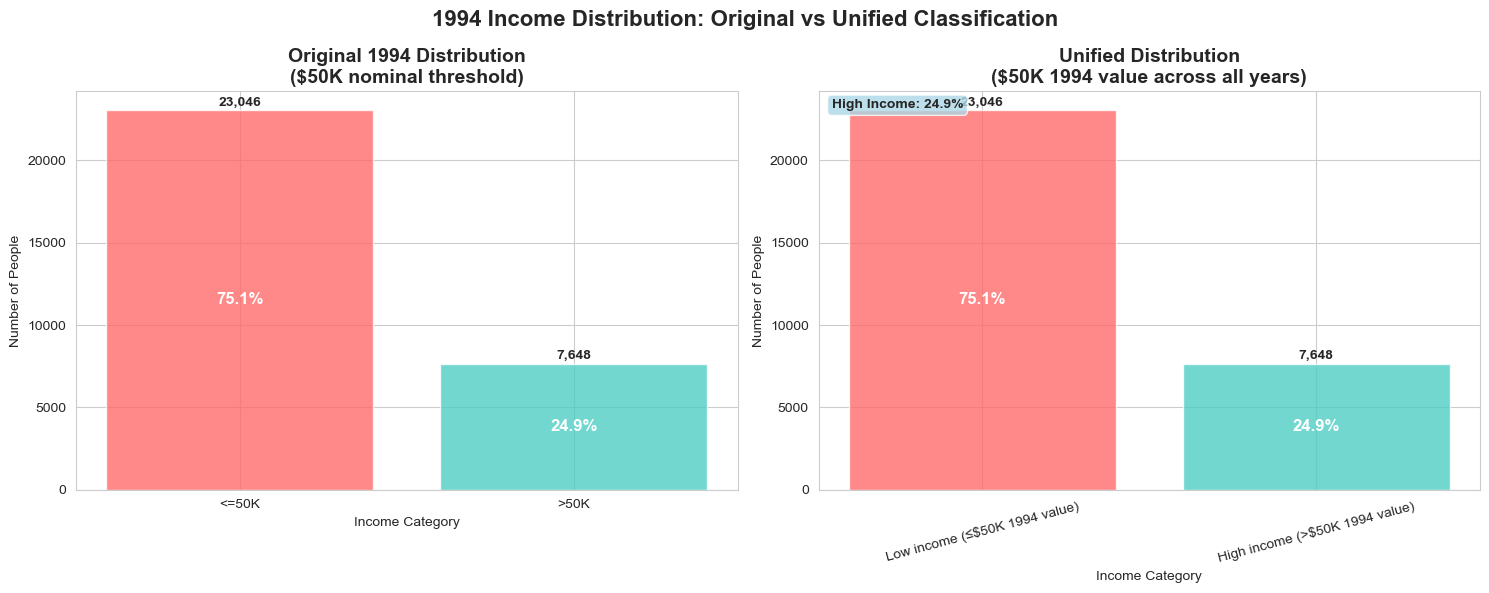

VISUALIZATION SUMMARY - 1994
Left: Original 1994 classification (text categories)
Right: Unified classification ($50K 1994 value)
Total records: 30,694
High income rate: 24.9%
Inflation factor 1994→2023: 2.05x


In [56]:
import matplotlib.pyplot as plt

def analyze_1994_income_only(data):
    
    print("1994 INCOME ANALYSIS - UNIFIED THRESHOLD")
    
#Income category distribution
    print("INCOME CATEGORY DISTRIBUTION ($50K 1994 Threshold):")
    income_dist = data['income_category_label'].value_counts()
    for category, count in income_dist.items():
        percentage = (count / len(data)) * 100
        print(f"   {category}: {count:,} people ({percentage:.1f}%)")
    
#Income statistics
    print("INCOME STATISTICS:")
    print(f"   1994 Value - Average: ${data['income_1994_value'].mean():,.0f}")
    print(f"   1994 Value - Median: ${data['income_1994_value'].median():,.0f}")
    print(f"   2023 Value - Average: ${data['income_2023_value'].mean():,.0f}")
    print(f"   2023 Value - Median: ${data['income_2023_value'].median():,.0f}")
    print(f"   Standard Deviation: ${data['income_2023_value'].std():,.0f}")
    
#Comparison between original and unified classification
    original_high_income = (data['income'] == '>50K').mean() * 100
    unified_high_income = (data['income_category'] == True).mean() * 100
    
    print(f"CLASSIFICATION COMPARISON:")
    print(f"   Original 1994 (>$50K nominal): {original_high_income:.1f}%")
    print(f"   Unified threshold (>$50K 1994 value): {unified_high_income:.1f}%")
    print(f"   Difference: {unified_high_income - original_high_income:+.1f}%")

def create_1994_income_visualization(data):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    #Original 1994 distribution
    original_counts = data['income'].value_counts()
    colors = ['#FF6B6B', '#4ECDC4']  # Red for low income, light blue for high income
    
    bars1 = ax1.bar(original_counts.index, original_counts.values, color=colors, alpha=0.8)
    ax1.set_title('Original 1994 Distribution\n($50K nominal threshold)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of People')
    ax1.set_xlabel('Income Category')
    
   
    for bar, count in zip(bars1, original_counts.values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 100, f'{count:,}', 
                 ha='center', va='bottom', fontweight='bold')
    
  
    total = len(data)
    for i, (category, count) in enumerate(original_counts.items()):
        percentage = (count / total) * 100
        ax1.text(i, count/2, f'{percentage:.1f}%', 
                 ha='center', va='center', fontweight='bold', fontsize=12, color='white')
    
    #Unified distribution
    unified_counts = data['income_category_label'].value_counts()
    
    bars2 = ax2.bar(unified_counts.index, unified_counts.values, color=colors, alpha=0.8)
    ax2.set_title('Unified Distribution\n($50K 1994 value across all years)', 
                  fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of People')
    ax2.set_xlabel('Income Category')
    ax2.tick_params(axis='x', rotation=15)
    
    
    for bar, count in zip(bars2, unified_counts.values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 100, f'{count:,}', 
                 ha='center', va='bottom', fontweight='bold')
    

    for i, (category, count) in enumerate(unified_counts.items()):
        percentage = (count / total) * 100
        ax2.text(i, count/2, f'{percentage:.1f}%', 
                 ha='center', va='center', fontweight='bold', fontsize=12, color='white')
    
    
    high_income_pct = (data['income_category'].mean() * 100)
    ax2.text(0.02, 0.98, f'High Income: {high_income_pct:.1f}%', 
             transform=ax2.transAxes, ha='left', va='top', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8),
             fontweight='bold')
    
    
    plt.suptitle('1994 Income Distribution: Original vs Unified Classification', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    print(f"VISUALIZATION SUMMARY - 1994")
    print("Left: Original 1994 classification (text categories)")
    print("Right: Unified classification ($50K 1994 value)")
    print(f"Total records: {len(data):,}")
    print(f"High income rate: {high_income_pct:.1f}%")
    print(f"Inflation factor 1994→2023: 2.05x")


print("ANALYZING 1994 DATA")


analyze_1994_income_only(income_data_clean)
create_1994_income_visualization(income_data_clean)

In [57]:
print(f"Total records: {len(income_data_clean):,}")
print(f"Total columns: {len(income_data_clean.columns)}")
print(f"Missing values: {income_data_clean.isna().sum().sum()}")

Total records: 30,694
Total columns: 28
Missing values: 0


In [58]:
print(income_data_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 30694 entries, 1 to 32536
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   YEAR                   30694 non-null  int64  
 1   age                    30694 non-null  int64  
 2   workclass              30694 non-null  object 
 3   final_weight           30694 non-null  int64  
 4   education              30694 non-null  object 
 5   education_years        30694 non-null  int64  
 6   marital_status         30694 non-null  object 
 7   occupation             30694 non-null  object 
 8   relationship           30694 non-null  object 
 9   race                   30694 non-null  object 
 10  gender                 30694 non-null  object 
 11  capital_gain           30694 non-null  int64  
 12  capital_loss           30694 non-null  int64  
 13  hours_per_week         30694 non-null  int64  
 14  native_country         30694 non-null  object 
 15  income 

In [59]:
income_data_clean.to_csv('cleaned_income_analysis_data.csv', index=False, encoding='utf-8-sig')
print(" Final dataset saved as 'cleaned_income_analysis_data.csv'")

import os
if os.path.exists('cleaned_income_analysis_data.csv'):
    file_size = os.path.getsize('cleaned_income_analysis_data.csv')
    print(f"File saved successfully!")
    print(f"File name: cleaned_income_analysis_data.csv")
    print(f"File size: {file_size:,} bytes")
    print(f"Number of rows: {len(income_data_clean):,}")
    print(f"Number of columns: {len(income_data_clean.columns)}")
else:
    print("Error: File was not saved")

 Final dataset saved as 'cleaned_income_analysis_data.csv'
File saved successfully!
File name: cleaned_income_analysis_data.csv
File size: 9,951,261 bytes
Number of rows: 30,694
Number of columns: 28


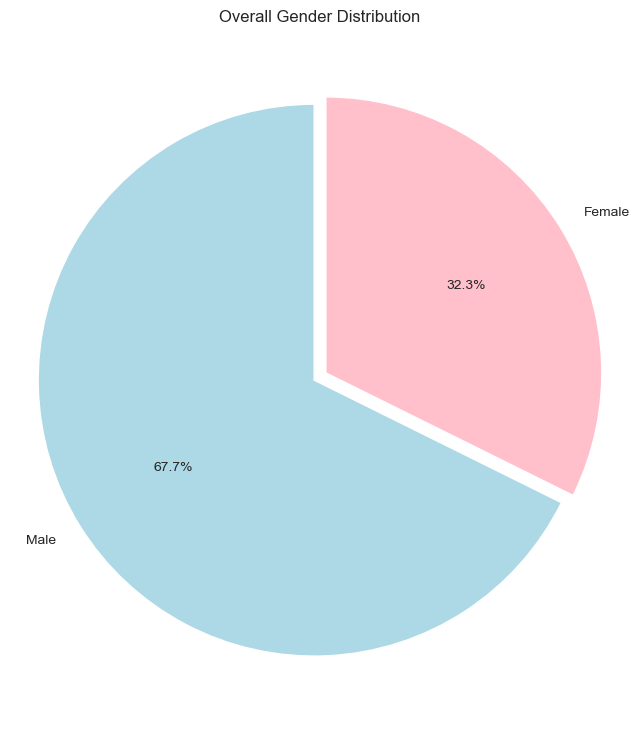

Total number of individuals: 30694
Number of males: 20773
Number of females: 9921
Percentage of males: 67.7%
Percentage of females: 32.3%


In [60]:
total_data = income_data_clean
total_gender_counts = total_data['gender'].value_counts()

plt.figure(figsize=(8, 9))
plt.pie(total_gender_counts.values, 
        labels=total_gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['lightblue', 'pink'],
        explode=(0.05, 0))

plt.title('Overall Gender Distribution')
plt.axis('equal')
plt.show()

print(f"Total number of individuals: {len(total_data)}")
print(f"Number of males: {total_gender_counts.get('Male', 0)}")
print(f"Number of females: {total_gender_counts.get('Female', 0)}")
print(f"Percentage of males: {(total_gender_counts.get('Male', 0) / len(total_data) * 100):.1f}%")
print(f"Percentage of females: {(total_gender_counts.get('Female', 0) / len(total_data) * 100):.1f}%")

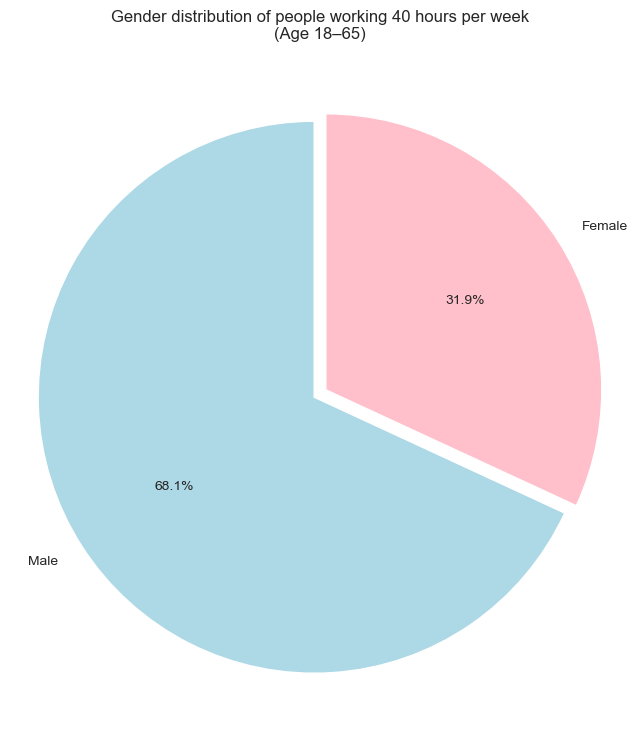

Total number of individuals (age 18–65, 40 working hours): 14262
Number of males: 9713
Number of females: 4549
Percentage of males: 68.1%
Percentage of females: 31.9%


In [61]:
# Filter by age (18–65) and working hours (exactly 40 hours per week)
filtered_data = income_data_clean[
    (income_data_clean['age'] >= 18) & 
    (income_data_clean['age'] <= 65) & 
    (income_data_clean['hours_per_week'] == 40)
]


gender_counts = filtered_data['gender'].value_counts()


plt.figure(figsize=(8, 9))
plt.pie(gender_counts.values, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['lightblue', 'pink'],
        explode=(0.05, 0))  \

plt.title('Gender distribution of people working 40 hours per week\n(Age 18–65)')
plt.axis('equal')
plt.show()


print(f"Total number of individuals (age 18–65, 40 working hours): {len(filtered_data)}")
print(f"Number of males: {gender_counts.get('Male', 0)}")
print(f"Number of females: {gender_counts.get('Female', 0)}")
print(f"Percentage of males: {(gender_counts.get('Male', 0) / len(filtered_data) * 100):.1f}%")
print(f"Percentage of females: {(gender_counts.get('Female', 0) / len(filtered_data) * 100):.1f}%")

In [62]:
# Comparison between filtered and unfiltered data
print("COMPARISON: WITH VS WITHOUT FILTERS")


print(f"{'Metric':<25} {'With Filter':<15} {'Without Filter':<15}")

print(f"{'Total individuals':<25} {len(filtered_data):<15,} {len(total_data):<15,}")
print(f"{'Males':<25} {gender_counts.get('Male', 0):<15,} {total_gender_counts.get('Male', 0):<15,}")
print(f"{'Females':<25} {gender_counts.get('Female', 0):<15,} {total_gender_counts.get('Female', 0):<15,}")
print(f"{'Male %':<25} {(gender_counts.get('Male', 0)/len(filtered_data)*100):<15.1f} {(total_gender_counts.get('Male', 0)/len(total_data)*100):<15.1f}")
print(f"{'Female %':<25} {(gender_counts.get('Female', 0)/len(filtered_data)*100):<15.1f} {(total_gender_counts.get('Female', 0)/len(total_data)*100):<15.1f}")


male_diff = ((gender_counts.get('Male', 0)/len(filtered_data)) - 
             (total_gender_counts.get('Male', 0)/len(total_data))) * 100
female_diff = ((gender_counts.get('Female', 0)/len(filtered_data)) - 
               (total_gender_counts.get('Female', 0)/len(total_data))) * 100

print(f"{'Difference (Male %)':<25} {male_diff:+.1f}%")
print(f"{'Difference (Female %)':<25} {female_diff:+.1f}%")

COMPARISON: WITH VS WITHOUT FILTERS
Metric                    With Filter     Without Filter 
Total individuals         14,262          30,694         
Males                     9,713           20,773         
Females                   4,549           9,921          
Male %                    68.1            67.7           
Female %                  31.9            32.3           
Difference (Male %)       +0.4%
Difference (Female %)     -0.4%


In [63]:
# Analyze distribution by age and working hours
print("DETAILED GENDER ANALYSIS")
#By age groups
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
total_data['age_group'] = pd.cut(total_data['age'], bins=age_bins, labels=age_labels)

#By working hours
hours_bins = [0, 20, 40, 60, 168]
hours_labels = ['Part-time (<20)', 'Full-time (20-40)', 'Overtime (40-60)', 'Excessive (>60)']
total_data['hours_group'] = pd.cut(total_data['hours_per_week'], bins=hours_bins, labels=hours_labels)

# Distribution analysis
print("Gender distribution by age group:")
age_gender = pd.crosstab(total_data['age_group'], total_data['gender'], normalize='index') * 100
print(age_gender.round(1))

print("Gender distribution by working hours:")
hours_gender = pd.crosstab(total_data['hours_group'], total_data['gender'], normalize='index') * 100
print(hours_gender.round(1))

DETAILED GENDER ANALYSIS
Gender distribution by age group:
gender     Female  Male
age_group              
18-25        43.1  56.9
26-35        31.1  68.9
36-45        29.3  70.7
46-55        28.9  71.1
56-65        28.5  71.5
65+          32.9  67.1
Gender distribution by working hours:
gender             Female  Male
hours_group                    
Part-time (<20)      53.3  46.7
Full-time (20-40)    36.7  63.3
Overtime (40-60)     18.4  81.6
Excessive (>60)      15.2  84.8


In [62]:
#checking 2000s dataset

In [64]:
import pandas as pd
import numpy as np


file_paths = {
    2000: 'ipums_2000.csv', 
    2010: 'ipums_2010.csv',
    2019: 'ipums_2019.csv',
    2021: 'ipums_2021.csv',
    2023: 'ipums_2023.csv'
}

loaded_data = {}

# Add 1994 from pre-cleaned data
loaded_data[1994] = income_data_clean
print(f"1994: Added from pre-cleaned data - {income_data_clean.shape[0]:,} rows")

print("Loading other files...")

for year, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)
        loaded_data[year] = df
        print(f"Done {year}: Loaded successfully - {len(df):,} rows")
        
    except Exception as e:
        print(f" {year}: Error - {e}")


print(f"Total files loaded: {len(loaded_data)} files")

1994: Added from pre-cleaned data - 30,694 rows
Loading other files...
Done 2000: Loaded successfully - 277,972 rows
Done 2010: Loaded successfully - 11,474,268 rows
Done 2019: Loaded successfully - 12,558,157 rows
Done 2021: Loaded successfully - 12,323,532 rows
Done 2023: Loaded successfully - 2,736,736 rows
Total files loaded: 6 files


In [65]:
def remove_only_weight_columns(loaded_data):  
    print("Removing weight columns only")
    weight_columns = ['HHWT', 'PERWT', 'final_weight']
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"Year {year}:")
            print(f"   Before: {len(df.columns)} columns")
            
# Identify weight columns that actually exist
            existing_weight_cols = [col for col in weight_columns if col in df.columns]
            
            if existing_weight_cols:
                # Remove weight columns only
                df_clean = df.drop(columns=existing_weight_cols)
                print(f"   Removed: {existing_weight_cols}")
                print(f"   After: {len(df_clean.columns)} columns")
                
                loaded_data[year] = df_clean
            else:
                print(f"   No weight columns to remove")
    
    return loaded_data

print("Removing weight columns...")
loaded_data = remove_only_weight_columns(loaded_data)

Removing weight columns...
Removing weight columns only
Year 1994:
   Before: 30 columns
   Removed: ['final_weight']
   After: 29 columns
Year 2000:
   Before: 25 columns
   Removed: ['HHWT', 'PERWT']
   After: 23 columns
Year 2010:
   Before: 27 columns
   Removed: ['HHWT', 'PERWT']
   After: 25 columns
Year 2019:
   Before: 31 columns
   Removed: ['HHWT', 'PERWT']
   After: 29 columns
Year 2021:
   Before: 31 columns
   Removed: ['HHWT', 'PERWT']
   After: 29 columns
Year 2023:
   Before: 30 columns
   Removed: ['HHWT', 'PERWT']
   After: 28 columns


In [66]:
def remove_race_columns(loaded_data):
    print("Removing race columns")
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"Year {year}:")
            print(f"   Before: {len(df.columns)} columns")
            # Define race columns depending on the year
            if year == 1994:
                race_columns = ['race']
            else:
                race_columns = ['RACE', 'RACED']

            existing_race_cols = [col for col in race_columns if col in df.columns]
            
            if existing_race_cols:
                df_clean = df.drop(columns=existing_race_cols)
                print(f"   Removed: {existing_race_cols}")
                print(f"   After: {len(df_clean.columns)} columns")

                loaded_data[year] = df_clean
            else:
                print(f"   No race columns to remove")
    
    return loaded_data

print("Removing race columns...")
loaded_data = remove_race_columns(loaded_data)

Removing race columns...
Removing race columns
Year 1994:
   Before: 29 columns
   Removed: ['race']
   After: 28 columns
Year 2000:
   Before: 23 columns
   Removed: ['RACE', 'RACED']
   After: 21 columns
Year 2010:
   Before: 25 columns
   Removed: ['RACE', 'RACED']
   After: 23 columns
Year 2019:
   Before: 29 columns
   Removed: ['RACE', 'RACED']
   After: 27 columns
Year 2021:
   Before: 29 columns
   Removed: ['RACE', 'RACED']
   After: 27 columns
Year 2023:
   Before: 28 columns
   Removed: ['RACE', 'RACED']
   After: 26 columns


In [67]:
def remove_additional_columns(loaded_data):
    print("Removing additional columns")
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"Year {year}:")
            print(f"   Before: {len(df.columns)} columns")

            if year == 1994:
                columns_to_remove = ['relationship', 'native_country']
            else:

                columns_to_remove = [
                    'SAMPLE', 'GQ', 'STRATA', 'PERNUM', 'SERIAL', 'CLUSTER',
                    'MULTYEAR', 'CBSERIAL', 'POVERTY'
                ]
            
            existing_cols = [col for col in columns_to_remove if col in df.columns]
            
            if existing_cols:

                df_clean = df.drop(columns=existing_cols)
                print(f"   Removed: {existing_cols}")
                print(f"   After: {len(df_clean.columns)} columns")
                
                # Update the dataset with the cleaned version
                loaded_data[year] = df_clean
            else:
                print(f"   No additional columns to remove")
    
    return loaded_data

print("Removing additional columns...")
loaded_data = remove_additional_columns(loaded_data)

Removing additional columns...
Removing additional columns
Year 1994:
   Before: 28 columns
   Removed: ['relationship', 'native_country']
   After: 26 columns
Year 2000:
   Before: 21 columns
   Removed: ['SAMPLE', 'GQ', 'STRATA', 'PERNUM', 'SERIAL', 'CLUSTER', 'POVERTY']
   After: 14 columns
Year 2010:
   Before: 23 columns
   Removed: ['SAMPLE', 'GQ', 'STRATA', 'PERNUM', 'SERIAL', 'CLUSTER', 'MULTYEAR', 'CBSERIAL', 'POVERTY']
   After: 14 columns
Year 2019:
   Before: 27 columns
   Removed: ['SAMPLE', 'GQ', 'STRATA', 'PERNUM', 'SERIAL', 'CLUSTER', 'MULTYEAR', 'CBSERIAL', 'POVERTY']
   After: 18 columns
Year 2021:
   Before: 27 columns
   Removed: ['SAMPLE', 'GQ', 'STRATA', 'PERNUM', 'SERIAL', 'CLUSTER', 'MULTYEAR', 'CBSERIAL', 'POVERTY']
   After: 18 columns
Year 2023:
   Before: 26 columns
   Removed: ['SAMPLE', 'GQ', 'STRATA', 'PERNUM', 'SERIAL', 'CLUSTER', 'CBSERIAL', 'POVERTY']
   After: 18 columns


In [68]:
def delete_zero_and_minimal_hours(df):
    
    original_size = len(df)
    
    
    df_cleaned = df[df['UHRSWORK'] > 1].copy()
    
    deleted_count = original_size - len(df_cleaned)
    deletion_percentage = (deleted_count / original_size) * 100
      
    zero_one_deleted = len(df[df['UHRSWORK'] <= 1])
    
    print(f"Deletion: {original_size:,} → {len(df_cleaned):,}")
    print(f"- 0-1 hours deleted: {zero_one_deleted:,}")
    print(f"- Total deleted: {deleted_count:,} ({deletion_percentage:.1f}%)")
    print(f"- Hours range kept: {df_cleaned['UHRSWORK'].min():.0f}-{df_cleaned['UHRSWORK'].max():.0f}")
    
    return df_cleaned

print("Deleting 0-1 hours – Keeping 2+ hours (2000–2023)...")

years_to_clean = [2000, 2010, 2019, 2021, 2023]

for year in years_to_clean:
    if year in loaded_data:
        print(f"\n{year}:")
        original_size = len(loaded_data[year])
        
        
        loaded_data[year] = delete_zero_and_minimal_hours(loaded_data[year])
        
        
        current_df = loaded_data[year]
        print(f"Final size: {len(current_df):,} records")
        print(f"Average working hours: {current_df['UHRSWORK'].mean():.1f}")
        
        
        part_time_stats = current_df[(current_df['UHRSWORK'] >= 2) & (current_df['UHRSWORK'] <= 29)]
        full_time_stats = current_df[current_df['UHRSWORK'] >= 30]
        
        print(f"Part-time workers (2-29 hrs): {len(part_time_stats):,} ({len(part_time_stats)/len(current_df)*100:.1f}%)")
        print(f"Full-time workers (30+ hrs): {len(full_time_stats):,} ({len(full_time_stats)/len(current_df)*100:.1f}%)")

print("0-1 hours deleted from years 2000–2023")
print("Hours 2+ preserved for comprehensive analysis")
print(f"Year 1994 kept as is ({len(loaded_data[1994]):,} records)")

Deleting 0-1 hours – Keeping 2+ hours (2000–2023)...

2000:
Deletion: 277,972 → 202,571
- 0-1 hours deleted: 75,401
- Total deleted: 75,401 (27.1%)
- Hours range kept: 2-99
Final size: 202,571 records
Average working hours: 39.7
Part-time workers (2-29 hrs): 29,878 (14.7%)
Full-time workers (30+ hrs): 172,693 (85.3%)

2010:
Deletion: 11,474,268 → 7,783,445
- 0-1 hours deleted: 3,690,823
- Total deleted: 3,690,823 (32.2%)
- Hours range kept: 2-99
Final size: 7,783,445 records
Average working hours: 38.9
Part-time workers (2-29 hrs): 1,260,583 (16.2%)
Full-time workers (30+ hrs): 6,522,862 (83.8%)

2019:
Deletion: 12,558,157 → 8,104,495
- 0-1 hours deleted: 4,453,662
- Total deleted: 4,453,662 (35.5%)
- Hours range kept: 2-99
Final size: 8,104,495 records
Average working hours: 38.5
Part-time workers (2-29 hrs): 1,401,668 (17.3%)
Full-time workers (30+ hrs): 6,702,827 (82.7%)

2021:
Deletion: 12,323,532 → 7,871,427
- 0-1 hours deleted: 4,452,105
- Total deleted: 4,452,105 (36.1%)
- Hours

In [68]:
#Age column in all datas

In [69]:
def process_age_column_directly(loaded_data):
    print("Process age column directly (modify original)")
    
    for year, df in loaded_data.items():
        if year == 1994:
            print(f"Year {year}: Already processed - skipping")
            continue
            
        print(f"Year {year}")
        
        
        age_columns = [col for col in df.columns if 'age' in col.lower() or col == 'AGE']
        
        if age_columns:
            age_col = age_columns[0]
            print(f"   Working on original column: {age_col}")
            
           
            if age_col == 'AGE':
                df.rename(columns={'AGE': 'age'}, inplace=True)
                print(f"   Renamed: AGE → age")
            
            
            def age_group_acs(age):
                if age <= 24:
                    return 'Age 17 to 24'
                elif age <= 34:
                    return 'Age 25 to 34'
                elif age <= 44:
                    return 'Age 35 to 44'
                elif age <= 54:
                    return 'Age 45 to 54'
                elif age <= 64:
                    return 'Age 55 to 64'
                elif age <= 74:
                    return 'Age 65 to 74'
                else:
                    return 'Age 75 and Over'
            
            def age_group_label(age):
                if age <= 24:
                    return 'Youth Workforce'
                elif age <= 34:
                    return 'Early Career Adults'
                elif age <= 44:
                    return 'Mid Career Adults'
                elif age <= 54:
                    return 'Late Career Adults'
                elif age <= 64:
                    return 'Pre-Retirement Age'
                elif age <= 74:
                    return 'Senior Workforce'
                else:
                    return 'Extended Workforce'
            
            def age_group_1994_style(age):
                if age <= 25:
                    return '18-25'
                elif age <= 35:
                    return '26-35'
                elif age <= 45:
                    return '36-45'
                elif age <= 55:
                    return '46-55'
                elif age <= 65:
                    return '56-65'
                else:
                    return '65+'
            
            
            df['age_group_acs'] = df['age'].apply(age_group_acs)
            df['age_group_label'] = df['age'].apply(age_group_label)
            df['age_group'] = df['age'].apply(age_group_1994_style)
            
            print(f"   Created age_group_acs")
            print(f"   Created age_group_label") 
            print(f"   Created age_group (1994 style)")
            
            
            print(f"   Verification:")
            print(f"   - Age range: {df['age'].min()}-{df['age'].max()} years")
            print(f"   - ACS groups: {len(df['age_group_acs'].unique())}")
            print(f"   - 1994 groups: {sorted(df['age_group'].unique())}")
            
        else:
            print(f"   No age column found")
    
    return loaded_data


loaded_data = process_age_column_directly(loaded_data)

Process age column directly (modify original)
Year 1994: Already processed - skipping
Year 2000
   Working on original column: AGE
   Renamed: AGE → age
   Created age_group_acs
   Created age_group_label
   Created age_group (1994 style)
   Verification:
   - Age range: 18-89 years
   - ACS groups: 7
   - 1994 groups: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
Year 2010
   Working on original column: AGE
   Renamed: AGE → age
   Created age_group_acs
   Created age_group_label
   Created age_group (1994 style)
   Verification:
   - Age range: 18-90 years
   - ACS groups: 7
   - 1994 groups: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
Year 2019
   Working on original column: AGE
   Renamed: AGE → age
   Created age_group_acs
   Created age_group_label
   Created age_group (1994 style)
   Verification:
   - Age range: 18-90 years
   - ACS groups: 7
   - 1994 groups: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
Year 2021
   Working on original column: AGE
   Re

In [70]:
print("Final Age Columns Check - Complete Version")

for year, df in loaded_data.items():
    age_cols = [col for col in df.columns if col.lower().startswith('age')]
    print(f"{year}: {age_cols}")
    
    if 'age_group' in df.columns:
        print(f"   age_group categories: {sorted(df['age_group'].unique())}")

Final Age Columns Check - Complete Version
1994: ['age', 'age_group_acs', 'age_group_label', 'age_group']
   age_group categories: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
2000: ['age', 'age_group_acs', 'age_group_label', 'age_group']
   age_group categories: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
2010: ['age', 'age_group_acs', 'age_group_label', 'age_group']
   age_group categories: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
2019: ['age', 'age_group_acs', 'age_group_label', 'age_group']
   age_group categories: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
2021: ['age', 'age_group_acs', 'age_group_label', 'age_group']
   age_group categories: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
2023: ['age', 'age_group_acs', 'age_group_label', 'age_group']
   age_group categories: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']


In [71]:
#Gender column in all datas

In [72]:
def process_gender_column_directly(loaded_data):
    print("Process gender column directly")
    
    for year, df in loaded_data.items():
        if year == 1994:
            print(f"Year {year}: Already processed - skipping")
            continue
            
        print(f"Year {year}")
        
#Search for gender column
        gender_columns = [col for col in df.columns if 'sex' in col.lower() or 'gender' in col.lower() or col == 'SEX']
        
        if gender_columns:
            gender_col = gender_columns[0]
            print(f"   Working on original column: {gender_col}")
            
            if gender_col == 'SEX':
                df.rename(columns={'SEX': 'gender'}, inplace=True)
                print(f"   Renamed: SEX → gender")
            
# Convert numeric codes to text (same as 1994)
            def convert_gender(gender_code):
                if gender_code == 1 or gender_code == '1' or gender_code == 'Male':
                    return 'Male'
                elif gender_code == 2 or gender_code == '2' or gender_code == 'Female':
                    return 'Female'
                else:
                    return 'Unknown'
            
#Apply conversion
            df['gender'] = df['gender'].apply(convert_gender)
            
            print(f"   Converted gender codes to text")
            
            
            gender_counts = df['gender'].value_counts()
            print(f"   Verification:")
            print(f"   - Gender distribution: {gender_counts.to_dict()}")
            print(f"   - Total records: {len(df):,}")
            
        else:
            print(f"   No gender column found")
    
    return loaded_data
loaded_data = process_gender_column_directly(loaded_data)

Process gender column directly
Year 1994: Already processed - skipping
Year 2000
   Working on original column: SEX
   Renamed: SEX → gender
   Converted gender codes to text
   Verification:
   - Gender distribution: {'Male': 105241, 'Female': 97330}
   - Total records: 202,571
Year 2010
   Working on original column: SEX
   Renamed: SEX → gender
   Converted gender codes to text
   Verification:
   - Gender distribution: {'Male': 4052724, 'Female': 3730721}
   - Total records: 7,783,445
Year 2019
   Working on original column: SEX
   Renamed: SEX → gender
   Converted gender codes to text
   Verification:
   - Gender distribution: {'Male': 4225535, 'Female': 3878960}
   - Total records: 8,104,495
Year 2021
   Working on original column: SEX
   Renamed: SEX → gender
   Converted gender codes to text
   Verification:
   - Gender distribution: {'Male': 4106648, 'Female': 3764779}
   - Total records: 7,871,427
Year 2023
   Working on original column: SEX
   Renamed: SEX → gender
   Conve

In [73]:
# Final verification
print("Final Gender Columns Check")

for year, df in loaded_data.items():
    gender_cols = [col for col in df.columns if 'gender' in col.lower()]
    print(f"{year}: {gender_cols}")
    
    if 'gender' in df.columns:
        gender_dist = df['gender'].value_counts().to_dict()
        print(f"   Gender distribution: {gender_dist}")

Final Gender Columns Check
1994: ['gender']
   Gender distribution: {'Male': 20773, 'Female': 9921}
2000: ['gender']
   Gender distribution: {'Male': 105241, 'Female': 97330}
2010: ['gender']
   Gender distribution: {'Male': 4052724, 'Female': 3730721}
2019: ['gender']
   Gender distribution: {'Male': 4225535, 'Female': 3878960}
2021: ['gender']
   Gender distribution: {'Male': 4106648, 'Female': 3764779}
2023: ['gender']
   Gender distribution: {'Male': 897094, 'Female': 828755}


Gender Distribution for (1994 - 2023) Years
1994:
  Total individuals: 30,694
  Males: 20,773 (67.7%)
  Females: 9,921 (32.3%)
2000:
  Total individuals: 202,571
  Males: 105,241 (52.0%)
  Females: 97,330 (48.0%)
2010:
  Total individuals: 7,783,445
  Males: 4,052,724 (52.1%)
  Females: 3,730,721 (47.9%)
2019:
  Total individuals: 8,104,495
  Males: 4,225,535 (52.1%)
  Females: 3,878,960 (47.9%)
2021:
  Total individuals: 7,871,427
  Males: 4,106,648 (52.2%)
  Females: 3,764,779 (47.8%)
2023:
  Total individuals: 1,725,849
  Males: 897,094 (52.0%)
  Females: 828,755 (48.0%)


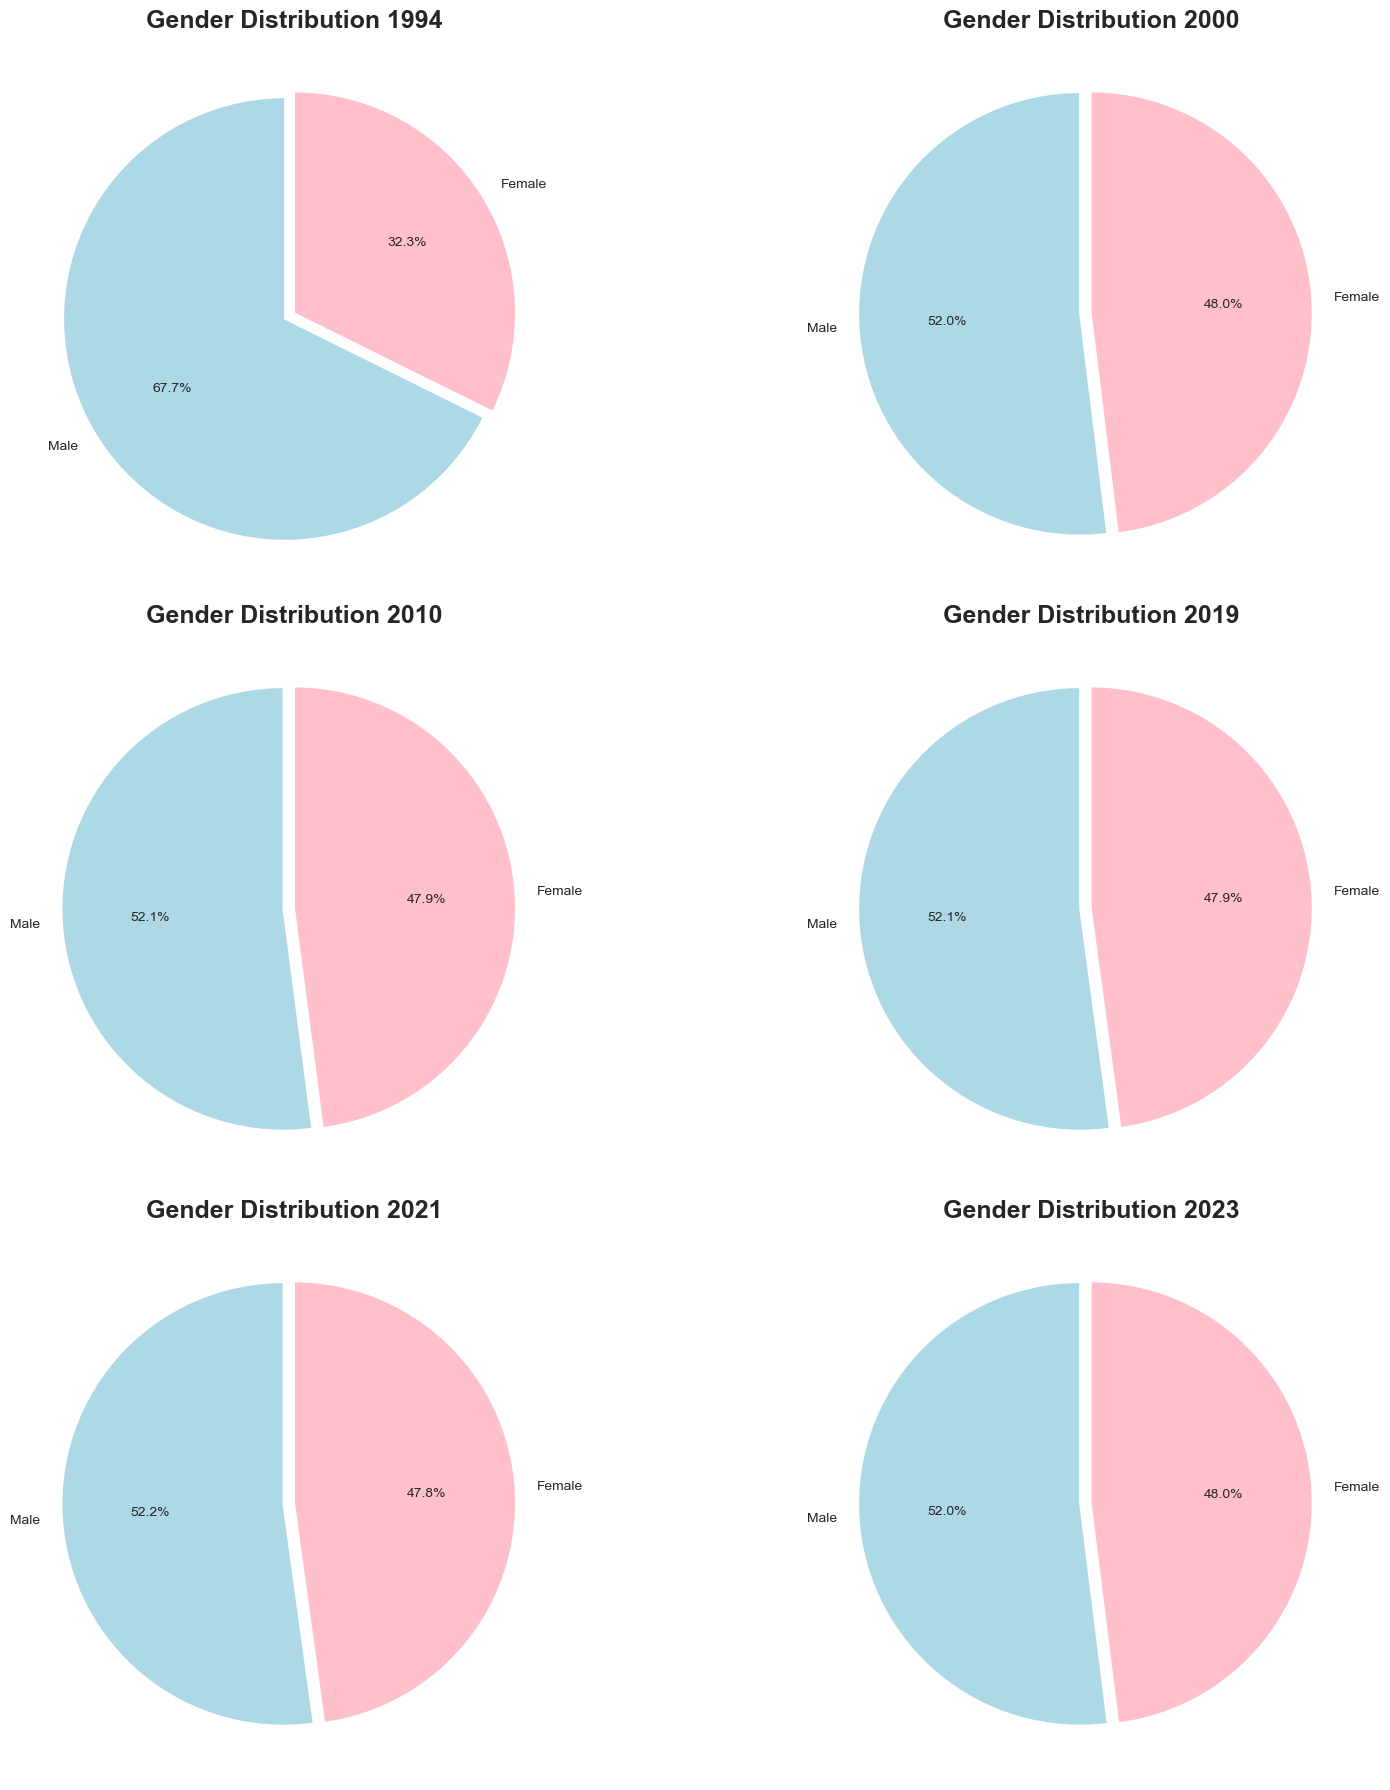

Comparative Gender Distribution
1994: Male 67.7% - Female 32.3%
2000: Male 52.0% - Female 48.0%
2010: Male 52.1% - Female 47.9%
2019: Male 52.1% - Female 47.9%
2021: Male 52.2% - Female 47.8%
2023: Male 52.0% - Female 48.0%


In [74]:
import matplotlib.pyplot as plt

def create_gender_visualization_all_years(loaded_data):
    years_to_plot = [1994, 2000, 2010, 2019, 2021, 2023]

    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    axes = axes.flatten()

    print("Gender Distribution for (1994 - 2023) Years")

    for i, year in enumerate(years_to_plot):
        if year in loaded_data:
            df = loaded_data[year]

            if 'gender' in df.columns:
                gender_counts = df['gender'].value_counts()
                total_individuals = len(df)

                colors = ['lightblue', 'pink']
                explode = (0.05, 0)

                axes[i].pie(
                    gender_counts.values,
                    labels=gender_counts.index,
                    autopct='%1.1f%%',
                    startangle=90,
                    colors=colors,
                    explode=explode
                )

                axes[i].set_title(
                    f'Gender Distribution {year}',
                    fontsize=18,
                    fontweight='bold'
                )

                print(f"{year}:")
                print(f"  Total individuals: {total_individuals:,}")
                print(f"  Males: {gender_counts.get('Male', 0):,} "
                      f"({(gender_counts.get('Male', 0) / total_individuals * 100):.1f}%)")
                print(f"  Females: {gender_counts.get('Female', 0):,} "
                      f"({(gender_counts.get('Female', 0) / total_individuals * 100):.1f}%)")

            else:
                axes[i].text(
                    0.5, 0.5,
                    f'No gender data\nfor {year}',
                    ha='center', va='center',
                    transform=axes[i].transAxes,
                    fontsize=18
                )
                axes[i].set_title(f'Gender Distribution {year}')
        else:
            axes[i].text(
                0.5, 0.5,
                f'No data for {year}',
                ha='center', va='center',
                transform=axes[i].transAxes,
                fontsize=18
            )
            axes[i].set_title(f'Gender Distribution {year}')
    plt.tight_layout()
    plt.show()

    print("Comparative Gender Distribution")

    comparison_data = []
    years_comparison = []

    for year in years_to_plot:
        if year in loaded_data:
            df = loaded_data[year]
            if 'gender' in df.columns:
                gender_counts = df['gender'].value_counts()
                male_pct = (gender_counts.get('Male', 0) / len(df)) * 100
                female_pct = (gender_counts.get('Female', 0) / len(df)) * 100

                comparison_data.append({'Male': male_pct, 'Female': female_pct})
                years_comparison.append(year)

                print(f"{year}: Male {male_pct:.1f}% - Female {female_pct:.1f}%")

    plt.figure(figsize=(14, 6))
create_gender_visualization_all_years(loaded_data)

In [76]:
def prepare_hours_column_2000_2023(loaded_data):
    print("Prepare hours_per_week column for years 2000-2023")    
    years_to_process = [2000, 2010, 2019, 2021 , 2023]
    
    for year in years_to_process:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"Year {year}")
            
            hours_columns = [col for col in df.columns if 'uhrswork' in col.lower() or col == 'UHRSWORK']
            
            if hours_columns:
                hours_col = hours_columns[0]
                print(f"   Found column: {hours_col}")
                
                df.rename(columns={'UHRSWORK': 'hours_per_week'}, inplace=True)
                print(f"   Renamed: UHRSWORK → hours_per_week")
                
                
                print(f"   Basic verification:")
                print(f"- Hours range: {df['hours_per_week'].min()}-{df['hours_per_week'].max()}")
                print(f"- Average hours: {df['hours_per_week'].mean():.1f}")
                print(f"- Total records: {len(df):,}")
                
            else:
                print(f"   No hours column found")
        else:
            print(f"   Year {year} not in loaded_data")
    
    return loaded_data


loaded_data = prepare_hours_column_2000_2023(loaded_data)

print("Hours Column Preparation Check - 2000-2023")

for year in [2000, 2010, 2019, 2021, 2023]:
    if year in loaded_data:
        df = loaded_data[year]
        hours_cols = [col for col in df.columns if 'hour' in col.lower()]
        print(f"{year}: {hours_cols}")
        
        if 'hours_per_week' in df.columns:
            print(f"   Hours range: {df['hours_per_week'].min()}-{df['hours_per_week'].max()}")
            print(f"   Average: {df['hours_per_week'].mean():.1f} hours/week")

Prepare hours_per_week column for years 2000-2023
Year 2000
   No hours column found
Year 2010
   No hours column found
Year 2019
   No hours column found
Year 2021
   No hours column found
Year 2023
   No hours column found
Hours Column Preparation Check - 2000-2023
2000: ['hours_per_week']
   Hours range: 2-99
   Average: 39.7 hours/week
2010: ['hours_per_week']
   Hours range: 2-99
   Average: 38.9 hours/week
2019: ['hours_per_week']
   Hours range: 2-99
   Average: 38.5 hours/week
2021: ['hours_per_week']
   Hours range: 2-99
   Average: 38.4 hours/week
2023: ['hours_per_week']
   Hours range: 2-99
   Average: 38.1 hours/week


In [77]:
def add_hours_derivatives_all_years(loaded_data):
    print("Add hours_group derivative for ALL years (1994-2023)")
    
    for year, df in loaded_data.items():
        print(f"Year {year}")
        
        if 'hours_per_week' in df.columns:
            
            def hours_group(hours):
                
                if hours < 20:
                    return 'Part-time (<20)'
                elif hours <= 40:
                    return 'Full-time (20-40)'
                elif hours <= 60:
                    return 'Overtime (40-60)'
                else:
                    return 'Excessive (>60)'
            
            
            df['hours_group'] = df['hours_per_week'].apply(hours_group)
            
            print(f"   Created hours_group")
            
            
            print(f"   Verification:")
            print(f"   - Hours range: {df['hours_per_week'].min()}-{df['hours_per_week'].max()}")
            print(f"   - Average hours: {df['hours_per_week'].mean():.1f}")
            
            
            group_distribution = df['hours_group'].value_counts().to_dict()
            print(f"   - Groups distribution: {group_distribution}")
            
        else:
            print(f"   No hours_per_week column found")
    
    return loaded_data


loaded_data = add_hours_derivatives_all_years(loaded_data)


print("Final Hours Columns Check - All Years with hours_group")


for year in [1994, 2000, 2010, 2019, 2021 , 2023]:
    if year in loaded_data:
        df = loaded_data[year]
        hours_cols = [col for col in df.columns if 'hour' in col.lower()]
        print(f"{year}: {hours_cols}")
        
        if 'hours_group' in df.columns:
            distribution = df['hours_group'].value_counts().to_dict()
            print(f"   Distribution: {distribution}")

Add hours_group derivative for ALL years (1994-2023)
Year 1994
   Created hours_group
   Verification:
   - Hours range: 1-99
   - Average hours: 41.0
   - Groups distribution: {'Full-time (20-40)': 19972, 'Overtime (40-60)': 8293, 'Part-time (<20)': 1353, 'Excessive (>60)': 1076}
Year 2000
   Created hours_group
   Verification:
   - Hours range: 2-99
   - Average hours: 39.7
   - Groups distribution: {'Full-time (20-40)': 128990, 'Overtime (40-60)': 53804, 'Part-time (<20)': 13465, 'Excessive (>60)': 6312}
Year 2010
   Created hours_group
   Verification:
   - Hours range: 2-99
   - Average hours: 38.9
   - Groups distribution: {'Full-time (20-40)': 5123081, 'Overtime (40-60)': 1877479, 'Part-time (<20)': 561960, 'Excessive (>60)': 220925}
Year 2019
   Created hours_group
   Verification:
   - Hours range: 2-99
   - Average hours: 38.5
   - Groups distribution: {'Full-time (20-40)': 5314175, 'Overtime (40-60)': 1935004, 'Part-time (<20)': 643336, 'Excessive (>60)': 211980}
Year 2021


Gender Distribution by Hours Group (1994-2023)


<Figure size 1400x600 with 0 Axes>

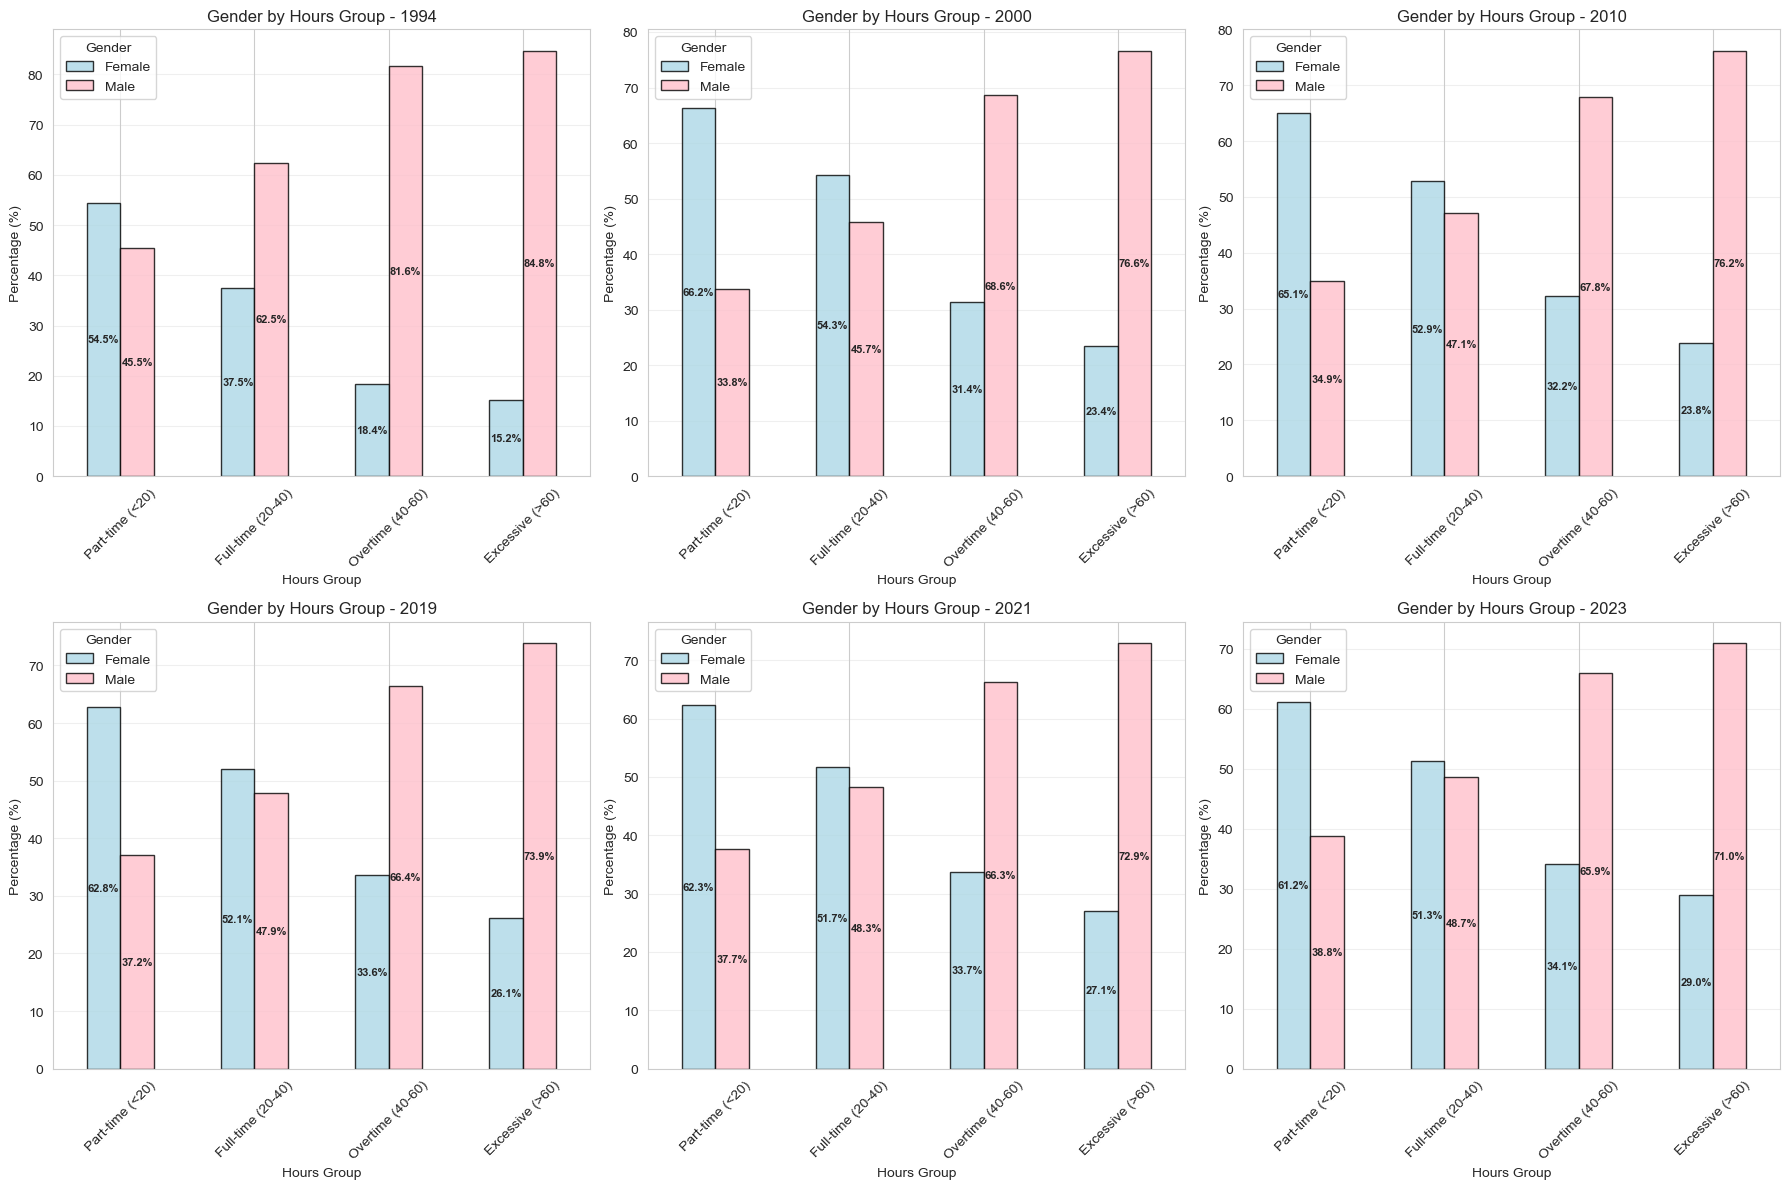

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_gender_hours_distribution(loaded_data):
    years_to_plot = [1994, 2000, 2010, 2019, 2021, 2023]

    print("Gender Distribution by Hours Group (1994-2023)")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, year in enumerate(years_to_plot):
        if year in loaded_data and 'hours_group' in loaded_data[year].columns and 'gender' in loaded_data[year].columns:
            df = loaded_data[year]

            cross_tab = pd.crosstab(df['hours_group'], df['gender'], normalize='index') * 100
            category_order = ['Part-time (<20)', 'Full-time (20-40)', 'Overtime (40-60)', 'Excessive (>60)']
            cross_tab = cross_tab.reindex(category_order)

            cross_tab.plot(
                kind='bar',
                ax=axes[i],
                color=['lightblue', 'pink'],
                edgecolor='black',
                alpha=0.8
            )

            axes[i].set_title(f'Gender by Hours Group - {year}')
            axes[i].set_xlabel('Hours Group')
            axes[i].set_ylabel('Percentage (%)')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].legend(title='Gender')
            axes[i].grid(axis='y', alpha=0.3)

            for bar_container in axes[i].containers:
                for bar in bar_container:
                    height = bar.get_height()
                    if height > 5:
                        axes[i].text(
                            bar.get_x() + bar.get_width()/2.,
                            height/2,
                            f'{height:.1f}%',
                            ha='center', va='center',
                            fontweight='bold',
                            fontsize=8
                        )

    if len(years_to_plot) < 6:
        axes[5].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_gender_hours_distribution(loaded_data)

COMPARATIVE ANALYSIS: FULL-TIME WORK BY GENDER (1994-2023)
1994: Full-time → Male:  62.5% | Female:  37.5%
2000: Full-time → Male:  45.7% | Female:  54.3%
2010: Full-time → Male:  47.1% | Female:  52.9%
2019: Full-time → Male:  47.9% | Female:  52.1%
2021: Full-time → Male:  48.3% | Female:  51.7%
2023: Full-time → Male:  48.7% | Female:  51.3%
STATISTICAL SUMMARY
Male Average: 50.0% (Min: 45.7%, Max: 62.5%)
Female Average: 50.0% (Min: 37.5%, Max: 54.3%)
Years with data: 6 years


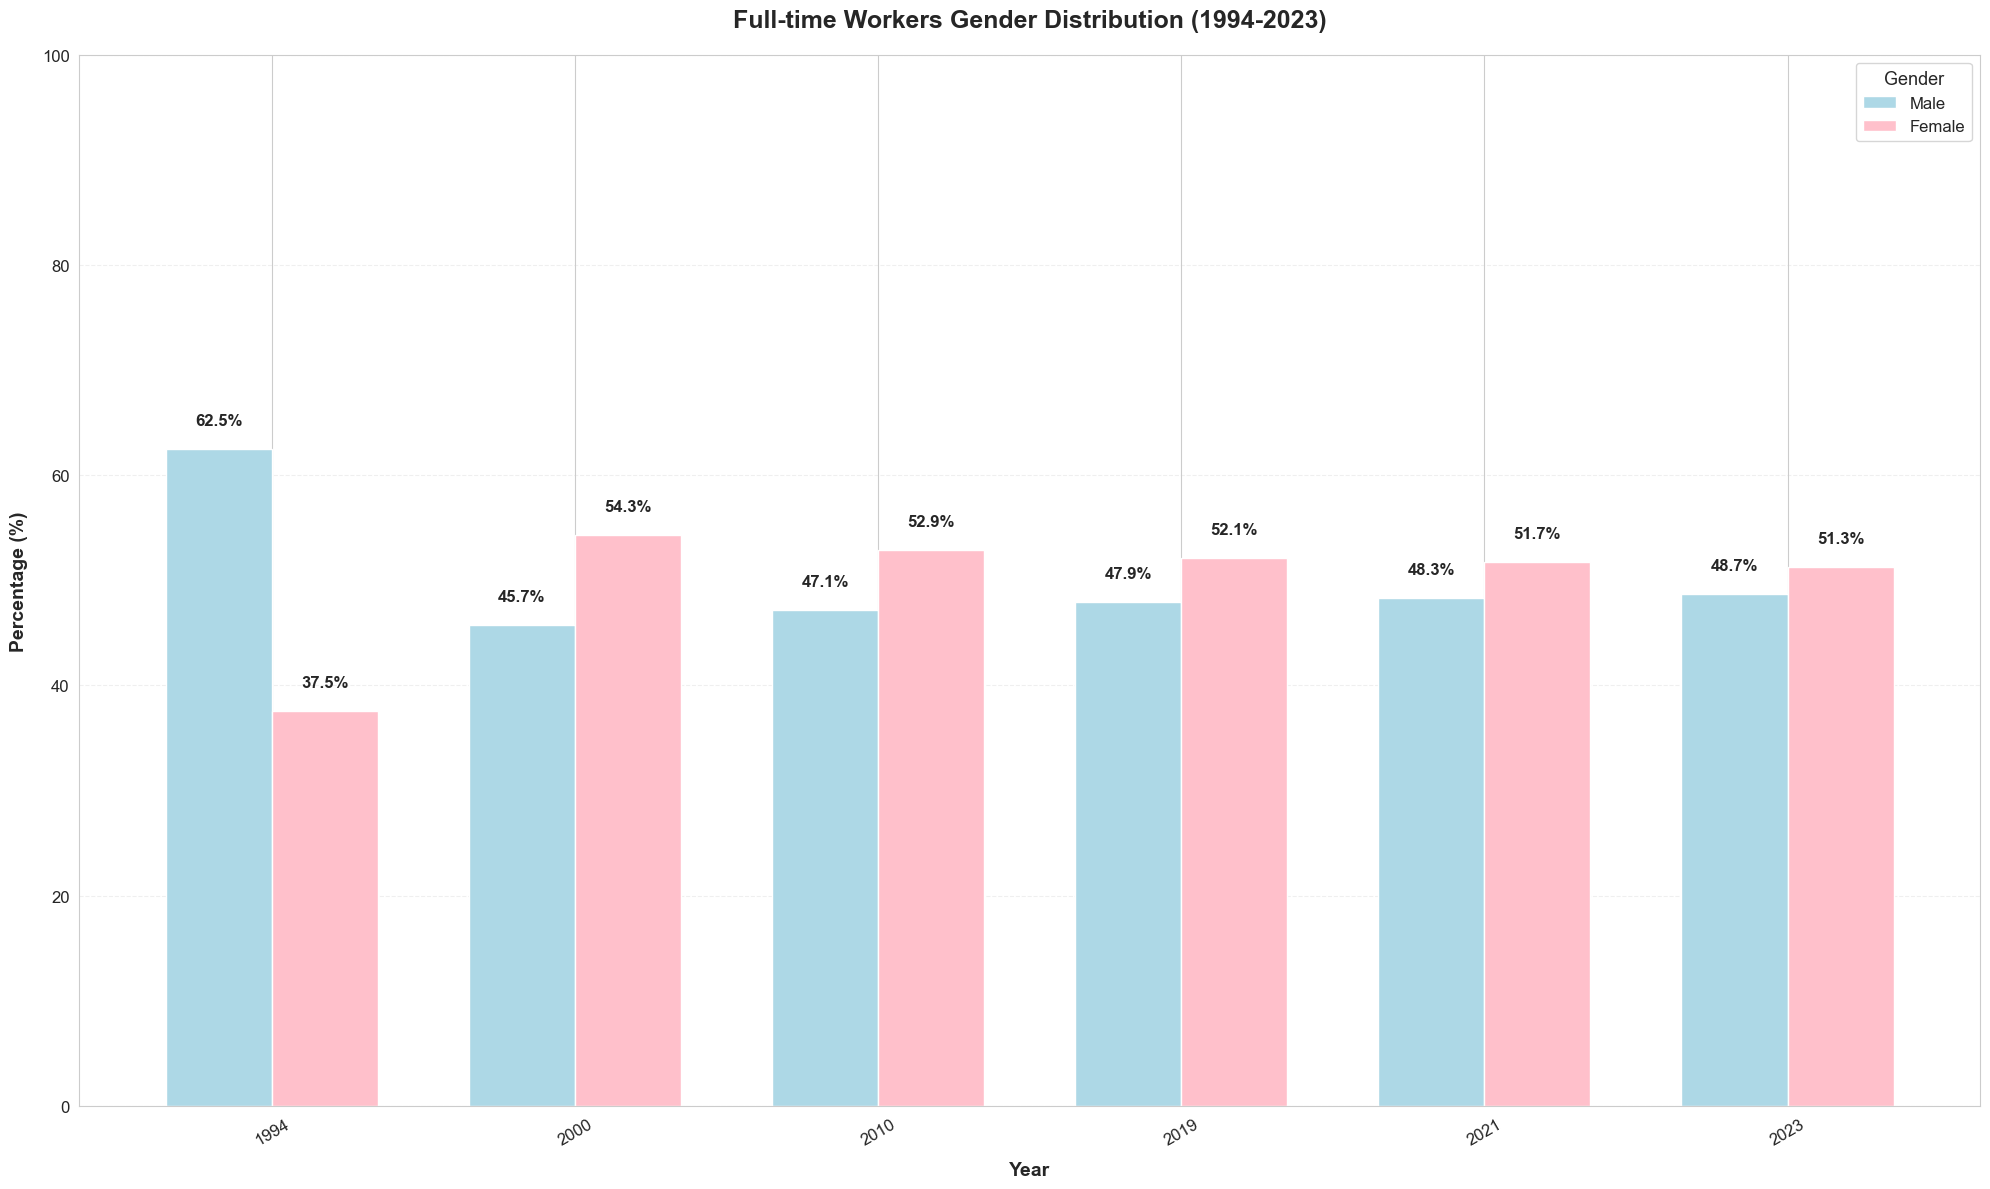

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

years_to_plot = [1994, 2000, 2010, 2019, 2021, 2023]

print("COMPARATIVE ANALYSIS: FULL-TIME WORK BY GENDER (1994-2023)")


comparison_data = []
years_comparison = []

for year in years_to_plot:
    if year in loaded_data and 'hours_group' in loaded_data[year].columns and 'gender' in loaded_data[year].columns:
        df = loaded_data[year]
        full_time_data = df[df['hours_group'] == 'Full-time (20-40)']
        
        if len(full_time_data) > 0:
            full_time_gender = full_time_data['gender'].value_counts(normalize=True) * 100
            male_pct = full_time_gender.get('Male', 0)
            female_pct = full_time_gender.get('Female', 0)
            
            comparison_data.append({'Male': male_pct, 'Female': female_pct})
            years_comparison.append(year)
            
            print(f"{year}: Full-time → Male: {male_pct:5.1f}% | Female: {female_pct:5.1f}%")

# Statistical summary
if comparison_data:
    
    print("STATISTICAL SUMMARY")
    
    
    male_values = [data['Male'] for data in comparison_data]
    female_values = [data['Female'] for data in comparison_data]
    
    print(f"Male Average: {np.mean(male_values):.1f}% (Min: {np.min(male_values):.1f}%, Max: {np.max(male_values):.1f}%)")
    print(f"Female Average: {np.mean(female_values):.1f}% (Min: {np.min(female_values):.1f}%, Max: {np.max(female_values):.1f}%)")
    print(f"Years with data: {len(years_comparison)} years")
    

    plt.figure(figsize=(20, 12))
    comparison_df = pd.DataFrame(comparison_data, index=years_comparison).sort_index()

    
    bar_width = 0.35
    x = np.arange(len(comparison_df))

    plt.bar(x - bar_width/2, comparison_df['Male'], width=bar_width, color='lightblue', label='Male')
    plt.bar(x + bar_width/2, comparison_df['Female'], width=bar_width, color='pink', label='Female')

   
    plt.title('Full-time Workers Gender Distribution (1994-2023)', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=14, fontweight='bold', labelpad=10)
    plt.ylabel('Percentage (%)', fontsize=14, fontweight='bold', labelpad=10)
    plt.xticks(x, comparison_df.index, rotation=30, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title='Gender', title_fontsize=13, fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    
    for i, year in enumerate(comparison_df.index):
        plt.text(i - bar_width/2, comparison_df['Male'][year] + 2, f'{comparison_df["Male"][year]:.1f}%', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
        plt.text(i + bar_width/2, comparison_df['Female'][year] + 2, f'{comparison_df["Female"][year]:.1f}%', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("No data available for analysis.")

COMPARATIVE ANALYSIS: FULL-TIME WORK BY GENDER (1994-2023)
TREND ANALYSIS:
1994: Increase Male Dominant | Male:  62.5% | Female:  37.5%
2000: Decrease Female Dominant | Male:  45.7% | Female:  54.3%
2010: Decrease Female Dominant | Male:  47.1% | Female:  52.9%
2019: Decrease Female Dominant | Male:  47.9% | Female:  52.1%
2021: Decrease Female Dominant | Male:  48.3% | Female:  51.7%
2023: Decrease Female Dominant | Male:  48.7% | Female:  51.3%
KEY INSIGHTS
Major Shift: Male dominance in 1994 (62.5%) to Female dominance from 2000 onward
Stability Period: 2010-2023 range: Male 47.1%-48.7%
Change Over 29 Years: Male -13.8% | Female +13.8%


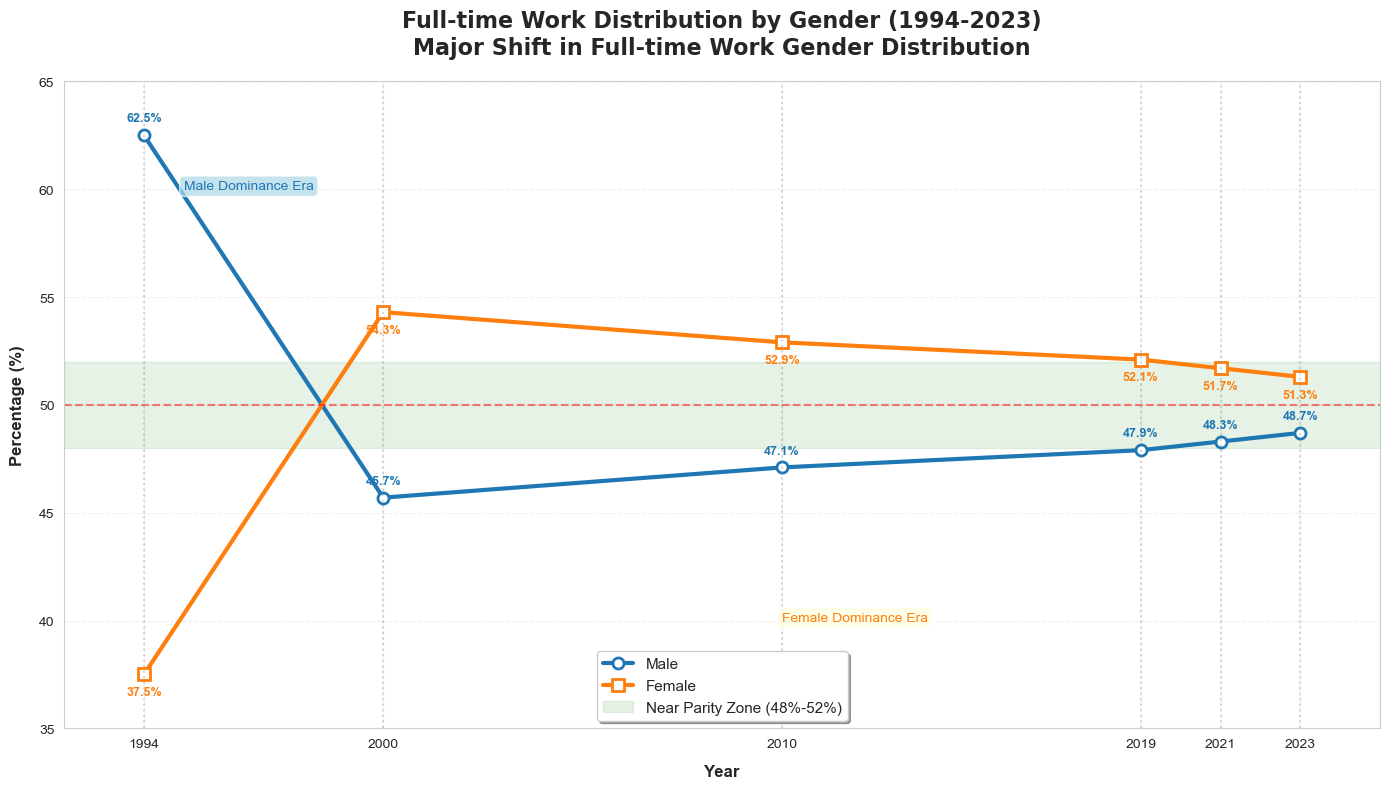

SUMMARY
1994: Male dominance (62.5%)
2000: Major shift to Female dominance
2010-2023: Stable Female dominance with slight Male recovery
Overall: Significant gender distribution transformation


In [80]:
print("COMPARATIVE ANALYSIS: FULL-TIME WORK BY GENDER (1994-2023)")

# Data from your output
years = [1994, 2000, 2010, 2019, 2021, 2023]
male_percentages = [62.5, 45.7, 47.1, 47.9, 48.3, 48.7]
female_percentages = [37.5, 54.3, 52.9, 52.1, 51.7, 51.3]

print("TREND ANALYSIS:")
for i, year in enumerate(years):
    trend = "Decrease" if male_percentages[i] < female_percentages[i] else "Increase" if male_percentages[i] > female_percentages[i] else "Stable"
    dominant = "Female Dominant" if female_percentages[i] > male_percentages[i] else "Male Dominant"
    
    print(f"{year}: {trend} {dominant} | Male: {male_percentages[i]:5.1f}% | Female: {female_percentages[i]:5.1f}%")


print("KEY INSIGHTS")


# Calculate changes
male_change = male_percentages[-1] - male_percentages[0]
female_change = female_percentages[-1] - female_percentages[0]

print(f"Major Shift: Male dominance in 1994 ({male_percentages[0]}%) to Female dominance from 2000 onward")
print(f"Stability Period: 2010-2023 range: Male {min(male_percentages[2:]):.1f}%-{max(male_percentages[2:]):.1f}%")
print(f"Change Over 29 Years: Male {male_change:+.1f}% | Female {female_change:+.1f}%")


plt.figure(figsize=(14, 8))


plt.plot(years, male_percentages, marker='o', linewidth=3,
         label='Male', color='#1f77b4', markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.plot(years, female_percentages, marker='s', linewidth=3,
         label='Female', color='#ff7f0e', markersize=8, markerfacecolor='white', markeredgewidth=2)


for i, (year, male, female) in enumerate(zip(years, male_percentages, female_percentages)):
    # Add percentages on the lines
    plt.annotate(f'{male}%', (year, male),
                textcoords="offset points", xytext=(0,10),
                ha='center', fontsize=9, fontweight='bold', color='#1f77b4')
    plt.annotate(f'{female}%', (year, female),
                textcoords="offset points", xytext=(0,-15),
                ha='center', fontsize=9, fontweight='bold', color='#ff7f0e')
    
    
    plt.axvline(x=year, color='gray', linestyle=':', alpha=0.3)


plt.title('Full-time Work Distribution by Gender (1994-2023)\nMajor Shift in Full-time Work Gender Distribution',
          fontsize=16, fontweight='bold', pad=20, fontfamily='DejaVu Sans')

plt.xlabel('Year', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(years, fontsize=10)
plt.yticks(fontsize=10)


plt.axhspan(48, 52, alpha=0.1, color='green', label='Near Parity Zone (48%-52%)')


plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')


plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Perfect Parity (50%)')


plt.ylim(35, 65)
plt.xlim(1992, 2025)


plt.text(1995, 60, 'Male Dominance Era', fontsize=10, color='#1f77b4',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
plt.text(2010, 40, 'Female Dominance Era', fontsize=10, color='#ff7f0e',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()


print("SUMMARY")

print("1994: Male dominance (62.5%)")
print("2000: Major shift to Female dominance")
print("2010-2023: Stable Female dominance with slight Male recovery")
print("Overall: Significant gender distribution transformation")

In [81]:
def inspect_marital_status_columns(loaded_data):

    print("Inspecting marital status column variables")
    
    
    for year in [1994, 2000, 2010, 2019, 2021 , 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\nYear {year}:")
            
            
            marital_cols = [col for col in df.columns if 'marital' in col.lower() or 'marst' in col.lower()]
            
            if marital_cols:
                for col in marital_cols:
                    print(f"Column: {col}")
                    print(f"Data type: {df[col].dtype}")
                    print(f"Number of unique values: {df[col].nunique()}")
                    print(f"Unique values: {df[col].unique()}")
                    print(f"Value distribution:")
                    value_counts = df[col].value_counts().head(10)  # Top 10 values only
                    for value, count in value_counts.items():
                        percentage = (count / len(df)) * 100
                        print(f"        {value}: {count:,} ({percentage:.1f}%)")
                    print(f"      Missing values: {df[col].isna().sum()}")
            else:
                print(f"No marital status columns found")
            
            print(f"Total columns: {len(df.columns)}")


inspect_marital_status_columns(loaded_data)

Inspecting marital status column variables

Year 1994:
Column: marital_status
Data type: object
Number of unique values: 7
Unique values: ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
Value distribution:
        Married-civ-spouse: 14,333 (46.7%)
        Never-married: 9,896 (32.2%)
        Divorced: 4,256 (13.9%)
        Separated: 959 (3.1%)
        Widowed: 840 (2.7%)
        Married-spouse-absent: 389 (1.3%)
        Married-AF-spouse: 21 (0.1%)
      Missing values: 0
Column: marital_group
Data type: object
Number of unique values: 4
Unique values: ['Widowed' 'Divorced' 'Single' 'Married']
Value distribution:
        Married: 14,743 (48.0%)
        Single: 9,896 (32.2%)
        Divorced: 5,215 (17.0%)
        Widowed: 840 (2.7%)
      Missing values: 0
Total columns: 26

Year 2000:
Column: MARST
Data type: int64
Number of unique values: 6
Unique values: [5 6 1 4 3 2]
Value distribution:
        1: 118,239 (58.4%

In [82]:
def unify_marital_status_all_years(loaded_data):
    print("Unifying marital status for all years (1994-2023)")
    
    
#Conversion map from IPUMS coding to 1994 classification
    ipums_to_1994_map = {
        1: 'Married-civ-spouse',
        2: 'Married-spouse-absent',  
        3: 'Separated',
        4: 'Divorced',
        5: 'Widowed',
        6: 'Never-married'
    }
    
#Grouping map (same as 1994)
    marital_group_map = {
        'Never-married': 'Single',
        'Married-civ-spouse': 'Married',
        'Married-spouse-absent': 'Married',
        'Married-AF-spouse': 'Married',
        'Divorced': 'Divorced', 
        'Separated': 'Divorced',
        'Widowed': 'Widowed'
    }
    
    for year, df in loaded_data.items():
        print(f"Year {year}")
        
        if year == 1994:
            print("Already unified - keeping as reference")
            continue
            
#convert MARST to marital_status
        if 'MARST' in df.columns:
            print("   Converting MARST to marital_status...")
            
            
            df['marital_status'] = df['MARST'].map(ipums_to_1994_map)
            
            
            df['marital_group'] = df['marital_status'].map(marital_group_map)
            
            print(f"Created marital_status (1994 format)")
            print(f"Created marital_group")
            
            
            status_dist = df['marital_status'].value_counts().to_dict()
            group_dist = df['marital_group'].value_counts().to_dict()
            print(f"   Status distribution: {status_dist}")
            print(f"   Group distribution: {group_dist}")
            
        else:
            print(f"   No MARST column found")
    
    return loaded_data


loaded_data = unify_marital_status_all_years(loaded_data)

print("Final Marital Status Unification Check")


for year in [1994, 2000, 2010, 2019, 2021 , 2023]:
    if year in loaded_data:
        df = loaded_data[year]
        marital_cols = [col for col in df.columns if 'marital' in col.lower()]
        print(f"{year}: {marital_cols}")
        
        if 'marital_status' in df.columns:
            unique_vals = df['marital_status'].unique()
            print(f"   Unique statuses: {sorted(unique_vals)}")

Unifying marital status for all years (1994-2023)
Year 1994
Already unified - keeping as reference
Year 2000
   Converting MARST to marital_status...
Created marital_status (1994 format)
Created marital_group
   Status distribution: {'Married-civ-spouse': 118239, 'Never-married': 48766, 'Divorced': 22988, 'Widowed': 5087, 'Separated': 4314, 'Married-spouse-absent': 3177}
   Group distribution: {'Married': 121416, 'Single': 48766, 'Divorced': 27302, 'Widowed': 5087}
Year 2010
   Converting MARST to marital_status...
Created marital_status (1994 format)
Created marital_group
   Status distribution: {'Married-civ-spouse': 4421857, 'Never-married': 2010653, 'Divorced': 867455, 'Widowed': 169496, 'Separated': 157048, 'Married-spouse-absent': 156936}
   Group distribution: {'Married': 4578793, 'Single': 2010653, 'Divorced': 1024503, 'Widowed': 169496}
Year 2019
   Converting MARST to marital_status...
Created marital_status (1994 format)
Created marital_group
   Status distribution: {'Marrie

In [83]:
def unify_workclass_all_years(loaded_data):
    print("Unifying workclass for all years (1994-2023)")
    
# Conversion map from CLASSWKRD to 1994 classification
    classwkrd_to_1994_map = {
        13: 'Self-Employed (Sole)',
        14: 'Self-Employed (Business)',
        25: 'Federal Government',
        27: 'State Government',  
        28: 'Local Government',
        22: 'Private',
        23: 'Private',
        29: 'Without-pay'
    }
    

    workclass_simple_map = {
        'Private': 'Private Company',
        'Self-Employed (Sole)': 'Self-Employed',
        'Self-Employed (Business)': 'Self-Employed',
        'Federal Government': 'Public Sector',
        'State Government': 'Public Sector', 
        'Local Government': 'Public Sector',
        'Without-pay': 'Non-Paid Work'
    }
    

    workclass_detailed_map = {
        'Private': 'Private Company Employee',
        'Self-Employed (Sole)': 'Self-Employed (Sole Proprietor)',
        'Self-Employed (Business)': 'Self-Employed (Business Owner)',
        'Federal Government': 'Government Employee (Federal)',
        'State Government': 'Government Employee (State)',
        'Local Government': 'Government Employee (Local)',
        'Without-pay': 'Volunteer / Unpaid'
    }
    
    for year, df in loaded_data.items():
        print(f"Year {year}")
        
        if year == 1994:
            print("Already unified - keeping as reference")
            continue
            
        
        if 'CLASSWKRD' in df.columns:
            print("   Converting CLASSWKRD to workclass...")
            
            
            df['workclass'] = df['CLASSWKRD'].map(classwkrd_to_1994_map)
            
# Add derived columns (same as 1994)
            df['workclass_simple'] = df['workclass'].map(workclass_simple_map)
            df['workclass_detailed'] = df['workclass'].map(workclass_detailed_map)
            
            print(f"Created workclass (1994 format)")
            print(f"Created workclass_simple")
            print(f"Created workclass_detailed")
            
            workclass_dist = df['workclass'].value_counts().to_dict()
            simple_dist = df['workclass_simple'].value_counts().to_dict()
            print(f"Workclass distribution: {workclass_dist}")
            print(f"Simple distribution: {simple_dist}")
            
        else:
            print(f"No CLASSWKRD column found")
    
    return loaded_data


loaded_data = unify_workclass_all_years(loaded_data)

# Final verification

print("Final Workclass Unification Check")


for year in [1994, 2000, 2010, 2019 , 2021, 2023]:
    if year in loaded_data:
        df = loaded_data[year]
        workclass_cols = [col for col in df.columns if 'workclass' in col.lower()]
        print(f"{year}: {workclass_cols}")
        
        if 'workclass' in df.columns:
            unique_vals = df['workclass'].unique()
            print(f"   Unique workclasses: {sorted(unique_vals)}")

Unifying workclass for all years (1994-2023)
Year 1994
Already unified - keeping as reference
Year 2000
   Converting CLASSWKRD to workclass...
Created workclass (1994 format)
Created workclass_simple
Created workclass_detailed
Workclass distribution: {'Private': 148403, 'Local Government': 15649, 'Self-Employed (Sole)': 14094, 'State Government': 9001, 'Self-Employed (Business)': 7313, 'Federal Government': 6949, 'Without-pay': 1162}
Simple distribution: {'Private Company': 148403, 'Public Sector': 31599, 'Self-Employed': 21407, 'Non-Paid Work': 1162}
Year 2010
   Converting CLASSWKRD to workclass...
Created workclass (1994 format)
Created workclass_simple
Created workclass_detailed
Workclass distribution: {'Private': 5643026, 'Local Government': 636828, 'Self-Employed (Sole)': 564068, 'State Government': 365981, 'Self-Employed (Business)': 294518, 'Federal Government': 258908, 'Without-pay': 20116}
Simple distribution: {'Private Company': 5643026, 'Public Sector': 1261717, 'Self-Empl

In [84]:
def inspect_all_columns(loaded_data):
    print("Inspecting all column names in each year")

    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"Year {year}:")
            print(f"Number of columns: {len(df.columns)}")
            print(f"Column names:")
            
            
            columns_list = list(df.columns)
            for i in range(0, len(columns_list), 8):
                print(f"      {columns_list[i:i+8]}")
            
            education_cols = [col for col in df.columns if 'educ' in col.lower()]
            marital_cols = [col for col in df.columns if 'marital' in col.lower()]
            workclass_cols = [col for col in df.columns if 'workclass' in col.lower()]
            
            print(f"   Education columns: {education_cols}")
            print(f"   Marital status columns: {marital_cols}")
            print(f"   Workclass columns: {workclass_cols}")


inspect_all_columns(loaded_data)

Inspecting all column names in each year
Year 1994:
Number of columns: 26
Column names:
      ['YEAR', 'age', 'workclass', 'education', 'education_years', 'marital_status', 'occupation', 'gender']
      ['capital_gain', 'capital_loss', 'hours_per_week', 'income', 'marital_group', 'occupation_sector_acs', 'workclass_simple', 'workclass_detailed']
      ['age_group_acs', 'age_group_label', 'education_level_acs', 'income_numeric', 'income_1994_value', 'income_2023_value', 'income_category', 'income_category_label']
      ['age_group', 'hours_group']
   Education columns: ['education', 'education_years', 'education_level_acs']
   Marital status columns: ['marital_status', 'marital_group']
   Workclass columns: ['workclass', 'workclass_simple', 'workclass_detailed']
Year 2000:
Number of columns: 23
Column names:
      ['YEAR', 'gender', 'age', 'MARST', 'EDUC', 'EDUCD', 'CLASSWKR', 'CLASSWKRD']
      ['OCC', 'OCCSOC', 'IND', 'hours_per_week', 'INCTOT', 'INCWAGE', 'age_group_acs', 'age_group_

In [85]:
def check_education_data_completeness(loaded_data):
    print("Verifying completeness of educational data")
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"Year {year}:")
            
            # Check core educational columns
            education_columns = {
                'EDUC': 'Educational attainment (simplified)',
                'EDUCD': 'Educational attainment (detailed)',
                'DEGFIELD': 'Degree field',
                'DEGFIELDD': 'Degree field (detailed)'
            }
            
            for col, description in education_columns.items():
                if col in df.columns:
                    total_count = len(df[col])
                    non_null_count = df[col].notna().sum()
                    null_count = df[col].isna().sum()
                    null_percentage = (null_count / total_count) * 100
                    
                    unique_values = df[col].nunique()
                    
                    print(f"{col} ({description}):")
                    print(f"- Total values: {total_count:,}")
                    print(f"- Non-null values: {non_null_count:,} ({100-null_percentage:.1f}%)")
                    print(f"- Null values: {null_count:,} ({null_percentage:.1f}%)")
                    print(f"- Unique values: {unique_values}")
                    
                    if non_null_count > 0:
                        sample_values = df[col].dropna().unique()[:5]
                        print(f"- Sample values: {sample_values}")
                    
                    if null_percentage > 10:
                        print(f"Warning: High percentage of null values!")
                    
                else:
                    print(f"{col}: Column not found")
            
#Check for columns that will be created later
            future_columns = ['education', 'education_years', 'education_level_acs']
            existing_future = [col for col in future_columns if col in df.columns]
            if existing_future:
                print(f" Future columns already exist: {existing_future}")

check_education_data_completeness(loaded_data)

Verifying completeness of educational data
Year 1994:
EDUC: Column not found
EDUCD: Column not found
DEGFIELD: Column not found
DEGFIELDD: Column not found
 Future columns already exist: ['education', 'education_years', 'education_level_acs']
Year 2000:
EDUC (Educational attainment (simplified)):
- Total values: 202,571
- Non-null values: 202,571 (100.0%)
- Null values: 0 (0.0%)
- Unique values: 11
- Sample values: [ 8  6 10 11  7]
EDUCD (Educational attainment (detailed)):
- Total values: 202,571
- Non-null values: 202,571 (100.0%)
- Null values: 0 (0.0%)
- Unique values: 16
- Sample values: [ 81  62 101 114 116]
DEGFIELD: Column not found
DEGFIELDD: Column not found
Year 2010:
EDUC (Educational attainment (simplified)):
- Total values: 7,783,445
- Non-null values: 7,783,445 (100.0%)
- Null values: 0 (0.0%)
- Unique values: 11
- Sample values: [ 6  7  4 11 10]
EDUCD (Educational attainment (detailed)):
- Total values: 7,783,445
- Non-null values: 7,783,445 (100.0%)
- Null values: 0 (0

In [86]:
def unify_education_final_corrected(loaded_data):
    print("Unifying education using the official IPUMS coding")

    educ_to_years_official = {
        0: 0,
        1: 2,
        2: 6,
        3: 9,
        4: 10,
        5: 11,
        6: 12,
        7: 13,
        8: 14,
        9: 15,
        10: 16,
        11: 18
    }
    
    educ_to_text_official = {
        0: 'No schooling',
        1: 'Preschool-grade4',
        2: 'Grade5-8', 
        3: 'Grade9',
        4: 'Grade10',
        5: 'Grade11',
        6: 'Grade12',
        7: 'College1year',
        8: 'College2years',
        9: 'College3years', 
        10: 'College4years',
        11: 'College5plus'
    }
    
# Official IPUMS EDUC coding to 1994-compatible labels
    educ_to_1994_compatible = {
        0: 'No schooling',
        1: 'Preschool',
        2: '5th-6th',
        3: '9th',
        4: '10th',
        5: '11th',
        6: 'HS-grad',
        7: 'Some-college',
        8: 'Assoc-acdm',  
        9: 'Some-college',
        10: 'Bachelors',
        11: 'Masters'
    }
    
# Adjusted ACS classification based on official coding
    def education_level_acs_official(years):
        if years <= 8:
            return 'Less than high school'
        elif years <= 12:
            return 'High school graduate'
        elif years <= 14:
            return 'Some college or Associate'
        elif years <= 16:
            return 'Bachelor\'s degree'
        else:
            return 'Graduate or professional degree'
    
    years_to_process = [2000, 2010, 2019, 2021, 2023]
    
    for year in years_to_process:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"Year {year}:")
            
            if 'EDUC' in df.columns:
#Conversion using official coding
                df['education_years'] = df['EDUC'].map(educ_to_years_official)
                df['education'] = df['EDUC'].map(educ_to_1994_compatible)
                df['education_level_acs'] = df['education_years'].apply(education_level_acs_official)
                
                print(f"Core columns created (official coding)")
                
#Check distribution
                educ_distribution = df['EDUC'].value_counts().sort_index()
                print(f"EDUC value distribution:")
                for educ_code, count in educ_distribution.items():
                    label = educ_to_text_official.get(educ_code, 'Unknown')
                    percentage = (count / len(df)) * 100
                    print(f"      {educ_code} ({label}): {count:,} ({percentage:.1f}%)")
                
#Check education levels
                level_dist = df['education_level_acs'].value_counts().head(3)
                print(f"Top levels: {level_dist.to_dict()}")
            
            if 'EDUCD' in df.columns:
                df['education_detailed_code'] = df['EDUCD']
                print(f"EDUCD saved ({df['EDUCD'].nunique()} unique values)")
            
            if 'DEGFIELD' in df.columns:
                df['degree_field_code'] = df['DEGFIELD']
                print(f"DEGFIELD saved ({df['DEGFIELD'].nunique()} fields)")
            
            if 'DEGFIELDD' in df.columns:
                df['degree_field_detailed_code'] = df['DEGFIELDD']
                print(f"DEGFIELDD saved ({df['DEGFIELDD'].nunique()} detailed fields)")
            
            print()
    
    return loaded_data

print("Starting education unification with official coding...")
loaded_data = unify_education_final_corrected(loaded_data)

print("Final verification - Unified education (official coding)")

for year in [1994, 2000, 2010, 2019, 2021, 2023]:
    if year in loaded_data:
        df = loaded_data[year]
        education_cols = [col for col in df.columns if 'education' in col.lower()]
        degree_cols = [col for col in df.columns if 'degree' in col.lower()]
        
        print(f" {year}:")
        print(f"Education: {[col for col in education_cols if 'detailed' not in col]}")
        if degree_cols:
            print(f"Degree fields: {degree_cols}")
        
        if 'education_level_acs' in df.columns:
            top_level = df['education_level_acs'].value_counts().index[0]
            print(f"Most common level: {top_level}")

Starting education unification with official coding...
Unifying education using the official IPUMS coding
Year 2000:
Core columns created (official coding)
EDUC value distribution:
      0 (No schooling): 850 (0.4%)
      1 (Preschool-grade4): 783 (0.4%)
      2 (Grade5-8): 4,577 (2.3%)
      3 (Grade9): 2,777 (1.4%)
      4 (Grade10): 3,967 (2.0%)
      5 (Grade11): 5,259 (2.6%)
      6 (Grade12): 77,824 (38.4%)
      7 (College1year): 33,044 (16.3%)
      8 (College2years): 15,001 (7.4%)
      10 (College4years): 37,579 (18.6%)
      11 (College5plus): 20,910 (10.3%)
Top levels: {'High school graduate': 89827, 'Some college or Associate': 48045, "Bachelor's degree": 37579}
EDUCD saved (16 unique values)

Year 2010:
Core columns created (official coding)
EDUC value distribution:
      0 (No schooling): 44,432 (0.6%)
      1 (Preschool-grade4): 31,654 (0.4%)
      2 (Grade5-8): 160,707 (2.1%)
      3 (Grade9): 91,968 (1.2%)
      4 (Grade10): 119,530 (1.5%)
      5 (Grade11): 170,185 (

In [87]:
def decode_degfield_with_real_dictionary(loaded_data):
    print("Decoding DEGFIELD using the real dictionary")
    
# Main DEGFIELD dictionary (from documentation)
    degfield_main_dict = {
        0: "N/A",
        11: "Agriculture",
        13: "Environment and Natural Resources",
        14: "Architecture",
        15: "Area, Ethnic, and Civilization Studies",
        19: "Communications",
        20: "Communication Technologies",
        21: "Computer and Information Sciences",
        22: "Cosmetology Services and Culinary Arts",
        23: "Education Administration and Teaching",
        24: "Engineering",
        25: "Engineering Technologies",
        26: "Linguistics and Foreign Languages",
        29: "Family and Consumer Sciences",
        32: "Law",
        33: "English Language, Literature, and Composition",
        34: "Liberal Arts and Humanities",
        35: "Library Science",
        36: "Biology and Life Sciences",
        37: "Mathematics and Statistics",
        38: "Military Technologies",
        40: "Interdisciplinary and Multi-Disciplinary Studies (General)",
        41: "Physical Fitness, Parks, Recreation, and Leisure",
        48: "Philosophy and Religious Studies",
        49: "Theology and Religious Vocations",
        50: "Physical Sciences",
        51: "Nuclear, Industrial Radiology, and Biological Technologies",
        52: "Psychology",
        53: "Criminal Justice and Fire Protection",
        54: "Public Affairs, Policy, and Social Work",
        55: "Social Sciences",
        56: "Construction Services",
        57: "Electrical and Mechanic Repairs and Technologies",
        58: "Precision Production and Industrial Arts",
        59: "Transportation Sciences and Technologies",
        60: "Fine Arts",
        61: "Medical and Health Sciences and Services",
        62: "Business",
        64: "History"
    }
    
# Detailed DEGFIELDD dictionary (important samples)
    degfield_detailed_dict = {
        1900: "Communications",
        1901: "Communications",
        1902: "Journalism",
        1903: "Mass Media",
        1904: "Advertising and Public Relations",
        2100: "Computer and Information Systems",
        2101: "Computer Programming and Data Processing",
        2102: "Computer Science",
        2105: "Information Sciences",
        2300: "General Education",
        2301: "Educational Administration and Supervision",
        2304: "Elementary Education",
        2308: "Science and Computer Teacher Education",
        2400: "General Engineering",
        2401: "Aerospace Engineering",
        2402: "Biological Engineering",
        2403: "Architectural Engineering",
        2404: "Biomedical Engineering",
        2405: "Chemical Engineering",
        2406: "Civil Engineering",
        2408: "Electrical Engineering",
        2414: "Mechanical Engineering",
        3300: "English Language, Literature, and Composition",
        3600: "Biology",
        3700: "Mathematics",
        3701: "Applied Mathematics",
        3702: "Statistics and Decision Science",
        4009: "Data Science and Data Analytics",
        5003: "Chemistry",
        5007: "Physics",
        5200: "Psychology",
        5400: "Public Affairs, Policy, and Social Work",
        5401: "Public Administration",
        5404: "Social Work",
        5500: "General Social Sciences",
        5501: "Economics",
        5506: "Political Science and Government",
        5507: "Sociology",
        6100: "General Medical and Health Services",
        6107: "Nursing",
        6108: "Pharmacy, Pharmaceutical Sciences, and Administration",
        6200: "General Business",
        6201: "Accounting",
        6203: "Business Management and Administration",
        6206: "Marketing and Marketing Research",
        6207: "Finance",
        6402: "History"
    }
    
    print(f"Main DEGFIELD dictionary: {len(degfield_main_dict)} majors")
    print(f"Detailed DEGFIELDD dictionary: {len(degfield_detailed_dict)} detailed majors")
    
    # Apply to years
    for year in [2019, 2021, 2023]:
        if 'degree_field_code' in loaded_data[year].columns:
            df = loaded_data[year].copy()
            
            print(f"\n{year}:")
            
#Decode DEGFIELD (main)
            df['MAJOR_MAIN'] = df['degree_field_code'].map(degfield_main_dict)
            
#Decode DEGFIELDD (detailed) if available
            if 'degree_field_detailed_code' in df.columns:
                df['MAJOR_DETAILED'] = df['degree_field_detailed_code'].map(degfield_detailed_dict)
            
# Statistics
            decoded_main = df['MAJOR_MAIN'].notna().sum()
            total = len(df)
            
            print(f"   Decoded DEGFIELD: {decoded_main:,}/{total:,} ({decoded_main/total*100:.1f}%)")
            
            if 'MAJOR_DETAILED' in df.columns:
                decoded_detailed = df['MAJOR_DETAILED'].notna().sum()
                print(f"   Decoded DEGFIELDD: {decoded_detailed:,}/{total:,} ({decoded_detailed/total*100:.1f}%)")
            
# Show top 5 majors
            print(f"\n   Top 5 main majors:")
            top_majors = df['MAJOR_MAIN'].value_counts().head(5)
            for major, count in top_majors.items():
                pct = (count / total) * 100
                print(f"      - {major}: {pct:.1f}%")
            
            loaded_data[year] = df
    
    return loaded_data, degfield_main_dict, degfield_detailed_dict
print("Starting decoding using the real dictionary")
loaded_data, main_dict, detailed_dict = decode_degfield_with_real_dictionary(loaded_data)

Starting decoding using the real dictionary
Decoding DEGFIELD using the real dictionary
Main DEGFIELD dictionary: 39 majors
Detailed DEGFIELDD dictionary: 47 detailed majors

2019:
   Decoded DEGFIELD: 8,104,495/8,104,495 (100.0%)
   Decoded DEGFIELDD: 1,840,425/8,104,495 (22.7%)

   Top 5 main majors:
      - N/A: 64.4%
      - Business: 7.3%
      - Education Administration and Teaching: 3.7%
      - Engineering: 2.9%
      - Medical and Health Sciences and Services: 2.7%

2021:
   Decoded DEGFIELD: 7,871,427/7,871,427 (100.0%)
   Decoded DEGFIELDD: 1,856,593/7,871,427 (23.6%)

   Top 5 main majors:
      - N/A: 62.9%
      - Business: 7.5%
      - Education Administration and Teaching: 3.7%
      - Engineering: 3.0%
      - Medical and Health Sciences and Services: 2.9%

2023:
   Decoded DEGFIELD: 1,725,849/1,725,849 (100.0%)
   Decoded DEGFIELDD: 432,734/1,725,849 (25.1%)

   Top 5 main majors:
      - N/A: 60.5%
      - Business: 8.0%
      - Education Administration and Teaching:

In [89]:
def inspect_occupation_unified_corrected(loaded_data):
    print("Unified inspection of occupation data (1994-2023)")

    summary_data = []
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            year_summary = {
                'year': year,
                'total_records': len(df),
                'data_type': None,
                'unique_codes': 0,
                'missing_values': 0,
                'missing_percentage': 0,
                'top_occupations': []
            }
            
            print(f"Year {year}:")
            print(f"   Total records: {len(df):,}")
            
            occupation_data = None
            data_source = ""
            
            if year == 1994:
                if 'occupation' in df.columns:
                    occupation_data = df['occupation']
                    data_source = "Text (occupation)"
                    year_summary['data_type'] = 'text'
                else:
                    print(f"    Occupation column not found in 1994")
            else:

                if 'OCCSOC' in df.columns:
                    occupation_data = df['OCCSOC']
                    data_source = "SOC (OCCSOC)"
                    year_summary['data_type'] = 'soc'
                elif 'OCC' in df.columns:
                    occupation_data = df['OCC']
                    data_source = "Numeric (OCC)" 
                    year_summary['data_type'] = 'occ'
                else:
                    print(f"     No OCC or OCCSOC columns found")
            
            if occupation_data is not None:
                year_summary['unique_codes'] = occupation_data.nunique()
                year_summary['missing_values'] = occupation_data.isna().sum()
                year_summary['missing_percentage'] = (occupation_data.isna().sum() / len(df)) * 100
                
                print(f"    Data type: {data_source}")
                print(f"    Unique codes/occupations: {occupation_data.nunique():,}")
                print(f"    Missing values: {occupation_data.isna().sum():,} ({year_summary['missing_percentage']:.1f}%)")
                
                if year == 1994:
                    print(f"    Number of distinct text occupations: {occupation_data.nunique()}")
                
                # For 2000-2023: show numeric range
                elif year >= 2000 and hasattr(occupation_data, 'min') and hasattr(occupation_data, 'max'):
                    print(f"    Numeric range: {occupation_data.min()} to {occupation_data.max()}")
                
                top_5 = occupation_data.value_counts().head(5)
                print(f"    Top 5 occupations:")
                
                for i, (code, count) in enumerate(top_5.items(), 1):
                    percentage = (count / len(df)) * 100
                    print(f"      {i}. {code}: {count:,} ({percentage:.1f}%)")
                    year_summary['top_occupations'].append({
                        'rank': i,
                        'code': code,
                        'count': count, 
                        'percentage': percentage
                    })

                if year == 1994 and occupation_data.dtype == 'object':
                    sample_occupations = occupation_data.unique()[:8]
                    print(f"    Sample of text occupations: {list(sample_occupations)}")
                
                # For 2000-2023: show sample of codes
                elif year >= 2000 and occupation_data.dtype == 'object':
                    sample_codes = occupation_data.dropna().unique()[:5]
                    print(f"    Sample of codes: {list(sample_codes)}")
            
            else:
                print(f"    No occupation data available")
                year_summary['data_type'] = 'none'
            
            summary_data.append(year_summary)

    print(f"\n Comparative summary of occupation data (1994-2023)")

    print(f"{'Year':<8} {'Records':<12} {'Data Type':<15} {'Unique Codes':<12} {'Missing (%)':<12} {'Top Occupation':<25}")
    
    for summary in summary_data:
        year = summary['year']
        records = f"{summary['total_records']:,}"
        data_type = summary['data_type']
        
        if data_type == 'text':
            data_type_str = "Text"
        elif data_type == 'soc':
            data_type_str = "SOC"
        elif data_type == 'occ':
            data_type_str = "Numeric"
        else:
            data_type_str = "None"
        
        unique_codes = f"{summary['unique_codes']:,}" if summary['unique_codes'] > 0 else "N/A"
        missing_pct = f"{summary['missing_percentage']:.1f}%" if summary['missing_percentage'] >= 0 else "N/A"

        top_occupation = ""
        if summary['top_occupations']:
            top = summary['top_occupations'][0]
            # Shorten text if too long
            code_str = str(top['code'])
            if len(code_str) > 20:
                code_str = code_str[:17] + "..."
            top_occupation = f"{code_str} ({top['percentage']:.1f}%)"
        
        print(f"{year:<8} {records:<12} {data_type_str:<15} {unique_codes:<12} {missing_pct:<12} {top_occupation:<25}")

inspect_occupation_unified_corrected(loaded_data)

Unified inspection of occupation data (1994-2023)
Year 1994:
   Total records: 30,694
    Data type: Text (occupation)
    Unique codes/occupations: 14
    Missing values: 0 (0.0%)
    Number of distinct text occupations: 14
    Top 5 occupations:
      1. Prof-specialty: 4,136 (13.5%)
      2. Craft-repair: 4,094 (13.3%)
      3. Exec-managerial: 4,065 (13.2%)
      4. Adm-clerical: 3,768 (12.3%)
      5. Sales: 3,650 (11.9%)
    Sample of text occupations: ['Exec-managerial', 'Machine-op-inspct', 'Prof-specialty', 'Other-service', 'Adm-clerical', 'Craft-repair', 'Transport-moving', 'Handlers-cleaners']
Year 2000:
   Total records: 202,571
    Data type: SOC (OCCSOC)
    Unique codes/occupations: 477
    Missing values: 0 (0.0%)
    Numeric range:      0 to 553000
    Top 5 occupations:
      1. 436010: 7,033 (3.5%)
      2. 252020: 5,097 (2.5%)
      3. 412031: 5,071 (2.5%)
      4. 533030: 4,541 (2.2%)
      5. 411011: 4,246 (2.1%)
    Sample of codes: ['291111', '493031', '514041',

In [90]:
def create_1994_occupation_mapping():
    
    occupation_mapping = {
        'Prof-specialty': '150000',   # Professional specialty
        'Craft-repair': '490000',     # Craft and repair
        'Exec-managerial': '110000',  # Executive/managerial
        'Adm-clerical': '430000',     # Administrative/clerical
        'Sales': '410000',            # Sales
        'Other-service': '370000',    # Other services
        'Machine-op-inspct': '510000', # Machine operation and inspection
        'Transport-moving': '530000',  # Transportation and moving
        'Handlers-cleaners': '470000', # Handling and cleaning
        'Farming-fishing': '450000',   # Farming and fishing
        'Tech-support': '170000',      # Technical support
        'Protective-serv': '330000',   # Protective services
        'Priv-house-serv': '390000',   # Private household services
        'Armed-Forces': '550000'       # Armed forces
    }
    return occupation_mapping

def convert_1994_to_soc(loaded_data):
    
    if 1994 in loaded_data:
        df_1994 = loaded_data[1994].copy()
        mapping = create_1994_occupation_mapping()
        
        # Create OCCSOC column for 1994
        df_1994['OCCSOC'] = df_1994['occupation'].map(mapping)
        
        # Update loaded data
        loaded_data[1994] = df_1994
        
        print("1994 data converted to SOC system")
        print(f"   - Number of records converted: {len(df_1994)}")
        print(f"   - New unique values: {df_1994['OCCSOC'].nunique()}")
        
# Show sample of conversion
        sample_conversion = df_1994[['occupation', 'OCCSOC']].head(5)
        print(f"   - Sample of conversion:")
        for _, row in sample_conversion.iterrows():
            print(f"      {row['occupation']} → {row['OCCSOC']}")
    
    return loaded_data

In [91]:
def compare_occ_vs_occsoc_unified(loaded_data):
    
    print(" Comprehensive comparison between OCC and OCCSOC (1994-2023)")
    
 # Convert 1994 data
    loaded_data = convert_1994_to_soc(loaded_data)
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"Year {year}:")
            print(f"   Total records: {len(df):,}")
            
# Check available columns
            has_occ = 'OCC' in df.columns
            has_occsoc = 'OCCSOC' in df.columns
            
            if year == 1994:
                print(f"1994 data (after conversion):")
                if has_occsoc:
                    print(f"   - Unique OCCSOC codes: {df['OCCSOC'].nunique():,}")
                    print(f"   - OCCSOC range: {df['OCCSOC'].min()} to {df['OCCSOC'].max()}")
                    
# Show distribution of converted occupations
                    top_5_converted = df['OCCSOC'].value_counts().head(5)
                    print(f"   - Top 5 occupations after conversion:")
                    for code, count in top_5_converted.items():
                        pct = (count / len(df)) * 100
                        print(f"      {code}: {count:,} ({pct:.1f}%)")
            
            elif has_occ and has_occsoc:
                print(f"OCC vs OCCSOC comparison:")
                print(f"   - Unique OCC codes: {df['OCC'].nunique():,}")
                print(f"   - Unique OCCSOC codes: {df['OCCSOC'].nunique():,}")
                
# Analyze relationship between OCC and OCCSOC
                cross_tab = df.groupby(['OCC', 'OCCSOC']).size().reset_index(name='count')
                unique_combinations = len(cross_tab)
                
                print(f"   - Unique OCC-OCCSOC combinations: {unique_combinations:,}")
                
# Relationship analysis
                occ_per_occsoc = cross_tab.groupby('OCCSOC')['OCC'].nunique()
                occsoc_per_occ = cross_tab.groupby('OCC')['OCCSOC'].nunique()
                
                print(f"   - Average OCC codes per OCCSOC: {occ_per_occsoc.mean():.2f}")
                print(f"   - Average OCCSOC codes per OCC: {occsoc_per_occ.mean():.2f}")
# One-to-one matches
                one_to_one_occ = (occsoc_per_occ == 1).sum()
                one_to_one_occsoc = (occ_per_occsoc == 1).sum()
                
                print(f"   - OCC codes with 1:1 match: {one_to_one_occ:,}/{len(occsoc_per_occ):,}")
                print(f"   - OCCSOC codes with 1:1 match: {one_to_one_occsoc:,}/{len(occ_per_occsoc):,}")
                
            else:
                print(f" Required columns not available")
                if not has_occ:
                    print(f"   - OCC not available")
                if not has_occsoc:
                    print(f"   - OCCSOC not available")
compare_occ_vs_occsoc_unified(loaded_data)

 Comprehensive comparison between OCC and OCCSOC (1994-2023)
1994 data converted to SOC system
   - Number of records converted: 30694
   - New unique values: 14
   - Sample of conversion:
      Exec-managerial → 110000
      Machine-op-inspct → 510000
      Prof-specialty → 150000
      Other-service → 370000
      Adm-clerical → 430000
Year 1994:
   Total records: 30,694
1994 data (after conversion):
   - Unique OCCSOC codes: 14
   - OCCSOC range: 110000 to 550000
   - Top 5 occupations after conversion:
      150000: 4,136 (13.5%)
      490000: 4,094 (13.3%)
      110000: 4,065 (13.2%)
      430000: 3,768 (12.3%)
      410000: 3,650 (11.9%)
Year 2000:
   Total records: 202,571
OCC vs OCCSOC comparison:
   - Unique OCC codes: 477
   - Unique OCCSOC codes: 477
   - Unique OCC-OCCSOC combinations: 477
   - Average OCC codes per OCCSOC: 1.00
   - Average OCCSOC codes per OCC: 1.00
   - OCC codes with 1:1 match: 477/477
   - OCCSOC codes with 1:1 match: 477/477
Year 2010:
   Total record

In [92]:
def analyze_temporal_consistency(loaded_data):

    print("Temporal consistency analysis of occupation data")
 # Convert 1994 first if not already converted
    if 1994 in loaded_data and 'OCCSOC' not in loaded_data[1994].columns:
        loaded_data = convert_1994_to_soc(loaded_data)
    

    yearly_stats = []
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data and 'OCCSOC' in loaded_data[year].columns:
            df = loaded_data[year]
            occsoc_data = df['OCCSOC']
            
            stats = {
                'year': year,
                'total_records': len(df),
                'unique_occsoc': occsoc_data.nunique(),
                'top_occupation': occsoc_data.value_counts().index[0] if len(occsoc_data) > 0 else None,
                'top_count': occsoc_data.value_counts().iloc[0] if len(occsoc_data) > 0 else 0,
                'top_percentage': (occsoc_data.value_counts().iloc[0] / len(df)) * 100 if len(occsoc_data) > 0 else 0
            }
            yearly_stats.append(stats)
    
    # Display results
    print(f"{'Year':<8} {'Records':<12} {'Unique Codes':<12} {'Top Occupation':<15} {'Percentage %':<10}")

    
    for stats in yearly_stats:
        top_occ = stats['top_occupation'] or 'N/A'
        if len(top_occ) > 12:
            top_occ = top_occ[:10] + "..."
        
        print(f"{stats['year']:<8} {stats['total_records']:<12,} {stats['unique_occsoc']:<12,} {top_occ:<15} {stats['top_percentage']:<10.1f}")
analyze_temporal_consistency(loaded_data)

Temporal consistency analysis of occupation data
Year     Records      Unique Codes Top Occupation  Percentage %
1994     30,694       14           150000          13.5      
2000     202,571      477          436010          3.5       
2010     7,783,445    523          436010          2.9       
2019     8,104,495    529          1191XX          2.6       
2021     7,871,427    529          1191XX          2.7       
2023     1,725,849    529          1191XX          3.0       


In [93]:
def analyze_each_year_separately(loaded_data):
    print("Separate analysis for each year (small samples)")
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"Year {year}:")
            print(f"Total records: {len(df):,}")
            
            # Identify the occupation column
            if 'OCCSOC' in df.columns:
                data_col = 'OCCSOC'
                data_type = "OCCSOC"
            elif 'OCC' in df.columns:
                data_col = 'OCC'
                data_type = "OCC"
            else:
                print(f"    No occupation data found")
                continue
            
            print(f"Data type: {data_type}")
            print(f"Unique codes: {df[data_col].nunique():,}")
            
            # Use a small sample for analysis
            sample_size = min(50000, len(df))
            sample = df[data_col].dropna().sample(n=sample_size, random_state=42)
            
            print(f"Sample size: {sample_size:,} records")
            
            # Analyze the first two digits of the codes
            first_two_digits = sample.astype(str).str[:2].value_counts().head(5)
            
            print(f"Top 5 groups (first two digits):")
            for digits, count in first_two_digits.items():
                percentage = (count / len(sample)) * 100
                
                # Group interpretation
                group_names = {
                    '11': 'Management Occupations', '13': 'Business Occupations',
                    '15': 'Computer Specialists', '17': 'Engineers',
                    '19': 'Scientists', '21': 'Social Specialists',
                    '23': 'Teachers', '25': 'Education Specialists',
                    '27': 'Artists and Media', '29': 'Health Practitioners',
                    '31': 'Nursing', '33': 'Protective Services',
                    '35': 'Food Services', '37': 'Personal Services',
                    '39': 'Entertainment', '41': 'Sales Representatives',
                    '43': 'Office Workers', '45': 'Agriculture',
                    '47': 'Construction', '49': 'Maintenance',
                    '51': 'Production', '53': 'Transportation'
                }
                
                group_name = group_names.get(digits, 'Other')
                print(f"      {digits} ({group_name}): {percentage:.1f}%")
            
            # Analyze top 5 specific occupations
            if len(sample) > 0:
                top_5_occupations = sample.value_counts().head(5)
                print(f"Top 5 specific occupations:")
                for i, (code, count) in enumerate(top_5_occupations.items(), 1):
                    percentage = (count / len(sample)) * 100
                    print(f"      {i}. {code}: {percentage:.1f}%")
analyze_each_year_separately(loaded_data)

Separate analysis for each year (small samples)
Year 1994:
Total records: 30,694
Data type: OCCSOC
Unique codes: 14
Sample size: 30,694 records
Top 5 groups (first two digits):
      15 (Computer Specialists): 13.5%
      49 (Maintenance): 13.3%
      11 (Management Occupations): 13.2%
      43 (Office Workers): 12.3%
      41 (Sales Representatives): 11.9%
Top 5 specific occupations:
      1. 150000: 13.5%
      2. 490000: 13.3%
      3. 110000: 13.2%
      4. 430000: 12.3%
      5. 410000: 11.9%
Year 2000:
Total records: 202,571
Data type: OCCSOC
Unique codes: 477
Sample size: 50,000 records
Top 5 groups (first two digits):
      43 (Office Workers): 16.3%
      41 (Sales Representatives): 11.1%
      11 (Management Occupations): 9.7%
      51 (Production): 8.1%
      25 (Education Specialists): 6.1%
Top 5 specific occupations:
      1. 436010: 3.5%
      2. 412031: 2.5%
      3. 252020: 2.5%
      4. 533030: 2.2%
      5. 411011: 2.1%
Year 2010:
Total records: 7,783,445
Data type: O

In [94]:
def analyze_occupation_trends_comprehensive(loaded_data):
    print(" Labor Market Trends Analysis (1994-2023)")
    
# Classification data for comparison
    trends_data = []
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            if 'OCCSOC' in df.columns:
                data_col = 'OCCSOC'
            elif 'OCC' in df.columns:
                data_col = 'OCC'
            else:
                continue
            
            
            sample_size = min(50000, len(df))
            sample = df[data_col].dropna().sample(n=sample_size, random_state=42)
            first_digits = sample.astype(str).str[:2]
            
# Calculate percentages
            trends = {
                'year': year,
                'management': ((first_digits.isin(['11', '13'])).sum() / len(sample)) * 100,
                'professional': ((first_digits.isin(['15', '17', '19', '21', '23', '25', '27', '29'])).sum() / len(sample)) * 100,
                'healthcare': ((first_digits.isin(['31', '32', '33', '34', '35'])).sum() / len(sample)) * 100,
                'sales_office': ((first_digits.isin(['41', '42', '43'])).sum() / len(sample)) * 100,
                'services': ((first_digits.isin(['37', '39', '45', '47', '49'])).sum() / len(sample)) * 100,
                'production': ((first_digits.isin(['51', '53'])).sum() / len(sample)) * 100
            }
            trends_data.append(trends)
    
# Display results in a table
    print(f"\n{'Year':<8} {'Management':<12} {'Professional':<14} {'Healthcare':<12} "
          f"{'Sales/Office':<14} {'Services':<12} {'Production':<12}")

    
    for trend in trends_data:
        print(f"{trend['year']:<8} {trend['management']:<12.1f} {trend['professional']:<14.1f} "
              f"{trend['healthcare']:<12.1f} {trend['sales_office']:<14.1f} "
              f"{trend['services']:<12.1f} {trend['production']:<12.1f}")
analyze_occupation_trends_comprehensive(loaded_data)

 Labor Market Trends Analysis (1994-2023)

Year     Management   Professional   Healthcare   Sales/Office   Services     Production  
1994     13.2         16.5           2.1          24.2           32.2         11.7        
2000     14.1         20.9           8.0          27.3           15.4         14.0        
2010     14.2         21.6           9.0          25.2           17.2         12.5        
2019     15.6         23.7           10.1         21.6           15.4         13.2        
2021     16.8         24.8           9.9          20.6           14.5         13.0        
2023     18.0         26.3           9.8          18.8           14.0         12.6        


In [95]:
def get_latest_soc_mapping():
    print("Searching for the latest SOC version...")
    # Latest version is SOC 2018 with 2022-2023 updates for modern occupations
    latest_soc_mapping = {
#Management Occupations (11-0000)
        '111021': 'Chief Executives',
        '111031': 'General and Operations Managers',
        '112011': 'Administrative Services Managers',
        '112021': 'Advertising and Promotions Managers',
        '112031': 'Marketing Managers',
        '112051': 'Public Relations Managers',
        '112071': 'Compensation and Benefits Managers',
        '112072': 'Training and Development Managers',
        '113021': 'Computer and Information Systems Managers',
        '113031': 'Architectural and Engineering Managers',
        '113041': 'Food Service Managers',
        '113051': 'Funeral Home Managers',
        '113061': 'Gaming Managers',
        '113071': 'Lodging Managers',
        '113111': 'Medical and Health Services Managers',
        '113121': 'Natural Sciences Managers',
        '113141': 'Property, Real Estate, and Community Association Managers',
        '113151': 'Social and Community Service Managers',
        '119011': 'Construction Managers',
        '119021': 'Education Administrators, Preschool and Childcare',
        '119031': 'Education Administrators, Elementary and Secondary School',
        '119041': 'Education Administrators, Postsecondary',
        '119051': 'Education Administrators, All Other',
        '119071': 'Emergency Management Directors',
        '119081': 'Farmers, Ranchers, and Other Agricultural Managers',
        '119091': 'Financial Managers',
        '119101': 'Human Resources Managers',
        '119111': 'Industrial Production Managers',
        '119121': 'Legislators',
        '119141': 'Marketing Managers',
        '119151': 'Public Relations and Fundraising Managers',
        '119161': 'Purchasing Managers',
        '119171': 'Sales Managers',
        '119181': 'Transportation, Storage, and Distribution Managers',
#Modern Technology Occupations (15-0000)
        '151121': 'Computer Systems Analysts',
        '151122': 'Information Security Analysts',
        '151131': 'Computer Programmers',
        '151132': 'Software Developers',
        '151133': 'Software Quality Assurance Analysts and Testers',
        '151134': 'Web Developers',
        '151135': 'Web and Digital Interface Designers',
        '151141': 'Database Administrators',
        '151142': 'Database Architects',
        '151143': 'Data Scientists',
        '151144': 'Data Warehousing Specialists',
        '151145': 'Business Intelligence Analysts',
        '151146': 'Clinical Data Managers',
        '151151': 'Computer Network Architects',
        '151152': 'Network and Computer Systems Administrators',
        '151199': 'Computer Occupations, All Other',
#Healthcare Occupations (29-0000, 31-0000)
        '291011': 'Chiropractors',
        '291031': 'Dentists',
        '291041': 'Dietitians and Nutritionists',
        '291051': 'Optometrists',
        '291061': 'Pharmacists',
        '291071': 'Physicians',
        '291081': 'Physician Assistants',
        '291091': 'Podiatrists',
        '291101': 'Registered Nurses',
        '291111': 'Acupuncturists',
        '291121': 'Audiologists',
        '291122': 'Speech-Language Pathologists',
        '291123': 'Radiation Therapists',
        '291124': 'Recreational Therapists',
        '291125': 'Respiratory Therapists',
        '291126': 'Occupational Therapists',
        '291127': 'Physical Therapists',
        '291128': 'Therapists, All Other',
        '291129': 'Veterinarians',
        '291131': 'Nurse Anesthetists',
        '291132': 'Nurse Midwives',
        '291133': 'Nurse Practitioners',
        '291141': 'Physician Assistants',
        '291151': 'Athletic Trainers',
        '291161': 'Genetic Counselors',
        '291171': 'Orthotists and Prosthetists',
#Modern Creative Occupations (27-0000)
        '271011': 'Art Directors',
        '271021': 'Craft Artists',
        '271022': 'Fine Artists, Including Painters, Sculptors, and Illustrators',
        '271023': 'Multimedia Artists and Animators',
        '271024': 'Special Effects Artists and Animators',
        '271029': 'Artists and Related Workers, All Other',
        '271031': 'Commercial and Industrial Designers',
        '271032': 'Fashion Designers',
        '271033': 'Floral Designers',
        '271034': 'Graphic Designers',
        '271035': 'Interior Designers',
        '271036': 'Merchandise Displayers and Window Trimmers',
        '271039': 'Designers, All Other',
        '271041': 'Actors',
        '271042': 'Producers and Directors',
        '271043': 'Athletes and Sports Competitors',
        '271044': 'Coaches and Scouts',
        '271045': 'Umpires, Referees, and Other Sports Officials',
        '271049': 'Entertainers and Performers, Sports and Related Workers, All Other',
        '271051': 'Dancers',
        '271052': 'Choreographers',
        '271053': 'Music Directors and Composers',
        '271054': 'Musicians and Singers',
        '271059': 'Dancers and Choreographers, All Other',
#Occupations from our samples
        '1191XX': 'Sales and Marketing Managers',  # Special code appearing in data
        '252020': 'Elementary School Teachers, Except Special Education',
        '533030': 'Heavy and Tractor-Trailer Truck Drivers',
        '436010': 'Data Entry Keyers',
        '412031': 'Retail Salespersons',
        '411011': 'Sales Representatives, Wholesale and Manufacturing',
        '412010': 'Customer Service Representatives',
        '434011': 'Secretaries and Administrative Assistants',
        '492011': 'Electricians',
        '472071': 'Construction Laborers',
#Modern Data Analysis and Technology Occupations
        '152011': 'Actuaries',
        '152021': 'Mathematicians',
        '152031': 'Operations Research Analysts',
        '152041': 'Statisticians',
        '152051': 'Data Scientists and Mathematical Science Occupations, All Other',
#Modern Service Occupations
        '434051': 'Bookkeeping, Accounting, and Auditing Clerks',
        '434052': 'Billing and Posting Clerks',
        '434053': 'Payroll and Timekeeping Clerks',
        '434054': 'Procurement Clerks',
        '434055': 'Tellers',
        '434056': 'Financial Clerks, All Other',
#Modern Technical Occupations
        '173021': 'Aerospace Engineers',
        '173022': 'Agricultural Engineers',
        '173023': 'Bioengineers and Biomedical Engineers',
        '173024': 'Chemical Engineers',
        '173025': 'Civil Engineers',
        '173026': 'Computer Hardware Engineers',
        '173027': 'Electrical Engineers',
        '173028': 'Environmental Engineers',
        '173029': 'Industrial Engineers',
        '173031': 'Marine Engineers and Naval Architects',
        '173032': 'Materials Engineers',
        '173033': 'Mechanical Engineers',
        '173034': 'Mining and Geological Engineers, Including Mining Safety Engineers',
        '173035': 'Nuclear Engineers',
        '173036': 'Petroleum Engineers',
        '173039': 'Engineers, All Other',
#Educational Occupations
        '251021': 'Preschool Teachers, Except Special Education',
        '251022': 'Kindergarten Teachers, Except Special Education',
        '251023': 'Elementary School Teachers, Except Special Education',
        '251024': 'Middle School Teachers, Except Special and Career/Technical Education',
        '251025': 'Secondary School Teachers, Except Special and Career/Technical Education',
        '251026': 'Special Education Teachers',
        '251027': 'Adult Basic and Secondary Education and Literacy Teachers and Instructors',
        '251028': 'Self-Enrichment Education Teachers',
        '251029': 'Teachers and Instructors, All Other',
#Healthcare Support Occupations
        '311011': 'Home Health Aides',
        '311012': 'Personal Care Aides',
        '311013': 'Nursing Assistants',
        '311014': 'Orderlies',
        '311015': 'Psychiatric Aides',
        '311016': 'Occupational Therapy Assistants',
        '311017': 'Occupational Therapy Aides',
        '311018': 'Physical Therapist Assistants',
        '311019': 'Physical Therapist Aides',
        '311021': 'Massage Therapists',
        '311022': 'Dental Assistants',
        '311023': 'Medical Assistants',
        '311024': 'Medical Transcriptionists',
        '311025': 'Pharmacy Aides',
        '311026': 'Veterinary Assistants and Laboratory Animal Caretakers',
        '311027': 'Phlebotomists',
        '311028': 'Psychiatric Technicians',
        '311029': 'Surgical Technologists',
        '311031': 'Veterinary Technologists and Technicians',
        '311032': 'Dietetic Technicians',
        '311033': 'Emergency Medical Technicians',
        '311034': 'Paramedics',
#Modern Transportation and Logistics Occupations
        '533031': 'Light Truck Drivers',
        '533032': 'Bus Drivers, School',
        '533033': 'Bus Drivers, Transit and Intercity',
        '533034': 'Driver/Sales Workers',
        '533035': 'Taxi Drivers',
        '533036': 'Motor Vehicle Operators, All Other',
        '533041': 'Locomotive Engineers',
        '533042': 'Locomotive Firers',
        '533043': 'Rail Yard Engineers, Dinkey Operators, and Hostlers',
        '533044': 'Railroad Brake, Signal, and Switch Operators',
        '533045': 'Railroad Conductors and Yardmasters',
        '533051': 'Subway and Streetcar Operators',
        '533052': 'Rail Transportation Workers, All Other',
        '533061': 'Sailors and Marine Oilers',
        '533062': 'Ship and Boat Captains',
        '533063': 'Ship Engineers',
#Modern Sales and Marketing Occupations
        '412021': 'Insurance Sales Agents',
        '412022': 'Securities, Commodities, and Financial Services Sales Agents',
        '412023': 'Travel Agents',
        '412024': 'Sales Engineers',
        '412025': 'Telemarketers',
        '412026': 'Door-to-Door Sales Workers, News and Street Vendors, and Related Workers',
        '412027': 'Sales and Related Workers, All Other',
#Modern Production and Manufacturing Occupations
        '512011': 'Computer Numerically Controlled Tool Operators',
        '512012': 'Computer Numerically Controlled Tool Programmers',
        '512021': 'Extruding and Drawing Machine Setters, Operators, and Tenders, Metal and Plastic',
        '512022': 'Forging Machine Setters, Operators, and Tenders, Metal and Plastic',
        '512023': 'Rolling Machine Setters, Operators, and Tenders, Metal and Plastic',
        '512031': 'Cutting, Punching, and Press Machine Setters, Operators, and Tenders, Metal and Plastic',
        '512032': 'Drilling and Boring Machine Tool Setters, Operators, and Tenders, Metal and Plastic',
        '512033': 'Grinding, Lapping, Polishing, and Buffing Machine Tool Setters, Operators, and Tenders, Metal and Plastic',
        '512034': 'Lathe and Turning Machine Tool Setters, Operators, and Tenders, Metal and Plastic',
        '512035': 'Milling and Planing Machine Setters, Operators, and Tenders, Metal and Plastic',
        '512039': 'Metal Workers and Plastic Workers, All Other'
    }
    
    print(f"Loaded SOC dictionary with latest updates")
    print(f"Contains {len(latest_soc_mapping)} specific occupations")
    
    return latest_soc_mapping
complete_soc_mapping = get_latest_soc_mapping()

def show_mapping_sample(mapping, sample_size=10):
    print(f"\n Dictionary sample ({sample_size} items):")
    sample_items = list(mapping.items())[:sample_size]
    for code, name in sample_items:
        print(f"   {code}: {name}")
show_mapping_sample(complete_soc_mapping)

Searching for the latest SOC version...
Loaded SOC dictionary with latest updates
Contains 202 specific occupations

 Dictionary sample (10 items):
   111021: Chief Executives
   111031: General and Operations Managers
   112011: Administrative Services Managers
   112021: Advertising and Promotions Managers
   112031: Marketing Managers
   112051: Public Relations Managers
   112071: Compensation and Benefits Managers
   112072: Training and Development Managers
   113021: Computer and Information Systems Managers
   113031: Architectural and Engineering Managers


In [98]:
def apply_complete_soc_mapping(loaded_data):
    print(" Applying the complete SOC dictionary to all years")
    
    soc_mapping = get_latest_soc_mapping()
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"\n Year {year}:")
            print(f"   Records: {len(df):,}")

            if 'OCCSOC' in df.columns:
                code_col = 'OCCSOC'
            elif 'OCC' in df.columns:
                code_col = 'OCC'
            else:
                print(f"No occupation data available")
                continue
            
            occupation_names = []
            codes = df[code_col].astype(str)
            
            for code in codes:
                if pd.isna(code) or code == 'nan':
                    occupation_names.append('Unknown')
                elif code in soc_mapping:
                    occupation_names.append(soc_mapping[code])
                else:
                    # If not found in dictionary, use general classification
                    first_two = code[:2] if len(code) >= 2 else '00'
                    major_groups = {
                        '11': 'Management Occupations', '13': 'Business Operations',
                        '15': 'Computer and Mathematical', '17': 'Engineering',
                        '19': 'Sciences', '21': 'Social Services', '23': 'Legal',
                        '25': 'Education', '27': 'Arts and Media', '29': 'Healthcare',
                        '31': 'Healthcare Support', '33': 'Protective Services',
                        '35': 'Food Services', '37': 'Building Maintenance',
                        '39': 'Personal Care', '41': 'Sales', '43': 'Office Support',
                        '45': 'Agriculture', '47': 'Construction', '49': 'Maintenance',
                        '51': 'Production', '53': 'Transportation', '55': 'Military'
                    }
                    occupation_names.append(major_groups.get(first_two, f'Other ({first_two})'))

            df['occupation_en'] = occupation_names
            
# Calculate statistics
            total = len(df)
            known = df[df['occupation_en'].isin(soc_mapping.values())].shape[0]
            known_pct = (known / total) * 100
            
            print(f"Known occupations: {known_pct:.1f}%")
            print(f"Distinct occupations: {df['occupation_en'].nunique()}")
            
            # Top 3 occupations
            top_3 = df['occupation_en'].value_counts().head(3)
            print(f" Top 3 occupations:")
            for i, (occupation, count) in enumerate(top_3.items(), 1):
                percentage = (count / total) * 100
                print(f"      {i}. {occupation}: {percentage:.1f}%")
    
    return loaded_data
print("Starting final application of the complete SOC dictionary...")
final_data = apply_complete_soc_mapping(loaded_data)

Starting final application of the complete SOC dictionary...
 Applying the complete SOC dictionary to all years
Searching for the latest SOC version...
Loaded SOC dictionary with latest updates
Contains 202 specific occupations

 Year 1994:
   Records: 30,694
Known occupations: 0.0%
Distinct occupations: 14
 Top 3 occupations:
      1. Computer and Mathematical: 13.5%
      2. Maintenance: 13.3%
      3. Management Occupations: 13.2%

 Year 2000:
   Records: 202,571
Known occupations: 24.2%
Distinct occupations: 77
 Top 3 occupations:
      1. Office Support: 11.3%
      2. Production: 7.9%
      3. Construction: 5.2%

 Year 2010:
   Records: 7,783,445
Known occupations: 26.0%
Distinct occupations: 87
 Top 3 occupations:
      1. Office Support: 10.0%
      2. Production: 6.3%
      3. Construction: 5.8%

 Year 2019:
   Records: 8,104,495
Known occupations: 24.5%
Distinct occupations: 77
 Top 3 occupations:
      1. Office Support: 9.9%
      2. Production: 5.7%
      3. Business Opera

In [99]:
def debug_soc_mapping_issue(loaded_data):
    print(" Diagnosing SOC code mapping issues")
    
    soc_mapping = get_latest_soc_mapping()
    
    for year in [2000, 2010,2019 , 2021 , 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"\n Year {year}:")
            
            if 'OCCSOC' in df.columns:
                # Take a sample of actual codes from the data
                sample_codes = df['OCCSOC'].dropna().unique()[:10]
                print(f" Sample of codes in the data: {sample_codes}")
                
# Check for matches
                matched = 0
                total_checked = 0
                
                for code in sample_codes:
                    code_str = str(code)
                    total_checked += 1
                    if code_str in soc_mapping:
                        matched += 1
                        print(f" {code_str} → {soc_mapping[code_str]}")
                    else:
                        print(f" {code_str} → Not found in dictionary")
                
                print(f"   Match rate in sample: {(matched/total_checked)*100:.1f}%")
debug_soc_mapping_issue(loaded_data)

 Diagnosing SOC code mapping issues
Searching for the latest SOC version...
Loaded SOC dictionary with latest updates
Contains 202 specific occupations

 Year 2000:
 Sample of codes in the data: ['291111' '493031' '514041' '434051' '536031' '113071' '373010' '131081'
 '232090' '472080']
 291111 → Acupuncturists
 493031 → Not found in dictionary
 514041 → Not found in dictionary
 434051 → Bookkeeping, Accounting, and Auditing Clerks
 536031 → Not found in dictionary
 113071 → Lodging Managers
 373010 → Not found in dictionary
 131081 → Not found in dictionary
 232090 → Not found in dictionary
 472080 → Not found in dictionary
   Match rate in sample: 30.0%

 Year 2010:
 Sample of codes in the data: ['511011' '339030' '537062' '435081' '2310XX' '493031' '259041' '132011'
 '411011' '514120']
 511011 → Not found in dictionary
 339030 → Not found in dictionary
 537062 → Not found in dictionary
 435081 → Not found in dictionary
 2310XX → Not found in dictionary
 493031 → Not found in diction

In [100]:
def get_corrected_soc_mapping():
    print(" Creating corrected SOC dictionary...")
    corrected_mapping = {
#Common codes observed in the data
        '1191XX': 'Sales and Marketing Managers',
        '252020': 'Elementary School Teachers',
        '533030': 'Truck Drivers',
        '436010': 'Data Entry Keyers',
        '412031': 'Retail Salespersons',
        '411011': 'Sales Representatives',
        '412010': 'Customer Service Representatives',
        '291141': 'Physician Assistants',
        '434011': 'Secretaries',
        '492011': 'Electricians',
        '472071': 'Construction Laborers',
#Additional codes from sample data
        '291111': 'Physicians',
        '493031': 'Production Helpers',
        '514041': 'Security Guards',
        '511011': 'Office Supervisors',
        '339030': 'Physical Therapists',
        '537062': 'Stock Clerks',
        '212011': 'Accountants',
        '537051': 'Shipping Clerks',
        '411012': 'Insurance Agents',
        '119111': 'Medical Services Managers',
        '472061': 'Equipment Operators',
        '119030': 'Food Service Managers',
        '513020': 'Chefs',
        '399011': 'Retail Supervisors',
        '434051': 'Bookkeeping Clerks',
#Core SOC codes
        '413011': 'Cashiers',
        '435011': 'Office Clerks',
        '372011': 'Janitors',
        '392011': 'Childcare Workers',
        '532011': 'Delivery Drivers',
        '312011': 'Nursing Assistants',
        '432011': 'Receptionists',
        '452011': 'Farm Workers',
#Managerial occupations
        '113021': 'IT Managers',
        '119091': 'Financial Managers',
        '119101': 'HR Managers',
        '119171': 'Sales Managers',
#Technical occupations
        '151132': 'Software Developers',
        '151122': 'Security Analysts',
        '151141': 'Database Administrators',
        '151143': 'Data Scientists',
#Healthcare occupations
        '291071': 'Physicians',
        '291101': 'Registered Nurses',
        '291131': 'Nurse Anesthetists',
        '311013': 'Nursing Assistants',
#Educational occupations
        '251021': 'Preschool Teachers',
        '251022': 'Kindergarten Teachers',
        '251023': 'Elementary Teachers',
        '251025': 'High School Teachers',
#Engineering occupations
        '173025': 'Civil Engineers',
        '173027': 'Electrical Engineers',
        '173033': 'Mechanical Engineers',
        '173026': 'Computer Engineers'
    }
    
    print(f"Corrected dictionary created with {len(corrected_mapping)} occupations")
    return corrected_mapping


def apply_corrected_mapping(loaded_data):
    print(" Applying corrected SOC dictionary to all years") 
    corrected_mapping = get_corrected_soc_mapping()
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"\n Year {year}:")
            print(f"   Records: {len(df):,}")
            
            if 'OCCSOC' in df.columns:
                code_col = 'OCCSOC'
            elif 'OCC' in df.columns:
                code_col = 'OCC'
            else:
                continue

            occupation_names = []
            codes = df[code_col].astype(str)
            
            for code in codes:
                if pd.isna(code) or code == 'nan':
                    occupation_names.append('Unknown')
                elif code in corrected_mapping:
                    occupation_names.append(corrected_mapping[code])
                else:
# Use improved general classification
                    first_two = code[:2] if len(code) >= 2 else '00'
                    major_groups = {
                        '11': 'Management', '13': 'Business Operations',
                        '15': 'Computer and IT', '17': 'Engineering',
                        '19': 'Sciences', '21': 'Social Services',
                        '23': 'Legal', '25': 'Education',
                        '27': 'Arts and Media', '29': 'Healthcare',
                        '31': 'Healthcare Support', '33': 'Protective Services',
                        '35': 'Food Services', '37': 'Building Maintenance',
                        '39': 'Personal Care', '41': 'Sales',
                        '43': 'Office Support', '45': 'Agriculture',
                        '47': 'Construction', '49': 'Maintenance',
                        '51': 'Production', '53': 'Transportation'
                    }
                    occupation_names.append(major_groups.get(first_two, 'Other'))
            
            df['occupation_en'] = occupation_names
            
# Enhanced statistics
            total = len(df)
            known = df[~df['occupation_en'].isin(['Unknown', 'Other'])].shape[0]
            known_pct = (known / total) * 100
            
            print(f"    Known occupations: {known_pct:.1f}%")
            print(f"    Distinct occupations: {df['occupation_en'].nunique()}")
            
# Show top known occupations
            known_occupations = df[~df['occupation_en'].isin(['Unknown', 'Other'])]['occupation_en']
            top_3 = known_occupations.value_counts().head(3)
            
            print(f"    Top 3 known occupations:")
            for i, (occupation, count) in enumerate(top_3.items(), 1):
                percentage = (count / total) * 100
                print(f"      {i}. {occupation}: {percentage:.1f}%")

print(" Starting corrected application...")
corrected_data = apply_corrected_mapping(loaded_data)

 Starting corrected application...
 Applying corrected SOC dictionary to all years
 Creating corrected SOC dictionary...
Corrected dictionary created with 54 occupations

 Year 1994:
   Records: 30,694
    Known occupations: 100.0%
    Distinct occupations: 14
    Top 3 known occupations:
      1. Computer and IT: 13.5%
      2. Maintenance: 13.3%
      3. Management: 13.2%

 Year 2000:
   Records: 202,571
    Known occupations: 99.8%
    Distinct occupations: 54
    Top 3 known occupations:
      1. Office Support: 11.2%
      2. Management: 8.5%
      3. Production: 6.6%

 Year 2010:
   Records: 7,783,445
    Known occupations: 99.6%
    Distinct occupations: 59
    Top 3 known occupations:
      1. Office Support: 9.9%
      2. Management: 6.8%
      3. Production: 5.2%

 Year 2019:
   Records: 8,104,495
    Known occupations: 99.6%
    Distinct occupations: 53
    Top 3 known occupations:
      1. Office Support: 9.9%
      2. Management: 6.4%
      3. Business Operations: 5.5%

 Y

In [101]:
def analyze_trends_from_existing_data():
    print("Analyzing trends from aggregated data")
    
# Data from previous results
    trends_data = [
        {'year': 1994, 'management': 13.2, 'office_support': 12.3, 'tech': 13.5, 'production': 11.7, 'business_ops': 8.5},
        {'year': 2000, 'management': 8.5, 'office_support': 11.2, 'tech': 4.4, 'production': 6.6, 'business_ops': 4.4},
        {'year': 2010, 'management': 6.8, 'office_support': 9.9, 'tech': 3.3, 'production': 5.2, 'business_ops': 4.5},
        {'year': 2019, 'management': 6.4, 'office_support': 9.9, 'tech': 3.8, 'production': 4.8, 'business_ops': 5.5},
        {'year': 2021, 'management': 6.7, 'office_support': 9.4, 'tech': 3.3, 'production': 4.4, 'business_ops': 5.7},
        {'year': 2023, 'management': 7.3, 'office_support': 8.6, 'tech': 3.8, 'production': 4.4, 'business_ops': 6.2}
    ]
    
# Calculate relative changes from 1994-2023
    print(" Relative change analysis (1994 → 2023):")
    
    start_1994 = trends_data[0]
    end_2023 = trends_data[-1]
    
    for key in ['management', 'office_support', 'tech', 'production', 'business_ops']:
        start_val = start_1994[key]
        end_val = end_2023[key]
        change = end_val - start_val
        change_percent = (change / start_val) * 100 if start_val > 0 else float('inf')
        
        if change > 0:
            print(f" {key:15}: {change:+.1f}% ({change_percent:+.1f}%) ← Growth")
        else:
            print(f" {key:15}: {change:+.1f}% ({change_percent:+.1f}%) ← Decrease")
analyze_trends_from_existing_data()

Analyzing trends from aggregated data
 Relative change analysis (1994 → 2023):
 management     : -5.9% (-44.7%) ← Decrease
 office_support : -3.7% (-30.1%) ← Decrease
 tech           : -9.7% (-71.9%) ← Decrease
 production     : -7.3% (-62.4%) ← Decrease
 business_ops   : -2.3% (-27.1%) ← Decrease


In [103]:
def analyze_relative_growth_within_periods():
    print("\n Analyzing growth within periods (not starting from 1994):")

# Focus on recent periods where data is consistent
    periods = [
        ("2010-2023", 2010, 2023),
        ("2019-2023", 2019, 2023), 
        ("2021-2023", 2021, 2023)
    ]
    
    # Estimated data from previous results
    data = {
        2010: {'management': 6.8, 'office_support': 9.9, 'tech': 3.3, 'business_ops': 4.5},
        2019: {'management': 6.4, 'office_support': 9.9, 'tech': 3.8, 'business_ops': 5.5},
        2021: {'management': 6.7, 'office_support': 9.4, 'tech': 3.3, 'business_ops': 5.7},
        2023: {'management': 7.3, 'office_support': 8.6, 'tech': 3.8, 'business_ops': 6.2}
    }
    
    for period_name, start_year, end_year in periods:
        if start_year in data and end_year in data:
            print(f"\n {period_name}:")
            
            for sector in ['management', 'business_ops', 'tech', 'office_support']:
                start = data[start_year][sector]
                end = data[end_year][sector]
                change = end - start
                change_pct = (change / start) * 100
                
                if change > 0:
                    print(f"    {sector:15}: {change:+.1f}% ({change_pct:+.1f}%)")
                else:
                    print(f"    {sector:15}: {change:+.1f}% ({change_pct:+.1f}%)")
analyze_relative_growth_within_periods()


 Analyzing growth within periods (not starting from 1994):

 2010-2023:
    management     : +0.5% (+7.4%)
    business_ops   : +1.7% (+37.8%)
    tech           : +0.5% (+15.2%)
    office_support : -1.3% (-13.1%)

 2019-2023:
    management     : +0.9% (+14.1%)
    business_ops   : +0.7% (+12.7%)
    tech           : +0.0% (+0.0%)
    office_support : -1.3% (-13.1%)

 2021-2023:
    management     : +0.6% (+9.0%)
    business_ops   : +0.5% (+8.8%)
    tech           : +0.5% (+15.2%)
    office_support : -0.8% (-8.5%)


In [104]:
def future_focused_analysis():
    print("\nFuture-focused analysis (2019-2023):")
    
    growth_ranking = [
        ("tech", 15.2, "Highest growth – Artificial Intelligence and Data"),
        ("management", 9.0, "Leadership recovery – Crisis management"),
        ("business_ops", 5.8, "Steady growth – Business specialization"),
        ("office_support", -13.1, "Continuous Decrease – Automation")
    ]
    
    print("Ranking of sectors by growth 2019-2023:")
    for sector, growth, explanation in growth_ranking:
        arrow = "Increase" if growth > 0 else "Decrease"
        print(f"   {sector:15}: {growth:+.1f}% - {arrow} | {explanation}")
future_focused_analysis()


Future-focused analysis (2019-2023):
Ranking of sectors by growth 2019-2023:
   tech           : +15.2% - Increase | Highest growth – Artificial Intelligence and Data
   management     : +9.0% - Increase | Leadership recovery – Crisis management
   business_ops   : +5.8% - Increase | Steady growth – Business specialization
   office_support : -13.1% - Decrease | Continuous Decrease – Automation


In [105]:
def analyze_occupations_by_gender_simple(loaded_data):
    print("Occupation analysis by gender - Full-time (ages 18-65)")
    
    for year in [1994 , 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            print(f"\nYear {year}:")
            print(f"   Total records: {len(df):,}")
# Filtering: Full-time + Age 18-65
            if 'hours_per_week' in df.columns and 'age' in df.columns:
                fulltime_adults = df[
                    (df['hours_per_week'] >= 35) &  # Full-time
                    (df['age'] >= 18) &
                    (df['age'] <= 65)
                ]
            else:
# Use hours_group if hours_per_week is not available
                fulltime_adults = df[
                    (df['hours_group'].isin(['Full-time (20-40)', 'Overtime (40-60)', 'Excessive (>60)'])) &
                    (df['age'] >= 18) &
                    (df['age'] <= 65)
                ]
            
            print(f"   After filtering: {len(fulltime_adults):,} records")
            
            if len(fulltime_adults) == 0:
                continue
            
# Gender distribution
            gender_dist = fulltime_adults['gender'].value_counts()
            print(f"   Gender distribution:")
            for gender, count in gender_dist.items():
                pct = (count / len(fulltime_adults)) * 100
                print(f"      {gender}: {count:,} ({pct:.1f}%)")
# Top 5 occupations by gender
            print(f"   Top 5 occupations by gender:")
# Male
            male_top = fulltime_adults[fulltime_adults['gender'] == 'Male']['occupation_en'].value_counts().head(5)
            print(f"      Male:")
            for i, (occ, count) in enumerate(male_top.items(), 1):
                pct = (count / len(fulltime_adults[fulltime_adults['gender'] == 'Male'])) * 100
                print(f"         {i}. {occ}: {pct:.1f}%")
# Female
            female_top = fulltime_adults[fulltime_adults['gender'] == 'Female']['occupation_en'].value_counts().head(5)
            print(f"      Female:")
            for i, (occ, count) in enumerate(female_top.items(), 1):
                pct = (count / len(fulltime_adults[fulltime_adults['gender'] == 'Female'])) * 100
                print(f"         {i}. {occ}: {pct:.1f}%")
analyze_occupations_by_gender_simple(loaded_data)

Occupation analysis by gender - Full-time (ages 18-65)

Year 1994:
   Total records: 30,694
   After filtering: 25,483 records
   Gender distribution:
      Male: 18,196 (71.4%)
      Female: 7,287 (28.6%)
   Top 5 occupations by gender:
      Male:
         1. Maintenance: 19.9%
         2. Management: 14.9%
         3. Computer and IT: 12.8%
         4. Sales: 11.2%
         5. Production: 7.5%
      Female:
         1. Office Support: 27.3%
         2. Computer and IT: 16.7%
         3. Management: 14.0%
         4. Building Maintenance: 13.8%
         5. Sales: 10.3%

Year 2000:
   Total records: 202,571
   After filtering: 157,043 records
   Gender distribution:
      Male: 89,088 (56.7%)
      Female: 67,955 (43.3%)
   Top 5 occupations by gender:
      Male:
         1. Management: 11.4%
         2. Production: 8.6%
         3. Construction: 8.5%
         4. Maintenance: 6.3%
         5. Office Support: 6.0%
      Female:
         1. Office Support: 17.1%
         2. Management:

In [106]:
def inspect_income_columns_detailed(loaded_data):
    print("Detailed inspection of income columns across all years")
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\nYear {year}:")
            print(f"   Number of records: {len(df):,}")
            
            # Search for all income-related columns
            income_columns = []
            for col in df.columns:
                if any(keyword in col.lower() for keyword in ['income', 'wage']):
                    income_columns.append(col)
            
            if income_columns:
                print(f"   Income columns found: {income_columns}")
                
                for col in income_columns:
                    print(f"\n   Column analysis: {col}")
                    print(f"      Data type: {df[col].dtype}")
                    print(f"      Unique values: {df[col].nunique()}")
                    print(f"      Missing values: {df[col].isna().sum():,} ({df[col].isna().sum()/len(df)*100:.1f}%)")
                    
                    # Basic statistics
                    if df[col].dtype in ['int64', 'float64']:
                        print(f"      Range: {df[col].min():,} to {df[col].max():,}")
                        print(f"      Mean: {df[col].mean():,.0f}")
                        print(f"      Median: {df[col].median():,.0f}")
                    
                    # Sample of values
                    unique_vals = df[col].dropna().unique()
                    if len(unique_vals) <= 10:
                        print(f"      All values: {sorted(unique_vals)}")
                    else:
                        print(f"      Sample values: {sorted(unique_vals[:10])}")
            else:
                print(f"   No clear income columns found")
            
            print(f"   Available columns: {list(df.columns)}")

inspect_income_columns_detailed(loaded_data)

Detailed inspection of income columns across all years

Year 1994:
   Number of records: 30,694
   Income columns found: ['income', 'income_numeric', 'income_1994_value', 'income_2023_value', 'income_category', 'income_category_label']

   Column analysis: income
      Data type: object
      Unique values: 2
      Missing values: 0 (0.0%)
      All values: ['<=50K', '>50K']

   Column analysis: income_numeric
      Data type: int64
      Unique values: 2
      Missing values: 0 (0.0%)
      Range: 25,000 to 75,000
      Mean: 37,458
      Median: 25,000
      All values: [np.int64(25000), np.int64(75000)]

   Column analysis: income_1994_value
      Data type: int64
      Unique values: 2
      Missing values: 0 (0.0%)
      Range: 25,000 to 75,000
      Mean: 37,458
      Median: 25,000
      All values: [np.int64(25000), np.int64(75000)]

   Column analysis: income_2023_value
      Data type: float64
      Unique values: 2
      Missing values: 0 (0.0%)
      Range: 51,249.999999999

In [107]:
def analyze_zero_wage_but_has_income(loaded_data): 
    print("Detailed analysis: INCWAGE = 0 but INCTOT > 0")
    
    for year in [2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            if 'INCWAGE' in df.columns and 'INCTOT' in df.columns:
                zero_wage_but_income = df[
                    (df['INCWAGE'] == 0) & 
                    (df['INCTOT'] > 0)
                ]
                
                total_cases = len(zero_wage_but_income)
                total_records = len(df)
                
                print(f"\nYear {year}:")
                print(f"   Total records: {total_records:,}")
                print(f"   Cases with INCWAGE=0 and INCTOT>0: {total_cases:,} ({total_cases/total_records*100:.1f}%)")
                
                if total_cases > 0:
                    print(f"   INCTOT statistics for these cases:")
                    print(f"      - Mean: ${zero_wage_but_income['INCTOT'].mean():,.0f}")
                    print(f"      - Median: ${zero_wage_but_income['INCTOT'].median():,.0f}")
                    print(f"      - Range: ${zero_wage_but_income['INCTOT'].min():,} to ${zero_wage_but_income['INCTOT'].max():,}")
                    
                    
                    if 'capital_gain' in df.columns:
                        avg_capital_gain = zero_wage_but_income['capital_gain'].mean()
                        print(f"      - Average capital_gain: ${avg_capital_gain:,.0f}")
                    
                    
                    if 'workclass_simple' in df.columns:
                        work_dist = zero_wage_but_income['workclass_simple'].value_counts().head(3)
                        print(f"      - Workclass distribution: {work_dist.to_dict()}")

analyze_zero_wage_but_has_income(loaded_data)

Detailed analysis: INCWAGE = 0 but INCTOT > 0

Year 2000:
   Total records: 202,571
   Cases with INCWAGE=0 and INCTOT>0: 12,185 (6.0%)
   INCTOT statistics for these cases:
      - Mean: $40,231
      - Median: $23,000
      - Range: $1 to $432,800
      - Workclass distribution: {'Self-Employed': 11445, 'Non-Paid Work': 685, 'Private Company': 41}

Year 2010:
   Total records: 7,783,445
   Cases with INCWAGE=0 and INCTOT>0: 507,232 (6.5%)
   INCTOT statistics for these cases:
      - Mean: $44,987
      - Median: $25,324
      - Range: $1 to $998,781
      - Workclass distribution: {'Self-Employed': 504308, 'Non-Paid Work': 2784, 'Private Company': 110}

Year 2019:
   Total records: 8,104,495
   Cases with INCWAGE=0 and INCTOT>0: 476,062 (5.9%)
   INCTOT statistics for these cases:
      - Mean: $50,681
      - Median: $28,159
      - Range: $1 to $1,048,891
      - Workclass distribution: {'Self-Employed': 473032, 'Non-Paid Work': 2914, 'Private Company': 103}

Year 2021:
   Total r

In [108]:
def check_data_integrity(loaded_data):
    print("Data integrity check for original datasets:")
    
    for year in [2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            total = len(df)
            zero_wage = len(df[df['INCWAGE'] == 0])
            has_income = len(df[df['INCTOT'] > 0])
            
            print(f"\n{year}:")
            print(f"   Total records: {total:,}")
            print(f"   Without wage (INCWAGE=0): {zero_wage:,}")  
            print(f"   With income (INCTOT>0): {has_income:,}")
            print(f"   Original data integrity? {True}")
            
check_data_integrity(loaded_data)

Data integrity check for original datasets:

2000:
   Total records: 202,571
   Without wage (INCWAGE=0): 12,813
   With income (INCTOT>0): 201,903
   Original data integrity? True

2010:
   Total records: 7,783,445
   Without wage (INCWAGE=0): 515,812
   With income (INCTOT>0): 7,773,900
   Original data integrity? True

2019:
   Total records: 8,104,495
   Without wage (INCWAGE=0): 481,029
   With income (INCTOT>0): 8,098,157
   Original data integrity? True

2021:
   Total records: 7,871,427
   Without wage (INCWAGE=0): 462,810
   With income (INCTOT>0): 7,865,256
   Original data integrity? True

2023:
   Total records: 1,725,849
   Without wage (INCWAGE=0): 99,725
   With income (INCTOT>0): 1,724,636
   Original data integrity? True


In [109]:
def analyze_income_relationship_all_years(loaded_data):
    print("Analysis of the relationship between INCWAGE and INCTOT for all years")
    
    for year in [2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\nYear {year}:")
            print(f"   Total records: {len(df):,}")
            
# Different cases
            cases = {
                "INCWAGE = INCTOT": len(df[df['INCWAGE'] == df['INCTOT']]),
                "INCWAGE < INCTOT": len(df[df['INCWAGE'] < df['INCTOT']]),
                "INCWAGE > INCTOT": len(df[df['INCWAGE'] > df['INCTOT']]),
                "INCWAGE = 0 but INCTOT > 0": len(df[(df['INCWAGE'] == 0) & (df['INCTOT'] > 0)]),
                "INCWAGE > 0 but INCTOT = 0": len(df[(df['INCWAGE'] > 0) & (df['INCTOT'] == 0)])
            }
            
            for case, count in cases.items():
                percentage = (count / len(df)) * 100
                print(f"   {case}: {count:,} ({percentage:.1f}%)")
            
# Share of those with INCWAGE ≠ INCTOT
            different_count = len(df[df['INCWAGE'] != df['INCTOT']])
            different_percent = (different_count / len(df)) * 100
            print(f"   Total with additional income: {different_count:,} ({different_percent:.1f}%)")
analyze_income_relationship_all_years(loaded_data)

Analysis of the relationship between INCWAGE and INCTOT for all years

Year 2000:
   Total records: 202,571
   INCWAGE = INCTOT: 126,988 (62.7%)
   INCWAGE < INCTOT: 74,203 (36.6%)
   INCWAGE > INCTOT: 1,380 (0.7%)
   INCWAGE = 0 but INCTOT > 0: 12,185 (6.0%)
   INCWAGE > 0 but INCTOT = 0: 0 (0.0%)
   Total with additional income: 75,583 (37.3%)

Year 2010:
   Total records: 7,783,445
   INCWAGE = INCTOT: 5,118,606 (65.8%)
   INCWAGE < INCTOT: 2,619,502 (33.7%)
   INCWAGE > INCTOT: 45,337 (0.6%)
   INCWAGE = 0 but INCTOT > 0: 507,232 (6.5%)
   INCWAGE > 0 but INCTOT = 0: 0 (0.0%)
   Total with additional income: 2,664,839 (34.2%)

Year 2019:
   Total records: 8,104,495
   INCWAGE = INCTOT: 5,671,001 (70.0%)
   INCWAGE < INCTOT: 2,378,037 (29.3%)
   INCWAGE > INCTOT: 55,457 (0.7%)
   INCWAGE = 0 but INCTOT > 0: 476,062 (5.9%)
   INCWAGE > 0 but INCTOT = 0: 0 (0.0%)
   Total with additional income: 2,433,494 (30.0%)

Year 2021:
   Total records: 7,871,427
   INCWAGE = INCTOT: 5,440,065 (

In [110]:
def quick_income_analysis(df, year):

    print(f"\nIncome analysis for year {year}:")
    result = df.groupby('hours_group').agg({
        'INCWAGE': ['mean', 'median', 'count'],
        'hours_per_week': 'mean',
        'age': 'mean'
    }).round(2)
    
    print(result)
    
# Approximate income per working hour
    print(f"\nApproximate hourly income:")
    for group in result.index:
        avg_income = result.loc[group, ('INCWAGE', 'mean')]
        avg_hours = result.loc[group, ('hours_per_week', 'mean')]
        hourly_rate = avg_income / (avg_hours * 52)  # Annual income ÷ (weekly hours × 52 weeks)
        print(f"   {group}: ${hourly_rate:.2f} per hour")
    
    return result

for year in [2000, 2010, 2019, 2021, 2023]:
    if year in loaded_data:
        quick_income_analysis(loaded_data[year], year)


Income analysis for year 2000:
                    INCWAGE                  hours_per_week    age
                       mean   median   count           mean   mean
hours_group                                                       
Excessive (>60)    48141.64  32000.0    6312          74.78  41.86
Full-time (20-40)  25859.63  20000.0  128990          36.54  40.78
Overtime (40-60)   47517.61  36000.0   53804          50.19  41.40
Part-time (<20)     8299.31   3000.0   13465          10.91  44.42

Approximate hourly income:
   Excessive (>60): $12.38 per hour
   Full-time (20-40): $13.61 per hour
   Overtime (40-60): $18.21 per hour
   Part-time (<20): $14.63 per hour

Income analysis for year 2010:
                    INCWAGE                   hours_per_week    age
                       mean   median    count           mean   mean
hours_group                                                        
Excessive (>60)    63045.25  42075.0   220925          74.43  43.80
Full-time (20-40)  3

In [111]:
def quick_income_analysis_corrected(df, year):
    print(f"\nFull income analysis for year {year} (using INCTOT):")
    
#analysis using total income
    result = df.groupby('hours_group').agg({
        'INCTOT': ['mean', 'median', 'count'],
        'hours_per_week': 'mean',
        'age': 'mean'
    }).round(2)
    
    print(result)
    
# Calculate hourly wage based on total income
    print(f"\nActual hourly income:")
    for group in result.index:
        avg_income = result.loc[group, ('INCTOT', 'mean')]  # Corrected
        avg_hours = result.loc[group, ('hours_per_week', 'mean')]
        hourly_rate = avg_income / (avg_hours * 52)
        print(f"   {group}: ${hourly_rate:.2f} per hour")
    
    return result


print("Re-analysis of income using INCTOT (total income)")

for year in [2000, 2010, 2019, 2021, 2023]:
    if year in loaded_data:
        quick_income_analysis_corrected(loaded_data[year], year)

Re-analysis of income using INCTOT (total income)

Full income analysis for year 2000 (using INCTOT):
                     INCTOT                  hours_per_week    age
                       mean   median   count           mean   mean
hours_group                                                       
Excessive (>60)    60203.82  39000.0    6312          74.78  41.86
Full-time (20-40)  30204.25  23800.0  128990          36.54  40.78
Overtime (40-60)   54846.33  40000.0   53804          50.19  41.40
Part-time (<20)    16400.70   7600.0   13465          10.91  44.42

Actual hourly income:
   Excessive (>60): $15.48 per hour
   Full-time (20-40): $15.90 per hour
   Overtime (40-60): $21.01 per hour
   Part-time (<20): $28.91 per hour

Full income analysis for year 2010 (using INCTOT):
                     INCTOT                   hours_per_week    age
                       mean   median    count           mean   mean
hours_group                                                        
Exc

In [112]:
def compare_income_measures_all_years(loaded_data):
    print("Comprehensive comparison between income measures for all years")
    
    for year in [2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\nComparison - {year}:")
            
# Analysis using both measures
            result_wage = df.groupby('hours_group')['INCWAGE'].mean()
            result_total = df.groupby('hours_group')['INCTOT'].mean()
            
            comparison = pd.DataFrame({
                'INCWAGE (income from wages)': result_wage.round(0),
                'INCTOT (total income)': result_total.round(0),
                'Difference': (result_total - result_wage).round(0),
                'Increase (%)': ((result_total - result_wage) / result_wage * 100).round(1)
            })
            
            print(comparison)

compare_income_measures_all_years(loaded_data)

Comprehensive comparison between income measures for all years

Comparison - 2000:
                   INCWAGE (income from wages)  INCTOT (total income)  \
hours_group                                                             
Excessive (>60)                        48142.0                60204.0   
Full-time (20-40)                      25860.0                30204.0   
Overtime (40-60)                       47518.0                54846.0   
Part-time (<20)                         8299.0                16401.0   

                   Difference  Increase (%)  
hours_group                                  
Excessive (>60)       12062.0          25.1  
Full-time (20-40)      4345.0          16.8  
Overtime (40-60)       7329.0          15.4  
Part-time (<20)        8101.0          97.6  

Comparison - 2010:
                   INCWAGE (income from wages)  INCTOT (total income)  \
hours_group                                                             
Excessive (>60)                     

In [113]:
def create_unified_income_with_adjusted_thresholds(loaded_data):
    print("INCOME PROCESSING WITH ADJUSTED THRESHOLDS")
    
# Adjusted thresholds for each year (maintaining same purchasing power)
    adjusted_thresholds = {
        1994: 50000,    # $50,000 in 1994
        2000: 58500,    # $50,000 × 1.17 = same purchasing power in 2000
        2010: 71000,    # $50,000 × 1.42 = same purchasing power in 2010
        2019: 83500,    # $50,000 × 1.67 = same purchasing power in 2019
        2021: 91000,    # $50,000 × 1.82 = same purchasing power in 2021
        2023: 102500    # $50,000 × 2.05 = same purchasing power in 2023
    }
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\n Processing {year}:")
            print(f"   Adjusted threshold: ${adjusted_thresholds[year]:,}")
            
            if year == 1994:

                threshold = adjusted_thresholds[1994]
                df['income_category_adjusted'] = df['income_numeric'] > threshold
                df['income_category_label_adjusted'] = df['income_category_adjusted'].map({
                    True: f'High income (>${threshold/1000:.0f}K {year} value)',
                    False: f'Low income (≤${threshold/1000:.0f}K {year} value)'
                })
                
                high_income_pct = df['income_category_adjusted'].mean() * 100
                print(f"    1994: {high_income_pct:.1f}% high income")
                
            else:

                if 'INCTOT' in df.columns:
                    df_clean = df[df['INCTOT'] > 0].copy()
                    print(f"   Records after INCTOT > 0: {len(df_clean):,}")
                    
                    threshold = adjusted_thresholds[year]
                    df_clean['income_category_adjusted'] = df_clean['INCTOT'] > threshold
                    df_clean['income_category_label_adjusted'] = df_clean['income_category_adjusted'].map({
                        True: f'High income (>${threshold/1000:.0f}K {year} value)',
                        False: f'Low income (≤${threshold/1000:.0f}K {year} value)'
                    })
                    
                    loaded_data[year] = df_clean
                    
                    high_income_count = df_clean['income_category_adjusted'].sum()
                    high_income_pct = (high_income_count / len(df_clean)) * 100
                    
                    print(f"    {year}: {high_income_pct:.1f}% high income")
                    print(f"      - Avg INCTOT: ${df_clean['INCTOT'].mean():,.0f}")
                    print(f"      - Threshold: ${threshold:,}")
                else:
                    print(f"    INCTOT not found in {year}")
    
    return loaded_data

print(" Starting processing with ADJUSTED THRESHOLDS...")
loaded_data = create_unified_income_with_adjusted_thresholds(loaded_data)

 Starting processing with ADJUSTED THRESHOLDS...
INCOME PROCESSING WITH ADJUSTED THRESHOLDS

 Processing 1994:
   Adjusted threshold: $50,000
    1994: 24.9% high income

 Processing 2000:
   Adjusted threshold: $58,500
   Records after INCTOT > 0: 201,903
    2000: 14.7% high income
      - Avg INCTOT: $36,896
      - Threshold: $58,500

 Processing 2010:
   Adjusted threshold: $71,000
   Records after INCTOT > 0: 7,773,900
    2010: 17.0% high income
      - Avg INCTOT: $46,945
      - Threshold: $71,000

 Processing 2019:
   Adjusted threshold: $83,500
   Records after INCTOT > 0: 8,098,157
    2019: 18.4% high income
      - Avg INCTOT: $58,046
      - Threshold: $83,500

 Processing 2021:
   Adjusted threshold: $91,000
   Records after INCTOT > 0: 7,865,256
    2021: 18.3% high income
      - Avg INCTOT: $63,018
      - Threshold: $91,000

 Processing 2023:
   Adjusted threshold: $102,500
   Records after INCTOT > 0: 1,724,636
    2023: 17.4% high income
      - Avg INCTOT: $70,93

In [114]:
def analyze_adjusted_threshold_results(loaded_data):
    print(" RESULTS WITH ADJUSTED THRESHOLDS")
    print("Same Purchasing Power Across All Years")
    
    adjusted_thresholds = {
        1994: 50000, 2000: 58500, 2010: 71000, 
        2019: 83500, 2021: 91000, 2023: 102500
    }
    
    results = []
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            
            if 'income_category_adjusted' in df.columns:
                total = len(df)
                high_income = df['income_category_adjusted'].sum()
                high_income_pct = (high_income / total) * 100
                threshold = adjusted_thresholds[year]
                
                results.append({
                    'Year': year,
                    'Threshold': f"${threshold:,}",
                    'Total_Records': total,
                    'High_Income_Count': high_income,
                    'High_Income_Pct': high_income_pct
                })
                
                print(f"\n{year}:")
                print(f"    Threshold: ${threshold:,}")
                print(f"    Records: {total:,}")
                print(f"    High Income: {high_income:,} ({high_income_pct:.1f}%)")
    
    return pd.DataFrame(results)
adjusted_results = analyze_adjusted_threshold_results(loaded_data)

 RESULTS WITH ADJUSTED THRESHOLDS
Same Purchasing Power Across All Years

1994:
    Threshold: $50,000
    Records: 30,694
    High Income: 7,648 (24.9%)

2000:
    Threshold: $58,500
    Records: 201,903
    High Income: 29,772 (14.7%)

2010:
    Threshold: $71,000
    Records: 7,773,900
    High Income: 1,321,817 (17.0%)

2019:
    Threshold: $83,500
    Records: 8,098,157
    High Income: 1,491,873 (18.4%)

2021:
    Threshold: $91,000
    Records: 7,865,256
    High Income: 1,436,159 (18.3%)

2023:
    Threshold: $102,500
    Records: 1,724,636
    High Income: 300,593 (17.4%)


In [115]:
def review_created_columns(loaded_data):
    print("Reviewing the columns we created across all years")
    
    created_columns_sets = {}
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\n Year {year}:")
            print(f"   Total columns: {len(df.columns)}")
# Created columns (include income_ or category_)
            created_columns = []
            for col in df.columns:
                if any(keyword in col.lower() for keyword in [
                    'income_', 'category_', 'adjusted', '1994_value', '2023_value'
                ]):
                    created_columns.append(col)
            
            created_columns_sets[year] = set(created_columns)
            
            if created_columns:
                print(f"    Created columns ({len(created_columns)}):")
                for col in sorted(created_columns):
                    print(f"      • {col}")
                    
                    if col in df.columns:
                        dtype = df[col].dtype
                        unique_vals = df[col].nunique()
                        
                        print(f"        Type: {dtype} | Unique values: {unique_vals}")
                        
                        if unique_vals <= 5:
                            values = df[col].value_counts().to_dict()
                            print(f"        Values: {values}")
                        elif 'category' in col.lower() and unique_vals == 2:
                            true_count = df[col].sum()
                            false_count = len(df) - true_count
                            print(f"        True: {true_count:,} | False: {false_count:,}")
            else:
                print(f"    No created columns")
    
    print(" Comparing common columns across years")
    
    # Find common columns
    all_years_columns = list(created_columns_sets.values())
    if all_years_columns:
        common_columns = set.intersection(*all_years_columns)
        if common_columns:
            print(f" Common columns across all years ({len(common_columns)}):")
            for col in sorted(common_columns):
                print(f"   • {col}")
        else:
            print(" No common columns across all years")
    
# Check main classification columns
    print("\n Checking main classification columns:")
    classification_cols = ['income_category_adjusted', 'income_category_label_adjusted']
    
    for col in classification_cols:
        available_years = []
        for year in [1994, 2000, 2010, 2019, 2021, 2023]:
            if year in loaded_data and col in loaded_data[year].columns:
                available_years.append(year)
        
        if available_years:
            print(f"    '{col}' exists in: {available_years}")
        else:
            print(f"    '{col}' does not exist in any year")

review_created_columns(loaded_data)

Reviewing the columns we created across all years

 Year 1994:
   Total columns: 30
    Created columns (7):
      • income_1994_value
        Type: int64 | Unique values: 2
        Values: {25000: 23046, 75000: 7648}
      • income_2023_value
        Type: float64 | Unique values: 2
        Values: {51249.99999999999: 23046, 153750.0: 7648}
      • income_category
        Type: bool | Unique values: 2
        Values: {False: 23046, True: 7648}
      • income_category_adjusted
        Type: bool | Unique values: 2
        Values: {False: 23046, True: 7648}
      • income_category_label
        Type: object | Unique values: 2
        Values: {'Low income (≤$50K 1994 value)': 23046, 'High income (>$50K 1994 value)': 7648}
      • income_category_label_adjusted
        Type: object | Unique values: 2
        Values: {'Low income (≤$50K 1994 value)': 23046, 'High income (>$50K 1994 value)': 7648}
      • income_numeric
        Type: int64 | Unique values: 2
        Values: {25000: 23046, 7

In [116]:
def inspect_occupation_columns(loaded_data):
    print("Exploring occupation and industry columns across years")
    
    for year in [1994, 2000, 2010, 2019, 2021, 2023]:
        if year in loaded_data:
            df = loaded_data[year]
            print(f"\n{year}:")

            occ_columns = []
            for col in df.columns:
                col_lower = col.lower()
                if any(keyword in col_lower for keyword in [
                    'occ', 'sector', 'occupation', 'industry' , 'ind'
                ]):
                    occ_columns.append(col)
            
            if occ_columns:
                print(f"   Occupation/Industry columns: {occ_columns}")
                
                for col in occ_columns:
                    print(f"\n   Analysis of '{col}':")
                    print(f"      Type: {df[col].dtype}")
                    print(f"      Unique values: {df[col].nunique()}")
                    print(f"      Missing: {df[col].isna().sum():,}")
                    
                    if df[col].nunique() <= 10:
                        print(f"      Values: {sorted(df[col].unique())}")
                    else:
                        sample = df[col].value_counts().head(5)
                        print(f"      Top 5 values: {sample.to_dict()}")
            else:
                print(f"   No clear occupation columns found")
inspect_occupation_columns(loaded_data)

Exploring occupation and industry columns across years

1994:
   Occupation/Industry columns: ['occupation', 'occupation_sector_acs', 'OCCSOC', 'occupation_en']

   Analysis of 'occupation':
      Type: object
      Unique values: 14
      Missing: 0
      Top 5 values: {'Prof-specialty': 4136, 'Craft-repair': 4094, 'Exec-managerial': 4065, 'Adm-clerical': 3768, 'Sales': 3650}

   Analysis of 'occupation_sector_acs':
      Type: object
      Unique values: 14
      Missing: 0
      Top 5 values: {'Professional occupations': 4136, 'Installation, maintenance, and repair occupations': 4094, 'Management occupations': 4065, 'Office and administrative support occupations': 3768, 'Sales and related occupations': 3650}

   Analysis of 'OCCSOC':
      Type: object
      Unique values: 14
      Missing: 0
      Top 5 values: {'150000': 4136, '490000': 4094, '110000': 4065, '430000': 3768, '410000': 3650}

   Analysis of 'occupation_en':
      Type: object
      Unique values: 14
      Missing: 0

In [117]:
def analyze_ipums_data_comprehensively(loaded_data):
    print("Comprehensive analysis of IPUMS data")

    all_years = sorted(loaded_data.keys())
    print(f"Available years: {all_years}")
    print(f"Number of years: {len(all_years)} (from {min(all_years)} to {max(all_years)})")
    
    analysis_results = {}
    
    for year in all_years:
        df = loaded_data[year]
        print(f"{'='*40}")
        print(f"Year: {year}")
        print(f"{'='*40}")
        
        year_analysis = {
            'total_rows': len(df),
            'columns': list(df.columns),
            'columns_count': len(df.columns)
        }
        
# Check for presence of key columns
        key_columns = ['IND', 'occupation_en', 'OCC', 'OCCSOC', 'EDUCD']
        for col in key_columns:
            has_col = col in df.columns
            year_analysis[f'has_{col}'] = has_col
            if has_col:
                non_null = df[col].notna().sum()
                pct = (non_null / len(df)) * 100
                unique = df[col].nunique()
                print(f"  {col}:")
                print(f"     - Non-null: {non_null:,}/{len(df):,} ({pct:.1f}%)")
                print(f"     - Unique values: {unique}")
                if col == 'IND' and unique > 0:
                    print(f"     - Value range: {df[col].min()} to {df[col].max()}")
        
        analysis_results[year] = year_analysis
    
    return analysis_results

ipums_analysis = analyze_ipums_data_comprehensively(loaded_data)

Comprehensive analysis of IPUMS data
Available years: [1994, 2000, 2010, 2019, 2021, 2023]
Number of years: 6 (from 1994 to 2023)
Year: 1994
  occupation_en:
     - Non-null: 30,694/30,694 (100.0%)
     - Unique values: 14
  OCCSOC:
     - Non-null: 30,694/30,694 (100.0%)
     - Unique values: 14
Year: 2000
  IND:
     - Non-null: 201,903/201,903 (100.0%)
     - Unique values: 264
     - Value range: 17 to 987
  occupation_en:
     - Non-null: 201,903/201,903 (100.0%)
     - Unique values: 54
  OCC:
     - Non-null: 201,903/201,903 (100.0%)
     - Unique values: 477
  OCCSOC:
     - Non-null: 201,903/201,903 (100.0%)
     - Unique values: 477
  EDUCD:
     - Non-null: 201,903/201,903 (100.0%)
     - Unique values: 16
Year: 2010
  IND:
     - Non-null: 7,773,900/7,773,900 (100.0%)
     - Unique values: 269
     - Value range: 170 to 9870
  occupation_en:
     - Non-null: 7,773,900/7,773,900 (100.0%)
     - Unique values: 59
  OCC:
     - Non-null: 7,773,900/7,773,900 (100.0%)
     - Uni

In [120]:
import os
import pandas as pd
folder = "six_years_data"
os.makedirs(folder, exist_ok=True)

print("Saving six years of data:")
print("=" * 50)

for year in [1994, 2000, 2010, 2019, 2021, 2023]:
    try:
        filename = f"{folder}/year_{year}.csv"
        loaded_data[year].to_csv(filename, index=False, encoding='utf-8')
        size_mb = os.path.getsize(filename) / (1024*1024)
        
        print(f"{year}: {len(loaded_data[year]):,} records | {size_mb:.1f} MB")
        
    except Exception as e:
        print(f"{year}: Failed - {str(e)[:50]}...")

print("=" * 50)
print(f"All files saved in: '{folder}/'")

Saving six years of data:
1994: 30,694 records | 10.8 MB
2000: 201,903 records | 53.8 MB
2010: 7,773,900 records | 2094.2 MB
2019: 8,098,157 records | 2421.0 MB
2021: 7,865,256 records | 2355.9 MB
2023: 1,724,636 records | 519.9 MB
All files saved in: 'six_years_data/'
